In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.stats.proportion as smp
import statsmodels.api as sm
from matplotlib.ticker import FuncFormatter
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


import warnings
warnings.filterwarnings('ignore')

# Drug Analysis

## 1.1 Data Preprocessing & Exploratory Data Analysis (EDA)

In [2]:
drug_df = pd.read_csv('stratified_drug_200_withText.csv', index_col=0)

In [3]:
print(drug_df.head())

               Q1_Age Q2_Gender                     Q3_Education  \
Respondent_ID                                                      
1                22.0    Female          Completed Year 12 (VCE)   
2                18.0      Male          Completed Year 12 (VCE)   
3                20.0    Female          Completed Year 12 (VCE)   
4                23.0    Female               TAFE Qualification   
5                21.0    Female  Undergraduate University Degree   

               Q4_Employment                           Q5_FamilyFinance  \
Respondent_ID                                                             
1                 Unemployed              Struggled to meet basic needs   
2                 Unemployed  Met basic needs, but with some difficulty   
3                    Student       Comfortable, able to meet most needs   
4                 Unemployed  Met basic needs, but with some difficulty   
5              Self-employed  Met basic needs, but with some difficulty  

In [4]:
# Get a concise summary of the DataFrame
drug_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 200 entries, 1 to 200
Data columns (total 36 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Q1_Age                   200 non-null    float64
 1   Q2_Gender                200 non-null    object 
 2   Q3_Education             200 non-null    object 
 3   Q4_Employment            200 non-null    object 
 4   Q5_FamilyFinance         200 non-null    object 
 5   Q6_HomeLocation          200 non-null    object 
 6   Q7_FamilyHistory         200 non-null    object 
 7   Q8.1_Stress              200 non-null    object 
 8   Q8.2_PeerPressure        200 non-null    object 
 9   Q8.3_Normality           200 non-null    object 
 10  Q8.4_ExploreIdentity     200 non-null    object 
 11  Q8.5_HomeProblem         200 non-null    object 
 12  Q8.6_ConfidentToSayNo    200 non-null    object 
 13  Q9_Beliefs               200 non-null    object 
 14  Q10_MoralFailing         200 no

In [5]:
drug_df.isnull().sum()

Q1_Age                     0
Q2_Gender                  0
Q3_Education               0
Q4_Employment              0
Q5_FamilyFinance           0
Q6_HomeLocation            0
Q7_FamilyHistory           0
Q8.1_Stress                0
Q8.2_PeerPressure          0
Q8.3_Normality             0
Q8.4_ExploreIdentity       0
Q8.5_HomeProblem           0
Q8.6_ConfidentToSayNo      0
Q9_Beliefs                 0
Q10_MoralFailing           0
Q11_Penalties              0
Q12_FirstTimeMotivation    0
Q13_SocialAttitude         0
Q14_EverUsed               0
Q15_FirstUseAge            0
Q16_WeeklySpend            0
Q17_Cannabis               0
Q17_Cocaine                0
Q17_Ecstasy                0
Q17_Heroin                 0
Q17_Meth                   0
Q17_Prescription           0
Q17_Psychedelics           0
Q18_Frequency              0
Q19_Setting                0
Q20_InterestInHelp         0
Q21.1_SchoolEd             0
Q21.2_ParentalGuide        0
Q21.3_Commu                0
Q21.4_PublicCa

### Mandatory Descriptive Summaries

In [6]:
# Summarize numerical columns
numerical_cols = ['Q1_Age', 'Q15_FirstUseAge', 'Q16_WeeklySpend']
print("\n--- Table 2.1: Descriptive Statistics for Numerical Columns ---")
print(drug_df[numerical_cols].describe().round(2))


--- Table 2.1: Descriptive Statistics for Numerical Columns ---
       Q1_Age  Q15_FirstUseAge  Q16_WeeklySpend
count  200.00           200.00           200.00
mean    20.66            17.22            42.74
std      1.80             1.22            24.63
min     16.00            15.00             9.45
25%     19.00            16.00            23.47
50%     21.00            17.00            36.71
75%     22.00            18.00            57.38
max     24.00            21.00           116.71


In [7]:
# Summarise categorical columns
print("\n--- Family Background (Financial Situation) ---")
print(drug_df['Q5_FamilyFinance'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

print("\n--- Motivation for First Time Use ---")
print(drug_df['Q12_FirstTimeMotivation'].value_counts())


--- Family Background (Financial Situation) ---
Q5_FamilyFinance
Met basic needs, but with some difficulty            48.0%
Comfortable, able to meet most needs                 26.0%
Struggled to meet basic needs                        23.0%
Very comfortable, rarely had to worry about money     3.0%
Name: proportion, dtype: object

--- Motivation for First Time Use ---
Q12_FirstTimeMotivation
To relieve stress or anxiety    70
Curiosity                       48
To escape problems              40
To fit in with friends          26
To seek a 'high' or plessure    10
To cope with boredom             6
Name: count, dtype: int64


In [8]:
# Set pandas options to display all rows
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# Get all categorical columns (object type columns)
categorical_cols = drug_df.select_dtypes(include=['object']).columns.tolist()

print("--- Summary of All Categorical Variables ---\n")

for col in categorical_cols:
    print(f"--- {col} ---")
    print(drug_df[col].value_counts())
    print()

--- Summary of All Categorical Variables ---

--- Q2_Gender ---
Q2_Gender
Male      103
Female     97
Name: count, dtype: int64

--- Q3_Education ---
Q3_Education
Completed Year 12 (VCE)            63
TAFE Qualification                 55
Did not complete Year 12           50
Undergraduate University Degree    24
Postgraduate University Degree      8
Name: count, dtype: int64

--- Q4_Employment ---
Q4_Employment
Unemployed            73
Student               39
Employed full-time    32
Employed part-time    29
Self-employed         27
Name: count, dtype: int64

--- Q5_FamilyFinance ---
Q5_FamilyFinance
Met basic needs, but with some difficulty            96
Comfortable, able to meet most needs                 52
Struggled to meet basic needs                        46
Very comfortable, rarely had to worry about money     6
Name: count, dtype: int64

--- Q6_HomeLocation ---
Q6_HomeLocation
A large city                76
A suburb of a large city    57
A town                      35
A rura

### Visualizations for EDA

In [9]:
# Set the stle for the plots
sns.set_style('whitegrid')

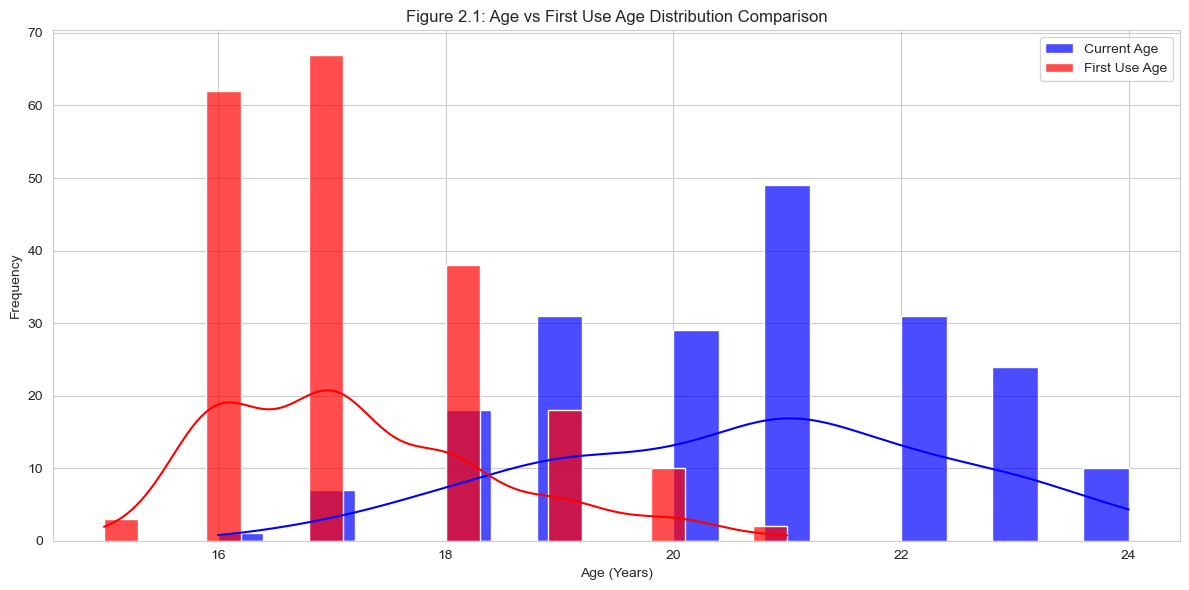

In [11]:
# Age and First Use Age Distribution Comparison
plt.figure(figsize=(12, 6))

# Create subplot with two histograms
sns.histplot(drug_df['Q1_Age'], bins=20, kde=True, color='blue', alpha=0.7, label='Current Age')
sns.histplot(drug_df['Q15_FirstUseAge'], bins=20, kde=True, color='red', alpha=0.7, label='First Use Age')
plt.title('Figure 2.1: Age vs First Use Age Distribution Comparison')
plt.xlabel('Age (Years)')
plt.ylabel('Frequency')
plt.legend()

plt.tight_layout()
plt.show()

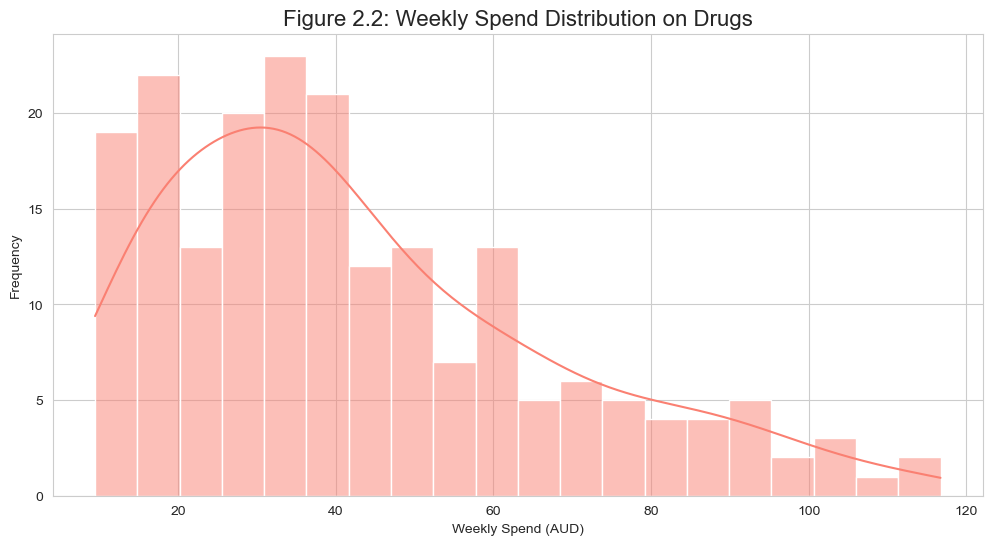

In [12]:
# Weekly Spend Distribution on Drugs
plt.figure(figsize=(12, 6))
sns.histplot(drug_df['Q16_WeeklySpend'], bins=20, kde=True, color='salmon')
plt.title('Figure 2.2: Weekly Spend Distribution on Drugs', fontsize=16)
plt.xlabel('Weekly Spend (AUD)')
plt.ylabel('Frequency')
plt.show()

In [13]:
def plot_categorical_distribution(df, column_name, title=None, figsize=(10, 6), palette='viridis'):
    """
    Create a side-by-side bar chart for categorical variables with percentage labels.
    
    Parameters:
    - df: DataFrame containing the data
    - column_name: name of the categorical column to plot
    - title: custom title for the plot (optional)
    - figsize: figure size as tuple (width, height)
    - palette: color palette for the bars
    
    Returns:
    - None (displays the plot)
    """
    plt.figure(figsize=figsize)
    
    # Get value counts for the categorical variable
    value_counts = df[column_name].value_counts()
    
    # Create the bar plot
    ax = sns.countplot(x=column_name, data=df, palette=palette, order=value_counts.index)
    
    # Add percentage labels on each bar
    total = len(df)
    for p in ax.patches:
        percentage = '{:.1f}%'.format(100 * p.get_height() / total)
        ax.annotate(percentage, (p.get_x() + p.get_width()/2., p.get_height()),
                    ha='center', va='bottom', xytext=(0, 5), textcoords='offset points')
    
    # Set title
    if title is None:
        title = f'Distribution of {column_name}'
    
    plt.title(title, fontsize=16)
    plt.xlabel(column_name.replace('_', ' ').title())
    plt.ylabel('Number of Respondents')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print(f"\n--- {column_name} Distribution Summary ---")
    for category, count in value_counts.items():
        percentage = (count / total) * 100
        print(f"{category}: {count} respondents ({percentage:.1f}%)")

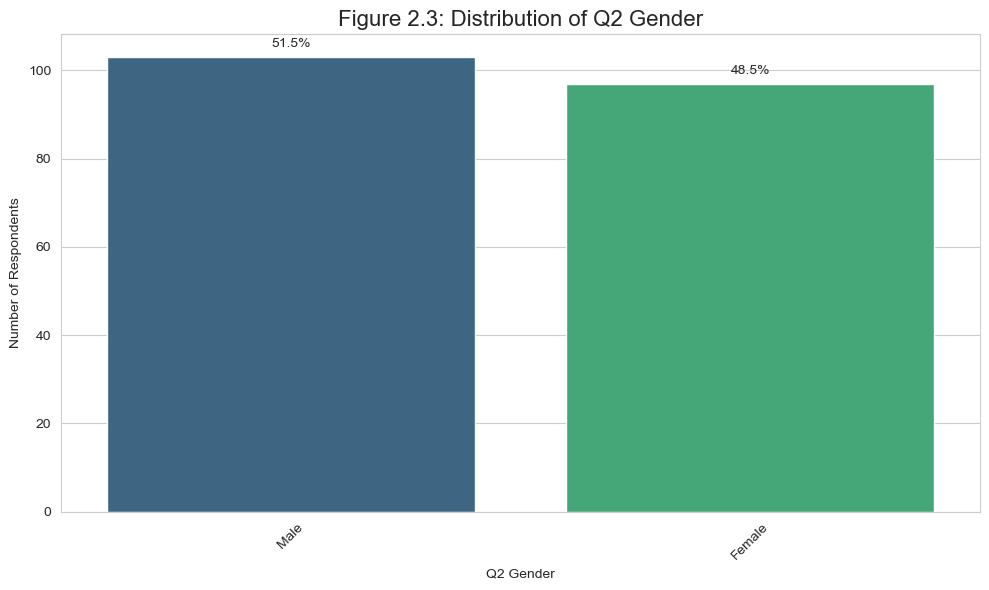


--- Q2_Gender Distribution Summary ---
Male: 103 respondents (51.5%)
Female: 97 respondents (48.5%)


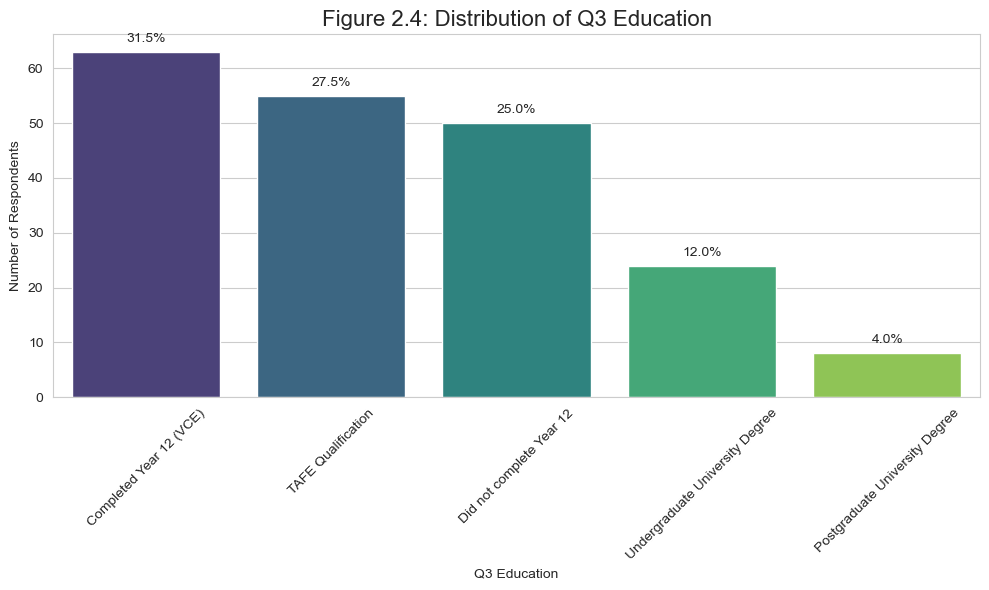


--- Q3_Education Distribution Summary ---
Completed Year 12 (VCE): 63 respondents (31.5%)
TAFE Qualification: 55 respondents (27.5%)
Did not complete Year 12: 50 respondents (25.0%)
Undergraduate University Degree: 24 respondents (12.0%)
Postgraduate University Degree: 8 respondents (4.0%)


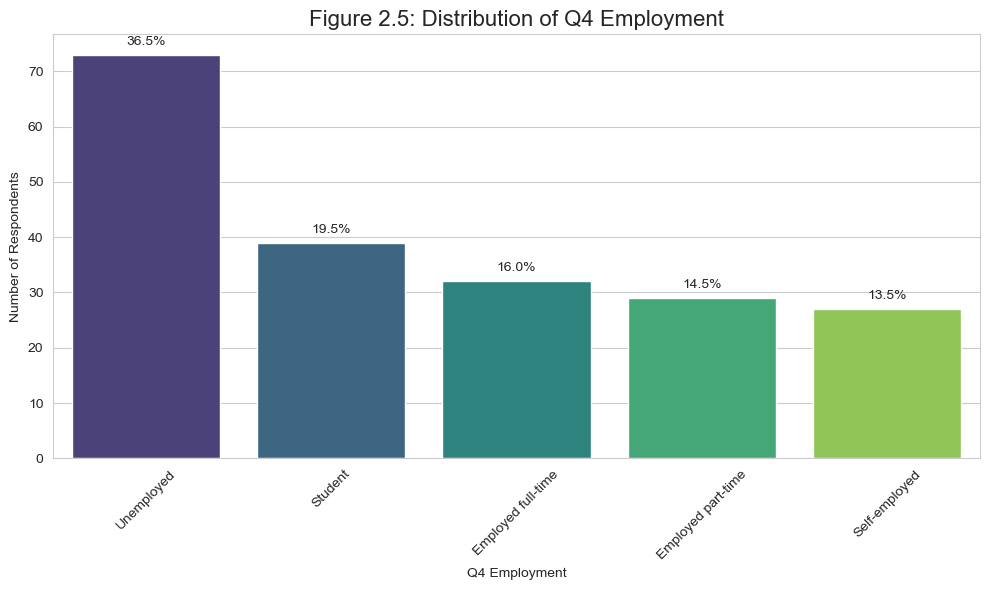


--- Q4_Employment Distribution Summary ---
Unemployed: 73 respondents (36.5%)
Student: 39 respondents (19.5%)
Employed full-time: 32 respondents (16.0%)
Employed part-time: 29 respondents (14.5%)
Self-employed: 27 respondents (13.5%)


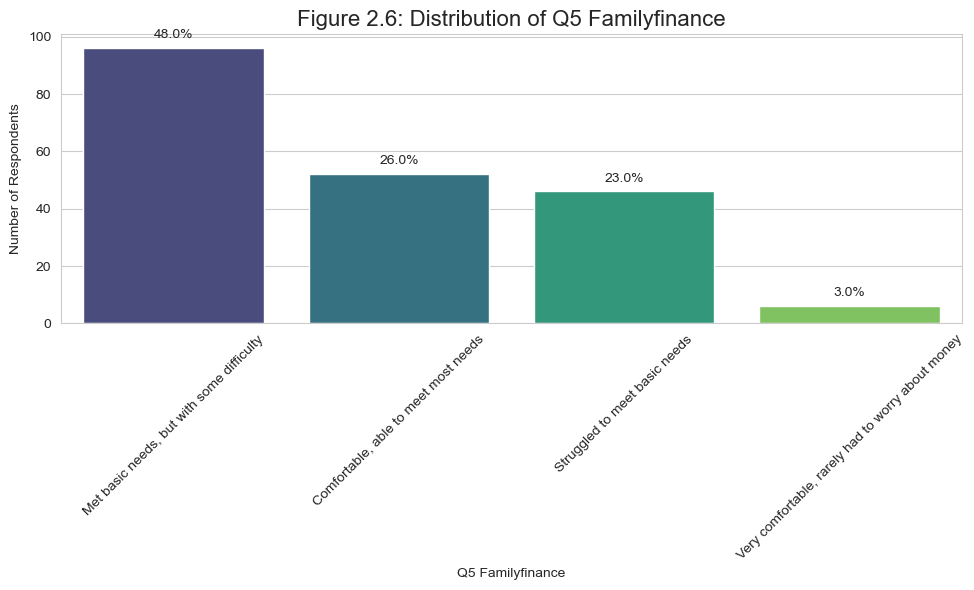


--- Q5_FamilyFinance Distribution Summary ---
Met basic needs, but with some difficulty: 96 respondents (48.0%)
Comfortable, able to meet most needs: 52 respondents (26.0%)
Struggled to meet basic needs: 46 respondents (23.0%)
Very comfortable, rarely had to worry about money: 6 respondents (3.0%)


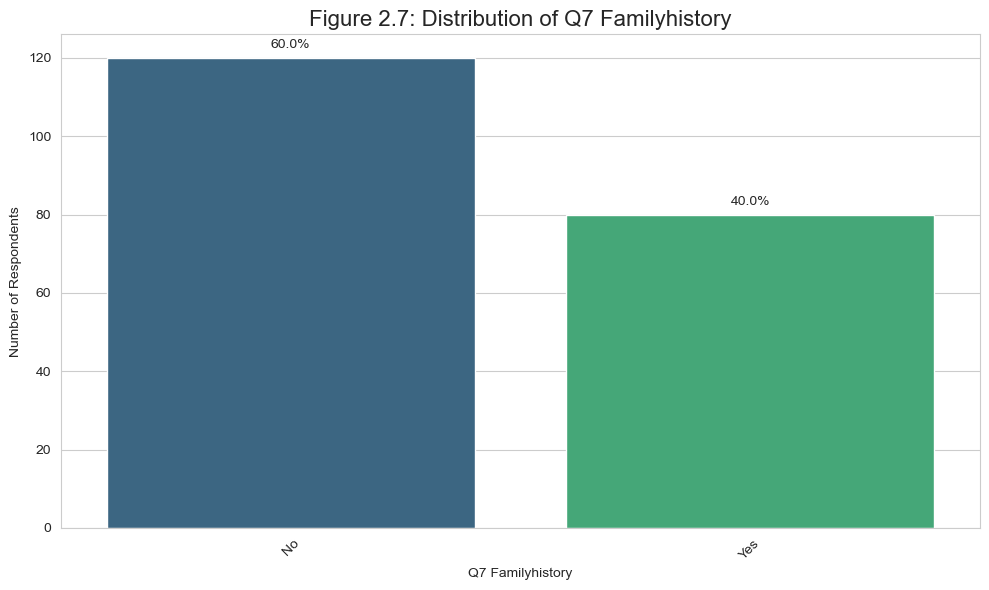


--- Q7_FamilyHistory Distribution Summary ---
No: 120 respondents (60.0%)
Yes: 80 respondents (40.0%)


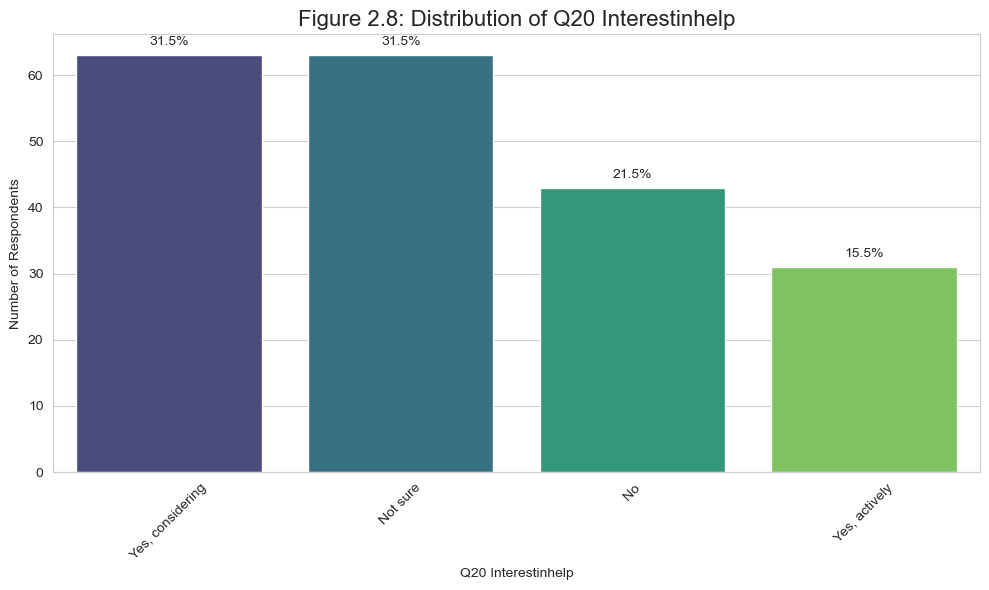


--- Q20_InterestInHelp Distribution Summary ---
Yes, considering: 63 respondents (31.5%)
Not sure: 63 respondents (31.5%)
No: 43 respondents (21.5%)
Yes, actively: 31 respondents (15.5%)


In [14]:
key_categorical_vars = ['Q2_Gender', 'Q3_Education', 'Q4_Employment', 'Q5_FamilyFinance', 'Q7_FamilyHistory', 'Q20_InterestInHelp']
                        
for var in key_categorical_vars:
    plot_categorical_distribution(drug_df, var, title=f'Figure 2.{key_categorical_vars.index(var)+3}: Distribution of {var.replace("_", " ").title()}')
        
# Q8.1_Stress
# Q8.2_PeerPressure
# Q8.3_Normality
# Q8.4_ExploreIdentity
# Q8.5_HomeProblem
# Q8.6_ConfidentToSayNo

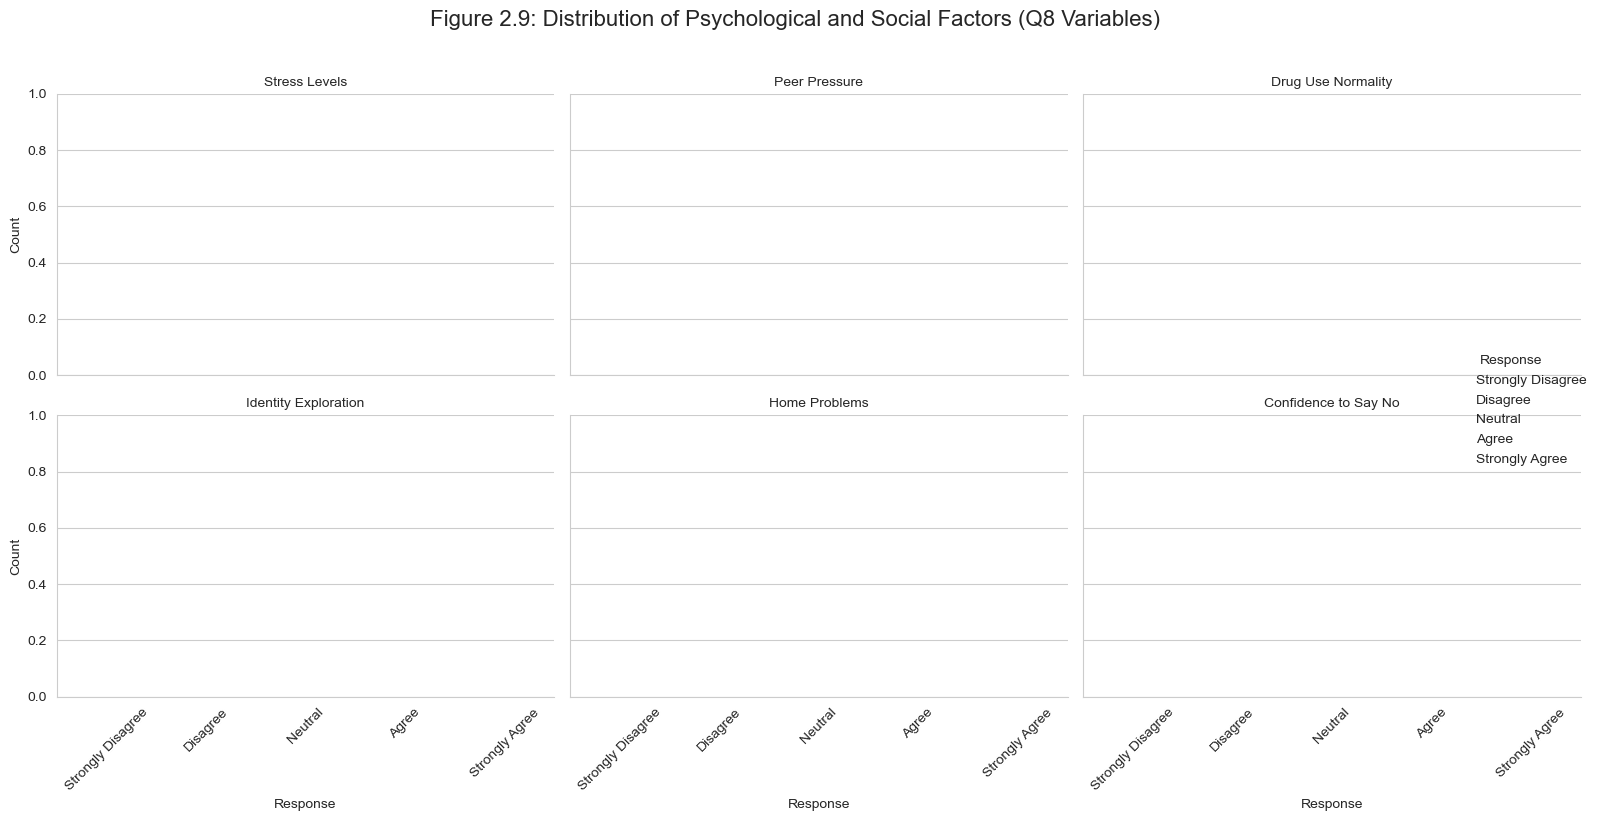

In [15]:
factor_categorical_vars = ['Q8.1_Stress', 'Q8.2_PeerPressure', 'Q8.3_Normality', 'Q8.4_ExploreIdentity', 'Q8.5_HomeProblem', 'Q8.6_ConfidentToSayNo']

# Create a melted dataframe for the Q8 variables
q8_melted = drug_df[factor_categorical_vars].melt(var_name='Factor', value_name='Response')

# Map the variable names to more descriptive titles
factor_name_mapping = {
    'Q8.1_Stress': 'Stress Levels',
    'Q8.2_PeerPressure': 'Peer Pressure', 
    'Q8.3_Normality': 'Drug Use Normality',
    'Q8.4_ExploreIdentity': 'Identity Exploration',
    'Q8.5_HomeProblem': 'Home Problems',
    'Q8.6_ConfidentToSayNo': 'Confidence to Say No'
}
q8_melted['Factor_Name'] = q8_melted['Factor'].map(factor_name_mapping)

# Create a mapping for your Likert scale responses
response_mapping = {
    1: 'Strongly Disagree',
    2: 'Disagree',
    3: 'Neutral',
    4: 'Agree',
    5: 'Strongly Agree'
}

# Apply the mapping
q8_melted['Response'] = q8_melted['Response'].map(response_mapping)

# Create the faceted plot using catplot
g = sns.catplot(
    data=q8_melted,
    x='Response',           # Likert scale responses on x-axis
    col='Factor_Name',      # Create separate plots for each factor
    kind='count',           # Count plot type
    col_wrap=3,             # Wrap after 3 plots (2 rows of 3)
    height=4,               # Height of each subplot
    aspect=1.2,             # Width = height * aspect
    palette='viridis',
    order=['Strongly Disagree', 'Disagree', 'Neutral', 'Agree', 'Strongly Agree']
)

# Add percentage data labels to each bar
for ax in g.axes.flat:
    # Calculate total for this subplot
    total = sum(p.get_height() for p in ax.patches)
    
    for p in ax.patches:
        height = p.get_height()
        if height > 0:  # Only add label if bar has height
            percentage = (height / total) * 100
            ax.annotate(f'{percentage:.1f}%', 
                       (p.get_x() + p.get_width()/2., height),
                       ha='center', va='bottom', 
                       xytext=(0, 3), textcoords='offset points',
                       fontsize=9)

# Customize the plot
g.set_titles(col_template="{col_name}")
g.set_axis_labels('Response', 'Count')

# Rotate x-axis labels for better readability
for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=45)

# Add main title
g.fig.suptitle('Figure 2.9: Distribution of Psychological and Social Factors (Q8 Variables)', 
               fontsize=16, y=1.02)

plt.tight_layout()
plt.show()

#### Correlation Matrix

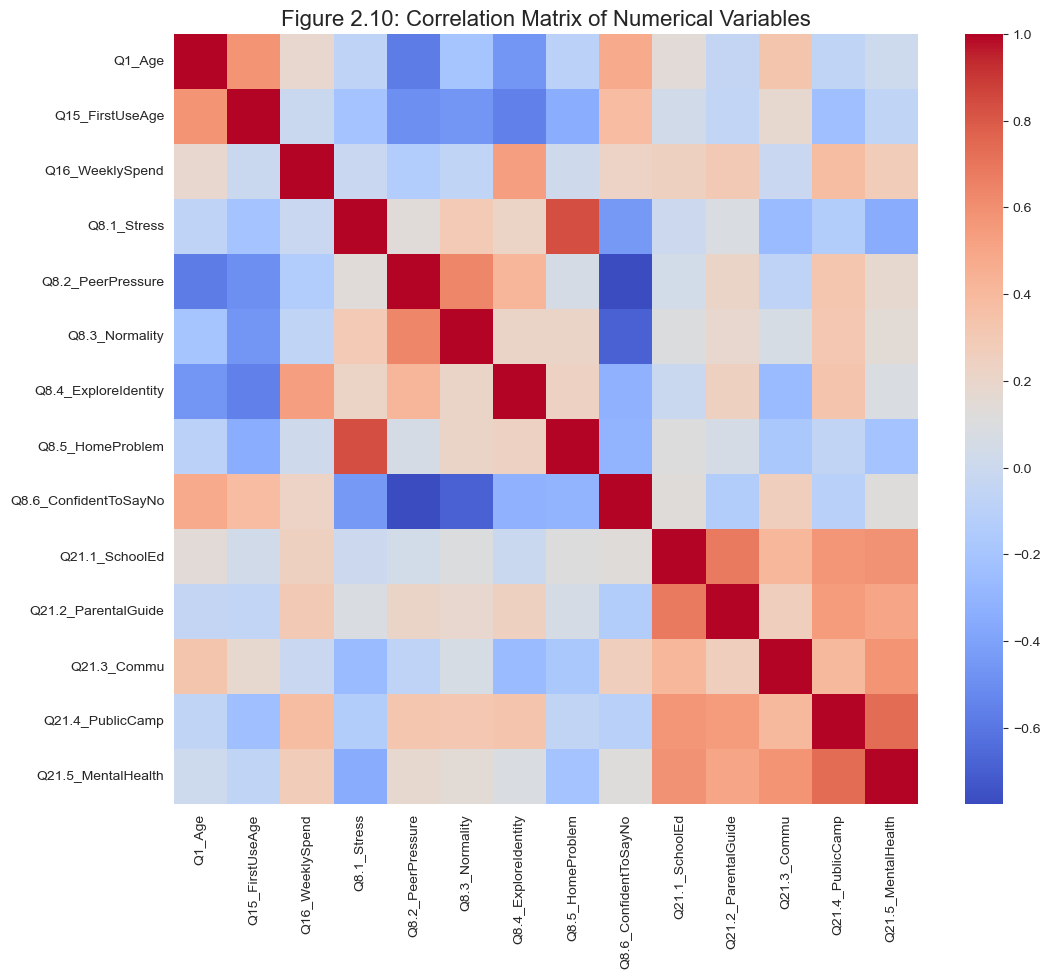

In [17]:
# Correlation Matrix for Numerical Variables
# We'll include the likeart scale items as they are numerical
likert_cols = [col for col in drug_df.columns if col.startswith('Q8.') or col.startswith('Q21.')]
corr_df = drug_df[numerical_cols + likert_cols]

# Convert Likert scale text to numbers for proper correlation analysis
likert_mapping = {
    'Strongly Disagree': 1, 'Disagree': 2, 'Neutral': 3, 'Agree': 4, 'Strongly Agree': 5,
    'Not effective at all': 1, 'Not effective': 2, 'Neutral': 3, 'Effective': 4, 'Very effective': 5
}

# Apply mapping to Likert columns
for col in likert_cols:
    corr_df[col] = drug_df[col].map(likert_mapping)

plt.figure(figsize=(12, 10))
correlation_matrix = corr_df.corr()
sns.heatmap(correlation_matrix, annot=False, fmt=".2f", cmap='coolwarm')
plt.title('Figure 2.10: Correlation Matrix of Numerical Variables', fontsize=16)
plt.show()

## 1.2 Mandatory Inferential Statistics & Group Comparisons

In [18]:
# Apply the mapping to each column
for col in likert_cols:
    # Use .get(x, pd.NA) to handle any unexpected values gracefully by turning them into missing data
    drug_df[col] = drug_df[col].map(lambda x: likert_mapping.get(x, pd.NA))
    
# Verify the transformation by checking the data types
print("--- Verifying Data Types After Transformation ---")
print(drug_df[likert_cols].info())
print("\nData transformation complete. The Likert scales are now numeric.")

--- Verifying Data Types After Transformation ---
<class 'pandas.core.frame.DataFrame'>
Index: 200 entries, 1 to 200
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   Q8.1_Stress            200 non-null    int64
 1   Q8.2_PeerPressure      200 non-null    int64
 2   Q8.3_Normality         200 non-null    int64
 3   Q8.4_ExploreIdentity   200 non-null    int64
 4   Q8.5_HomeProblem       200 non-null    int64
 5   Q8.6_ConfidentToSayNo  200 non-null    int64
 6   Q21.1_SchoolEd         200 non-null    int64
 7   Q21.2_ParentalGuide    200 non-null    int64
 8   Q21.3_Commu            200 non-null    int64
 9   Q21.4_PublicCamp       200 non-null    int64
 10  Q21.5_MentalHealth     200 non-null    int64
dtypes: int64(11)
memory usage: 18.8 KB
None

Data transformation complete. The Likert scales are now numeric.


### Estimate Proportion Seeking Help (with 95% CI)

In [19]:
interested_categories = ["Yes, actively", "Yes, considering"]

# Count successes and total trials (excluding "Unsure")
interested_count = drug_df['Q20_InterestInHelp'].isin(interested_categories).sum()
total_count = drug_df[drug_df['Q20_InterestInHelp'] != "Unsure"].shape[0]
# total_count = drug_df.shape[0]

# Calculate the 95% confidence interval
ci_low, ci_upp = smp.proportion_confint(count=interested_count, nobs=total_count, alpha=0.05, method='wilson')
proportion = interested_count / total_count

print(f"--- Table 2.2: Proportion of Respondents Interested in Seeking Help ---")
print(f"Sample Proportion Interested in Seeking Help: {proportion:.2f}")
print(f"95% Confidence Interval: ({ci_low:.2f}, {ci_upp:.2f})")

--- Table 2.2: Proportion of Respondents Interested in Seeking Help ---
Sample Proportion Interested in Seeking Help: 0.47
95% Confidence Interval: (0.40, 0.54)


In [20]:
# Create a properly formatted table for proportion seeking help
proportion_results = pd.DataFrame({
    'Metric': [
        'Sample Size (Total)',
        # 'Sample Size (Excluding "Unsure")',
        'Number Interested in Help',
        'Sample Proportion',
        '95% CI Lower Bound',
        '95% CI Upper Bound'
    ],
    'Value': [
        drug_df.shape[0],
        # total_count,
        interested_count,
        f"{proportion:.4f}",
        f"{ci_low:.4f}",
        f"{ci_upp:.4f}"
    ]
})

print("--- Table 2.2: Proportion of Respondents Interested in Seeking Help ---")
print("=" * 70)
print(proportion_results.to_string(index=False))
print("=" * 70)

--- Table 2.2: Proportion of Respondents Interested in Seeking Help ---
                   Metric  Value
      Sample Size (Total)    200
Number Interested in Help     94
        Sample Proportion 0.4700
       95% CI Lower Bound 0.4020
       95% CI Upper Bound 0.5391


### Test for Differences in Spending and Age

#### Weekly Drug Spend vs. Gender (T-test)

In [21]:
# Weekly Spend vs. Gender (T-test)
print("\n--- Analysis 2: Weekly Spend by Gender (T-test) ---")
male_spend = drug_df[drug_df['Q2_Gender'] == 'Male']['Q16_WeeklySpend']
female_spend = drug_df[drug_df['Q2_Gender'] == 'Female']['Q16_WeeklySpend']

ttest_result = stats.ttest_ind(male_spend, female_spend, equal_var=False)
print(f"T-statistic: {ttest_result.statistic:.2f}, P-value: {ttest_result.pvalue:.3f}")


--- Analysis 2: Weekly Spend by Gender (T-test) ---
T-statistic: -1.31, P-value: 0.193


In [22]:
# Interpret the t-test results
print("--- Interpretation of T-test Results ---")
print(f"T-statistic: {ttest_result.statistic:.3f}")
print(f"P-value: {ttest_result.pvalue:.3f}")
print(f"Degrees of freedom: {ttest_result.df:.1f}")

# Statistical interpretation
alpha = 0.05
print(f"\nAt α = {alpha}:")
if ttest_result.pvalue < alpha:
    print("✓ SIGNIFICANT: There is a statistically significant difference in weekly spending between males and females")
else:
    print("✗ NOT SIGNIFICANT: There is no statistically significant difference in weekly spending between males and females")

# Descriptive statistics for context
print(f"\nDescriptive Statistics:")
print(f"Male weekly spending - Mean: ${male_spend.mean():.2f}, SD: ${male_spend.std():.2f}, n: {len(male_spend)}")
print(f"Female weekly spending - Mean: ${female_spend.mean():.2f}, SD: ${female_spend.std():.2f}, n: {len(female_spend)}")

# Effect size interpretation
print(f"\nPractical Interpretation:")
print(f"The negative t-statistic ({ttest_result.statistic:.3f}) indicates that males spend less on average than females.")
print(f"However, with p = {ttest_result.pvalue:.3f} > 0.05, this difference is not statistically significant.")
print("We fail to reject the null hypothesis that there is no difference in weekly drug spending between genders.")

--- Interpretation of T-test Results ---
T-statistic: -1.306
P-value: 0.193
Degrees of freedom: 195.7

At α = 0.05:
✗ NOT SIGNIFICANT: There is no statistically significant difference in weekly spending between males and females

Descriptive Statistics:
Male weekly spending - Mean: $40.55, SD: $26.50, n: 103
Female weekly spending - Mean: $45.07, SD: $22.38, n: 97

Practical Interpretation:
The negative t-statistic (-1.306) indicates that males spend less on average than females.
However, with p = 0.193 > 0.05, this difference is not statistically significant.
We fail to reject the null hypothesis that there is no difference in weekly drug spending between genders.


In [23]:
# Create a summary table for the t-test results

# Create the results table
ttest_summary = pd.DataFrame({
    'Statistic': ['T-statistic', 'P-value', 'Degrees of Freedom', 'Sample Size (Male)', 'Sample Size (Female)', 
                  'Mean Weekly Spend (Male)', 'Mean Weekly Spend (Female)', 'SD Weekly Spend (Male)', 'SD Weekly Spend (Female)'],
    'Value': [f"{ttest_result.statistic:.4f}", 
              f"{ttest_result.pvalue:.4f}",
              f"{ttest_result.df:.1f}",
              len(male_spend),
              len(female_spend),
              f"${male_spend.mean():.2f}",
              f"${female_spend.mean():.2f}",
              f"${male_spend.std():.2f}",
              f"${female_spend.std():.2f}"]
})

print(f"--- Table 2.3: T-Test Summary for Weekly Spending by Gender ---")
print("T-Test Results: Weekly Spending by Gender")
print("=" * 50)
print(ttest_summary.to_string(index=False))

# Add interpretation
print("\n" + "=" * 50)
print("Statistical Interpretation:")
alpha = 0.05
if ttest_result.pvalue < alpha:
    significance = "Significant"
    conclusion = "Reject null hypothesis"
else:
    significance = "Not Significant" 
    conclusion = "Fail to reject null hypothesis"

print(f"α = {alpha}, p-value = {ttest_result.pvalue:.4f}")
print(f"Result: {significance} ({conclusion})")

--- Table 2.3: T-Test Summary for Weekly Spending by Gender ---
T-Test Results: Weekly Spending by Gender
                 Statistic   Value
               T-statistic -1.3057
                   P-value  0.1932
        Degrees of Freedom   195.7
        Sample Size (Male)     103
      Sample Size (Female)      97
  Mean Weekly Spend (Male)  $40.55
Mean Weekly Spend (Female)  $45.07
    SD Weekly Spend (Male)  $26.50
  SD Weekly Spend (Female)  $22.38

Statistical Interpretation:
α = 0.05, p-value = 0.1932
Result: Not Significant (Fail to reject null hypothesis)


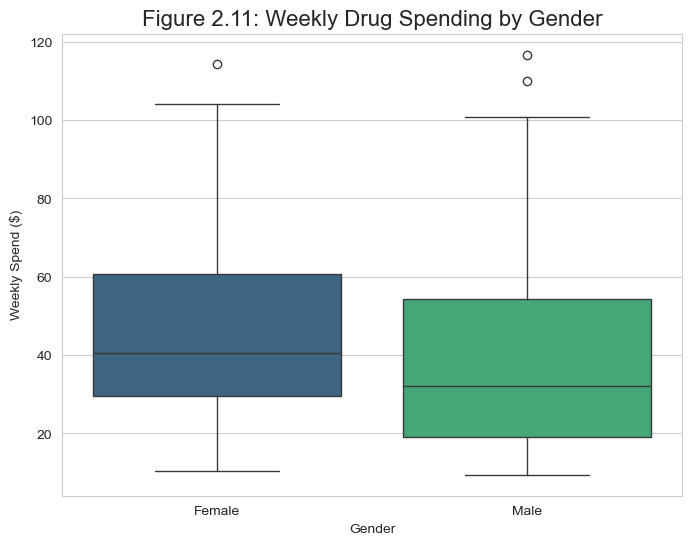

In [24]:
# Visualize with a boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(x='Q2_Gender', y='Q16_WeeklySpend', data=drug_df, palette='viridis')
plt.title('Figure 2.11: Weekly Drug Spending by Gender', fontsize=16)
plt.xlabel('Gender')
plt.ylabel('Weekly Spend ($)')
plt.show()


#### Weekly Drug Spend vs. Family History (T-test)

In [25]:
# Weekly Spend vs. Family History (T-test)
print("\n--- Analysis 3: Weekly Spend by Family History (T-test) ---")
family_history_yes = drug_df[drug_df['Q7_FamilyHistory'] == 'Yes']['Q16_WeeklySpend']
family_history_no = drug_df[drug_df['Q7_FamilyHistory'] == 'No']['Q16_WeeklySpend']

ttest_result = stats.ttest_ind(family_history_yes, family_history_no, equal_var=False)
print(f"T-statistic: {ttest_result.statistic:.2f}, P-value: {ttest_result.pvalue:.3f}")


--- Analysis 3: Weekly Spend by Family History (T-test) ---
T-statistic: -0.67, P-value: 0.501


In [26]:
# Create a summary table for the t-test results

# Create the results table
ttest_summary = pd.DataFrame({
    'Statistic': ['T-statistic', 'P-value', 'Degrees of Freedom', 'Sample Size (Yes)', 'Sample Size (No)', 
                  'Mean Weekly Spend (Yes)', 'Mean Weekly Spend (No)', 'SD Weekly Spend (Yes)', 'SD Weekly Spend (No)'],
    'Value': [f"{ttest_result.statistic:.4f}", 
              f"{ttest_result.pvalue:.4f}",
              f"{ttest_result.df:.1f}",
              len(family_history_yes),
              len(family_history_no),
              f"${family_history_yes.mean():.2f}",
              f"${family_history_no.mean():.2f}",
              f"${family_history_yes.std():.2f}",
              f"${family_history_no.std():.2f}"]
})

print(f"--- Table 2.4: T-Test Summary for Weekly Spending by Family History ---")
print("T-Test Results: Weekly Spending by Family History")
print("=" * 50)
print(ttest_summary.to_string(index=False))

# Add interpretation
print("\n" + "=" * 50)
print("Statistical Interpretation:")
alpha = 0.05
if ttest_result.pvalue < alpha:
    significance = "Significant"
    conclusion = "Reject null hypothesis"
else:
    significance = "Not Significant" 
    conclusion = "Fail to reject null hypothesis"

print(f"α = {alpha}, p-value = {ttest_result.pvalue:.4f}")
print(f"Result: {significance} ({conclusion})")

--- Table 2.4: T-Test Summary for Weekly Spending by Family History ---
T-Test Results: Weekly Spending by Family History
              Statistic   Value
            T-statistic -0.6749
                P-value  0.5006
     Degrees of Freedom   174.3
      Sample Size (Yes)      80
       Sample Size (No)     120
Mean Weekly Spend (Yes)  $41.31
 Mean Weekly Spend (No)  $43.69
  SD Weekly Spend (Yes)  $24.03
   SD Weekly Spend (No)  $25.07

Statistical Interpretation:
α = 0.05, p-value = 0.5006
Result: Not Significant (Fail to reject null hypothesis)


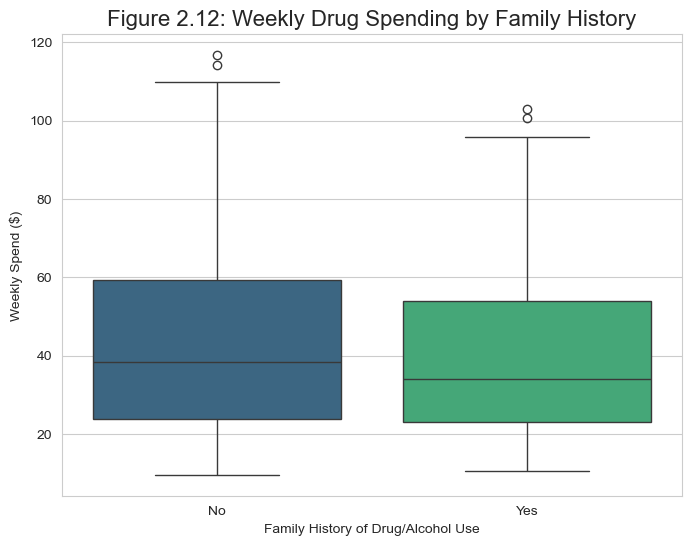

In [27]:
# Visualize with a boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(x='Q7_FamilyHistory', y='Q16_WeeklySpend', data=drug_df, palette='viridis')
plt.title('Figure 2.12: Weekly Drug Spending by Family History', fontsize=16)
plt.xlabel('Family History of Drug/Alcohol Use')
plt.ylabel('Weekly Spend ($)')
plt.show()


#### Weekly Spend vs. Employment Status (ANOVA)

In [28]:
# Weekly Spend vs. Employment Status (ANOVA)
print("\n--- Analysis 4: Weekly Spend by Employment Status (ANOVA) ---")
groups = drug_df['Q4_Employment'].unique()
grouped_data = [drug_df['Q16_WeeklySpend'][drug_df['Q4_Employment'] == g] for g in groups]

anova_result = stats.f_oneway(*grouped_data)
print(f"F-statistic: {anova_result.statistic:.2f}, P-value: {anova_result.pvalue:.3f}")


--- Analysis 4: Weekly Spend by Employment Status (ANOVA) ---
F-statistic: 2.78, P-value: 0.028


In [29]:
# Create a comprehensive ANOVA results table similar to R output
print("Table 2.5: ANOVA Table - Weekly Drug Spending by Employment Status")
print("=" * 60)

# Calculate group statistics
group_stats = []
for employment_status in groups:
    group_data = drug_df[drug_df['Q4_Employment'] == employment_status]['Q16_WeeklySpend']
    group_stats.append({
        'Group': employment_status,
        'N': len(group_data),
        'Mean': group_data.mean(),
        'SD': group_data.std(),
        'Min': group_data.min(),
        'Max': group_data.max()
    })

# Create group statistics table
group_stats_df = pd.DataFrame(group_stats)
print("\nDescriptive Statistics by Employment Status:")
print("-" * 60)
for _, row in group_stats_df.iterrows():
    print(f"{row['Group']:<20} N={row['N']:>3} Mean=${row['Mean']:>6.2f} SD=${row['SD']:>6.2f} Range=${row['Min']:>5.2f}-${row['Max']:>6.2f}")

# Calculate ANOVA components manually for proper table
grand_mean = drug_df['Q16_WeeklySpend'].mean()
n_total = len(drug_df)
k = len(groups)  # number of groups

# Between-groups sum of squares (SSB)
ssb = sum([len(drug_df[drug_df['Q4_Employment'] == group]) * 
           (drug_df[drug_df['Q4_Employment'] == group]['Q16_WeeklySpend'].mean() - grand_mean)**2 
           for group in groups])

# Within-groups sum of squares (SSW)
ssw = sum([((drug_df[drug_df['Q4_Employment'] == group]['Q16_WeeklySpend'] - 
            drug_df[drug_df['Q4_Employment'] == group]['Q16_WeeklySpend'].mean())**2).sum() 
           for group in groups])

# Total sum of squares (SST)
sst = ssb + ssw

# Degrees of freedom
df_between = k - 1
df_within = n_total - k
df_total = n_total - 1

# Mean squares
msb = ssb / df_between
msw = ssw / df_within

# F-statistic and p-value (from previous calculation)
f_stat = anova_result.statistic
p_value = anova_result.pvalue

# Create ANOVA table
anova_table = pd.DataFrame({
    'Source': ['Between Groups', 'Within Groups', 'Total'],
    'SS': [f'{ssb:.2f}', f'{ssw:.2f}', f'{sst:.2f}'],
    'df': [df_between, df_within, df_total],
    'MS': [f'{msb:.2f}', f'{msw:.2f}', '-'],
    'F': [f'{f_stat:.4f}', '-', '-'],
    'p-value': [f'{p_value:.4f}', '-', '-']
})

print(f"\n\nANOVA Results:")
print("-" * 60)
print(anova_table.to_string(index=False))

# Statistical interpretation
print(f"\n\nStatistical Interpretation:")
print("-" * 60)
alpha = 0.05
if p_value < alpha:
    significance = "Significant"
    conclusion = "Reject null hypothesis"
    interpretation = "There are significant differences in weekly spending between employment groups."
else:
    significance = "Not Significant"
    conclusion = "Fail to reject null hypothesis"
    interpretation = "There are no significant differences in weekly spending between employment groups."

print(f"F({df_between}, {df_within}) = {f_stat:.4f}, p = {p_value:.4f}")
print(f"α = {alpha}, Result: {significance}")
print(f"Conclusion: {conclusion}")
print(f"Interpretation: {interpretation}")

Table 2.5: ANOVA Table - Weekly Drug Spending by Employment Status

Descriptive Statistics by Employment Status:
------------------------------------------------------------
Unemployed           N= 73 Mean=$ 37.17 SD=$ 21.95 Range=$ 9.45-$100.78
Student              N= 39 Mean=$ 43.06 SD=$ 23.86 Range=$12.32-$ 95.88
Self-employed        N= 27 Mean=$ 42.75 SD=$ 24.61 Range=$13.63-$116.71
Employed part-time   N= 29 Mean=$ 43.64 SD=$ 23.41 Range=$11.16-$104.17
Employed full-time   N= 32 Mean=$ 54.22 SD=$ 29.39 Range=$12.89-$114.33


ANOVA Results:
------------------------------------------------------------
        Source        SS  df      MS      F p-value
Between Groups   6509.35   4 1627.34 2.7789  0.0281
 Within Groups 114192.99 195  585.61      -       -
         Total 120702.34 199       -      -       -


Statistical Interpretation:
------------------------------------------------------------
F(4, 195) = 2.7789, p = 0.0281
α = 0.05, Result: Significant
Conclusion: Reject null hypo

In [30]:
anova_result

F_onewayResult(statistic=2.7788973404807513, pvalue=0.028119526188668878)

In [31]:
# Post-hoc analysis interpretation
print("\n" + "=" * 70)
print("DETAILED INTERPRETATION OF ANOVA RESULTS")
print("=" * 70)

print(f"\n📊 STATISTICAL FINDINGS:")
print(f"   • F-statistic: {f_stat:.4f}")
print(f"   • p-value: {p_value:.4f}")
print(f"   • Significance level (α): 0.05")
print(f"   • Result: {significance} (p < 0.05)")

print(f"\n🎯 CONCLUSION:")
print(f"   We reject the null hypothesis and conclude that there ARE statistically")
print(f"   significant differences in weekly drug spending between employment groups.")

print(f"\n💰 SPENDING PATTERNS BY GROUP:")
print(f"   1. Employed full-time: ${group_stats_df.iloc[4]['Mean']:.2f} (highest)")
print(f"   2. Employed part-time: ${group_stats_df.iloc[3]['Mean']:.2f}")
print(f"   3. Student:           ${group_stats_df.iloc[1]['Mean']:.2f}")
print(f"   4. Self-employed:     ${group_stats_df.iloc[2]['Mean']:.2f}")
print(f"   5. Unemployed:        ${group_stats_df.iloc[0]['Mean']:.2f} (lowest)")

print(f"\n🔍 KEY INSIGHTS:")
print(f"   • Full-time employees spend ~${group_stats_df.iloc[4]['Mean'] - group_stats_df.iloc[0]['Mean']:.2f} more per week than unemployed individuals")
print(f"   • This represents a {((group_stats_df.iloc[4]['Mean'] - group_stats_df.iloc[0]['Mean'])/group_stats_df.iloc[0]['Mean']*100):.1f}% difference")
print(f"   • Employment status appears to be a significant predictor of drug spending")

print(f"\n⚠️  NEXT STEPS:")
print(f"   Since the ANOVA is significant, post-hoc tests (e.g., Tukey's HSD) would")
print(f"   be needed to determine which specific groups differ from each other.")


DETAILED INTERPRETATION OF ANOVA RESULTS

📊 STATISTICAL FINDINGS:
   • F-statistic: 2.7789
   • p-value: 0.0281
   • Significance level (α): 0.05
   • Result: Significant (p < 0.05)

🎯 CONCLUSION:
   We reject the null hypothesis and conclude that there ARE statistically
   significant differences in weekly drug spending between employment groups.

💰 SPENDING PATTERNS BY GROUP:
   1. Employed full-time: $54.22 (highest)
   2. Employed part-time: $43.64
   3. Student:           $43.06
   4. Self-employed:     $42.75
   5. Unemployed:        $37.17 (lowest)

🔍 KEY INSIGHTS:
   • Full-time employees spend ~$17.05 more per week than unemployed individuals
   • This represents a 45.9% difference
   • Employment status appears to be a significant predictor of drug spending

⚠️  NEXT STEPS:
   Since the ANOVA is significant, post-hoc tests (e.g., Tukey's HSD) would
   be needed to determine which specific groups differ from each other.


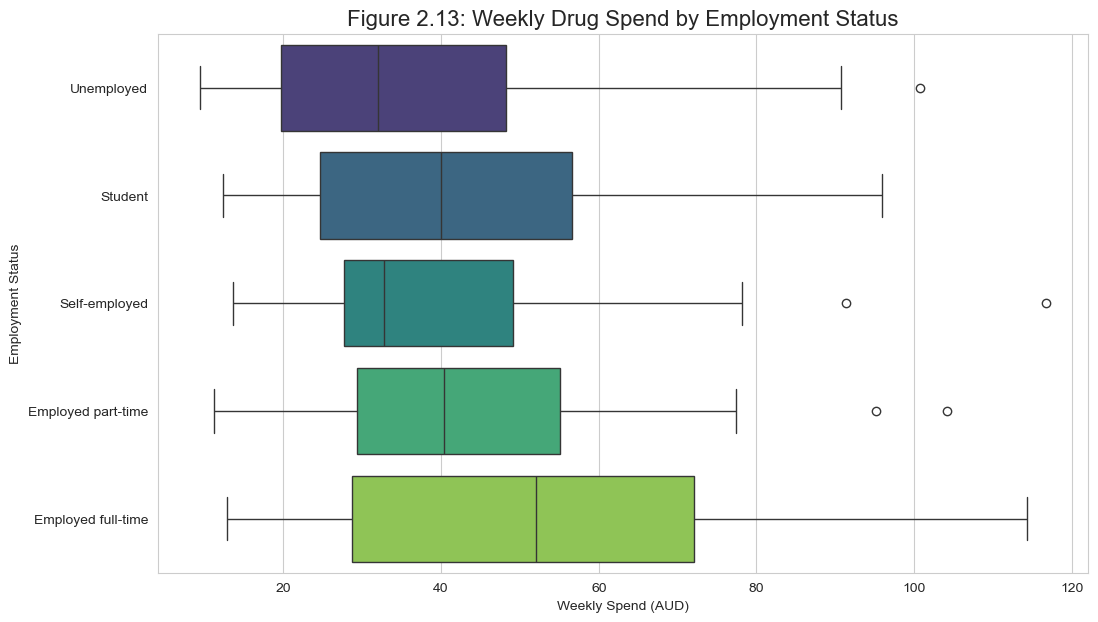

In [32]:
# Visualize with a boxplot
plt.figure(figsize=(12, 7))
sns.boxplot(x='Q16_WeeklySpend', y='Q4_Employment', data=drug_df, palette='viridis')
plt.title('Figure 2.13: Weekly Drug Spend by Employment Status', fontsize=16)
plt.xlabel('Weekly Spend (AUD)')
plt.ylabel('Employment Status')
plt.show()

#### Functions to do T-test and ANOVA test

In [33]:
def perform_ttest_analysis(df, categorical_col, numerical_col, title="T-Test Analysis", palette="viridis"):
    """
    Perform independent t-test for a numerical variable across two groups of a categorical variable.
    
    Parameters:
    - df: DataFrame containing the data
    - categorical_col: name of the categorical column (must have exactly 2 unique values)
    - numerical_col: name of the numerical column
    - title: title for the plot
    - palette: color palette for the plot
    
    Returns:
    - Dictionary containing test results and summary statistics
    """
    # Check if categorical variable has exactly 2 groups
    groups = df[categorical_col].unique()
    if len(groups) != 2:
        raise ValueError(f"Categorical variable must have exactly 2 groups, found {len(groups)}")
    
    # Split data into two groups
    group1_data = df[df[categorical_col] == groups[0]][numerical_col]
    group2_data = df[df[categorical_col] == groups[1]][numerical_col]
    
    # Perform t-test
    ttest_result = stats.ttest_ind(group1_data, group2_data, equal_var=False)
    
    # Create summary table
    summary_table = pd.DataFrame({
        'Statistic': ['T-statistic', 'P-value', 'Degrees of Freedom', 
                     f'Sample Size ({groups[0]})', f'Sample Size ({groups[1]})',
                     f'Mean {numerical_col} ({groups[0]})', f'Mean {numerical_col} ({groups[1]})',
                     f'SD {numerical_col} ({groups[0]})', f'SD {numerical_col} ({groups[1]})'],
        'Value': [f"{ttest_result.statistic:.4f}", 
                  f"{ttest_result.pvalue:.4f}",
                  f"{ttest_result.df:.1f}",
                  len(group1_data),
                  len(group2_data),
                  f"{group1_data.mean():.2f}",
                  f"{group2_data.mean():.2f}",
                  f"{group1_data.std():.2f}",
                  f"{group2_data.std():.2f}"]
    })
    
    # Print results
    print(f"T-Test Results: {numerical_col} by {categorical_col}")
    print("=" * 60)
    print(summary_table.to_string(index=False))
    
    # Statistical interpretation
    alpha = 0.05
    print(f"\n{'='*60}")
    print("Statistical Interpretation:")
    print(f"α = {alpha}, p-value = {ttest_result.pvalue:.4f}")
    
    if ttest_result.pvalue < alpha:
        significance = "Significant"
        conclusion = "Reject null hypothesis"
    else:
        significance = "Not Significant"
        conclusion = "Fail to reject null hypothesis"
    
    print(f"Result: {significance} ({conclusion})")
    
    # Create boxplot
    plt.figure(figsize=(8, 6))
    sns.boxplot(x=categorical_col, y=numerical_col, data=df, palette=palette)
    plt.title(title, fontsize=14)
    plt.ylabel(numerical_col)
    plt.xlabel(categorical_col)
    plt.show()
    
    return {
        'test_result': ttest_result,
        'summary_table': summary_table,
        'group1_stats': {'mean': group1_data.mean(), 'std': group1_data.std(), 'n': len(group1_data)},
        'group2_stats': {'mean': group2_data.mean(), 'std': group2_data.std(), 'n': len(group2_data)},
        'significance': significance
    }


def perform_anova_analysis(df, categorical_col, numerical_col, title="ANOVA Analysis", palette="viridis"):
    """
    Perform one-way ANOVA for a numerical variable across multiple groups of a categorical variable.
    
    Parameters:
    - df: DataFrame containing the data
    - categorical_col: name of the categorical column
    - numerical_col: name of the numerical column
    - title: title for the plot
    - palette: color palette for the plot
    
    Returns:
    - Dictionary containing ANOVA results and summary statistics
    """
    # Get unique groups
    groups = df[categorical_col].unique()
    
    # Check if we have more than 2 groups
    if len(groups) < 2:
        raise ValueError("Need at least 2 groups for ANOVA")
    
    # Prepare data for ANOVA
    grouped_data = [df[df[categorical_col] == group][numerical_col] for group in groups]
    
    # Perform ANOVA
    anova_result = stats.f_oneway(*grouped_data)
    
    # Calculate descriptive statistics for each group
    group_stats = []
    for group in groups:
        group_data = df[df[categorical_col] == group][numerical_col]
        group_stats.append({
            'Group': group,
            'N': len(group_data),
            'Mean': group_data.mean(),
            'SD': group_data.std(),
            'Min': group_data.min(),
            'Max': group_data.max()
        })
    
    group_stats_df = pd.DataFrame(group_stats)
    
    # Calculate ANOVA table components
    grand_mean = df[numerical_col].mean()
    n_total = len(df)
    k = len(groups)
    
    # Sum of squares
    ssb = sum([len(df[df[categorical_col] == group]) * 
               (df[df[categorical_col] == group][numerical_col].mean() - grand_mean)**2 
               for group in groups])
    
    ssw = sum([((df[df[categorical_col] == group][numerical_col] - 
                df[df[categorical_col] == group][numerical_col].mean())**2).sum() 
               for group in groups])
    
    sst = ssb + ssw
    
    # Degrees of freedom
    df_between = k - 1
    df_within = n_total - k
    df_total = n_total - 1
    
    # Mean squares
    msb = ssb / df_between
    msw = ssw / df_within
    
    # Create ANOVA table
    anova_table = pd.DataFrame({
        'Source': ['Between Groups', 'Within Groups', 'Total'],
        'SS': [f'{ssb:.2f}', f'{ssw:.2f}', f'{sst:.2f}'],
        'df': [df_between, df_within, df_total],
        'MS': [f'{msb:.2f}', f'{msw:.2f}', '-'],
        'F': [f'{anova_result.statistic:.4f}', '-', '-'],
        'p-value': [f'{anova_result.pvalue:.4f}', '-', '-']
    })
    
    # Print results
    print(f"ANOVA Results: {numerical_col} by {categorical_col}")
    print("=" * 70)
    
    print("\nDescriptive Statistics by Group:")
    print("-" * 70)
    for _, row in group_stats_df.iterrows():
        print(f"{row['Group']:<20} N={row['N']:>3} Mean={row['Mean']:>8.2f} SD={row['SD']:>8.2f} Range={row['Min']:>6.2f}-{row['Max']:>8.2f}")
    
    print(f"\n\nANOVA Table:")
    print("-" * 70)
    print(anova_table.to_string(index=False))
    
    # Statistical interpretation
    alpha = 0.05
    print(f"\n\nStatistical Interpretation:")
    print("-" * 70)
    
    if anova_result.pvalue < alpha:
        significance = "Significant"
        conclusion = "Reject null hypothesis"
        interpretation = f"There are significant differences in {numerical_col} between {categorical_col} groups."
    else:
        significance = "Not Significant"
        conclusion = "Fail to reject null hypothesis"
        interpretation = f"There are no significant differences in {numerical_col} between {categorical_col} groups."
    
    print(f"F({df_between}, {df_within}) = {anova_result.statistic:.4f}, p = {anova_result.pvalue:.4f}")
    print(f"α = {alpha}, Result: {significance}")
    print(f"Conclusion: {conclusion}")
    print(f"Interpretation: {interpretation}")
    
    # Create boxplot
    plt.figure(figsize=(12, 7))
    sns.boxplot(y=categorical_col, x=numerical_col, data=df, palette=palette)
    plt.title(title, fontsize=14)
    plt.xlabel(numerical_col)
    plt.ylabel(categorical_col)
    plt.show()
    
    return {
        'anova_result': anova_result,
        'anova_table': anova_table,
        'group_stats': group_stats_df,
        'significance': significance,
        'f_statistic': anova_result.statistic,
        'p_value': anova_result.pvalue
    }

ANOVA Results: Q16_WeeklySpend by Q3_Education

Descriptive Statistics by Group:
----------------------------------------------------------------------
Completed Year 12 (VCE) N= 63 Mean=   40.07 SD=   23.58 Range= 10.55-  114.33
TAFE Qualification   N= 55 Mean=   46.91 SD=   26.85 Range=  9.45-  109.97
Undergraduate University Degree N= 24 Mean=   48.26 SD=   26.40 Range= 17.64-  116.71
Postgraduate University Degree N=  8 Mean=   38.44 SD=   27.22 Range= 12.89-   90.54
Did not complete Year 12 N= 50 Mean=   39.54 SD=   21.79 Range=  9.96-   95.88


ANOVA Table:
----------------------------------------------------------------------
        Source        SS  df     MS      F p-value
Between Groups   2798.56   4 699.64 1.1571  0.3311
 Within Groups 117903.78 195 604.63      -       -
         Total 120702.34 199      -      -       -


Statistical Interpretation:
----------------------------------------------------------------------
F(4, 195) = 1.1571, p = 0.3311
α = 0.05, Result: Not S

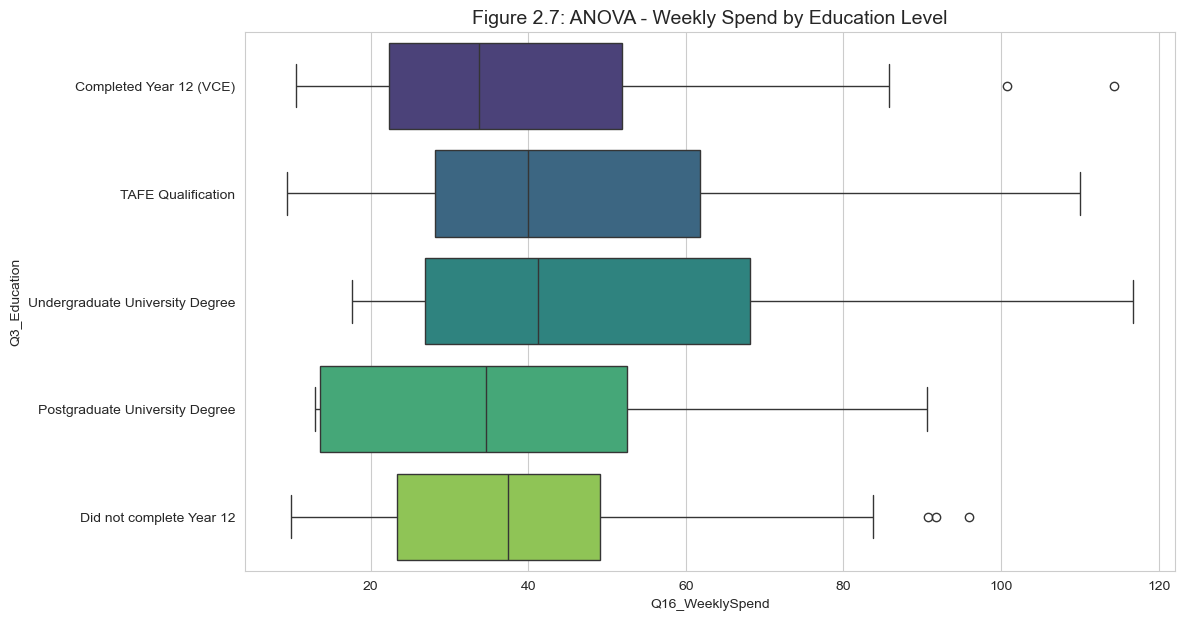

{'anova_result': F_onewayResult(statistic=1.157129948905743, pvalue=0.33110843149657315),
 'anova_table':            Source         SS   df      MS       F p-value
 0  Between Groups    2798.56    4  699.64  1.1571  0.3311
 1   Within Groups  117903.78  195  604.63       -       -
 2           Total  120702.34  199       -       -       -,
 'group_stats':                              Group   N       Mean         SD        Min  \
 0          Completed Year 12 (VCE)  63  40.074794  23.584909  10.549667   
 1               TAFE Qualification  55  46.914790  26.852000   9.453009   
 2  Undergraduate University Degree  24  48.262560  26.400438  17.644918   
 3   Postgraduate University Degree   8  38.440907  27.215720  12.889042   
 4         Did not complete Year 12  50  39.537996  21.789958   9.959008   
 
           Max  
 0  114.330498  
 1  109.973158  
 2  116.714116  
 3   90.541132  
 4   95.876888  ,
 'significance': 'Not Significant',
 'f_statistic': 1.157129948905743,
 'p_value':

In [34]:
perform_anova_analysis(drug_df, categorical_col='Q3_Education', numerical_col='Q16_WeeklySpend', title="Figure 2.7: ANOVA - Weekly Spend by Education Level")

#### Weekly Spend vs. Education (ANOVA)

In [35]:
# Weekly Spend vs. Education Status (ANOVA)
print("\n--- Analysis 5: Weekly Spend by Education Level (ANOVA) ---")
groups = drug_df['Q3_Education'].unique()
grouped_data = [drug_df['Q16_WeeklySpend'][drug_df['Q3_Education'] == g] for g in groups]

anova_result = stats.f_oneway(*grouped_data)
print(f"F-statistic: {anova_result.statistic:.2f}, P-value: {anova_result.pvalue:.3f}")


--- Analysis 5: Weekly Spend by Education Level (ANOVA) ---
F-statistic: 1.16, P-value: 0.331


In [36]:
# Create a comprehensive ANOVA results table similar to R output
print("Table 2.6: ANOVA Table - Weekly Drug Spending by Education Level")
print("=" * 60)

# Calculate group statistics
group_stats = []
for education_level in groups:
    group_data = drug_df[drug_df['Q3_Education'] == education_level]['Q16_WeeklySpend']
    group_stats.append({
        'Group': education_level,
        'N': len(group_data),
        'Mean': group_data.mean(),
        'SD': group_data.std(),
        'Min': group_data.min(),
        'Max': group_data.max()
    })

# Create group statistics table
group_stats_df = pd.DataFrame(group_stats)
print("\nDescriptive Statistics by Education Level:")
print("-" * 60)
for _, row in group_stats_df.iterrows():
    print(f"{row['Group']:<20} N={row['N']:>3} Mean=${row['Mean']:>6.2f} SD=${row['SD']:>6.2f} Range=${row['Min']:>5.2f}-${row['Max']:>6.2f}")

# Calculate ANOVA components manually for proper table
grand_mean = drug_df['Q16_WeeklySpend'].mean()
n_total = len(drug_df)
k = len(groups)  # number of groups

# Between-groups sum of squares (SSB)
ssb = sum([len(drug_df[drug_df['Q3_Education'] == group]) * 
           (drug_df[drug_df['Q3_Education'] == group]['Q16_WeeklySpend'].mean() - grand_mean)**2 
           for group in groups])

# Within-groups sum of squares (SSW)
ssw = sum([((drug_df[drug_df['Q3_Education'] == group]['Q16_WeeklySpend'] - 
            drug_df[drug_df['Q3_Education'] == group]['Q16_WeeklySpend'].mean())**2).sum() 
           for group in groups])

# Total sum of squares (SST)
sst = ssb + ssw

# Degrees of freedom
df_between = k - 1
df_within = n_total - k
df_total = n_total - 1

# Mean squares
msb = ssb / df_between
msw = ssw / df_within

# F-statistic and p-value (from previous calculation)
f_stat = anova_result.statistic
p_value = anova_result.pvalue

# Create ANOVA table
anova_table = pd.DataFrame({
    'Source': ['Between Groups', 'Within Groups', 'Total'],
    'SS': [f'{ssb:.2f}', f'{ssw:.2f}', f'{sst:.2f}'],
    'df': [df_between, df_within, df_total],
    'MS': [f'{msb:.2f}', f'{msw:.2f}', '-'],
    'F': [f'{f_stat:.4f}', '-', '-'],
    'p-value': [f'{p_value:.4f}', '-', '-']
})

print(f"\n\nANOVA Results:")
print("-" * 60)
print(anova_table.to_string(index=False))

# Statistical interpretation
print(f"\n\nStatistical Interpretation:")
print("-" * 60)
alpha = 0.05
if p_value < alpha:
    significance = "Significant"
    conclusion = "Reject null hypothesis"
    interpretation = "There are significant differences in weekly spending between education groups."
else:
    significance = "Not Significant"
    conclusion = "Fail to reject null hypothesis"
    interpretation = "There are no significant differences in weekly spending between education groups."

print(f"F({df_between}, {df_within}) = {f_stat:.4f}, p = {p_value:.4f}")
print(f"α = {alpha}, Result: {significance}")
print(f"Conclusion: {conclusion}")
print(f"Interpretation: {interpretation}")

Table 2.6: ANOVA Table - Weekly Drug Spending by Education Level

Descriptive Statistics by Education Level:
------------------------------------------------------------
Completed Year 12 (VCE) N= 63 Mean=$ 40.07 SD=$ 23.58 Range=$10.55-$114.33
TAFE Qualification   N= 55 Mean=$ 46.91 SD=$ 26.85 Range=$ 9.45-$109.97
Undergraduate University Degree N= 24 Mean=$ 48.26 SD=$ 26.40 Range=$17.64-$116.71
Postgraduate University Degree N=  8 Mean=$ 38.44 SD=$ 27.22 Range=$12.89-$ 90.54
Did not complete Year 12 N= 50 Mean=$ 39.54 SD=$ 21.79 Range=$ 9.96-$ 95.88


ANOVA Results:
------------------------------------------------------------
        Source        SS  df     MS      F p-value
Between Groups   2798.56   4 699.64 1.1571  0.3311
 Within Groups 117903.78 195 604.63      -       -
         Total 120702.34 199      -      -       -


Statistical Interpretation:
------------------------------------------------------------
F(4, 195) = 1.1571, p = 0.3311
α = 0.05, Result: Not Significant
Conc

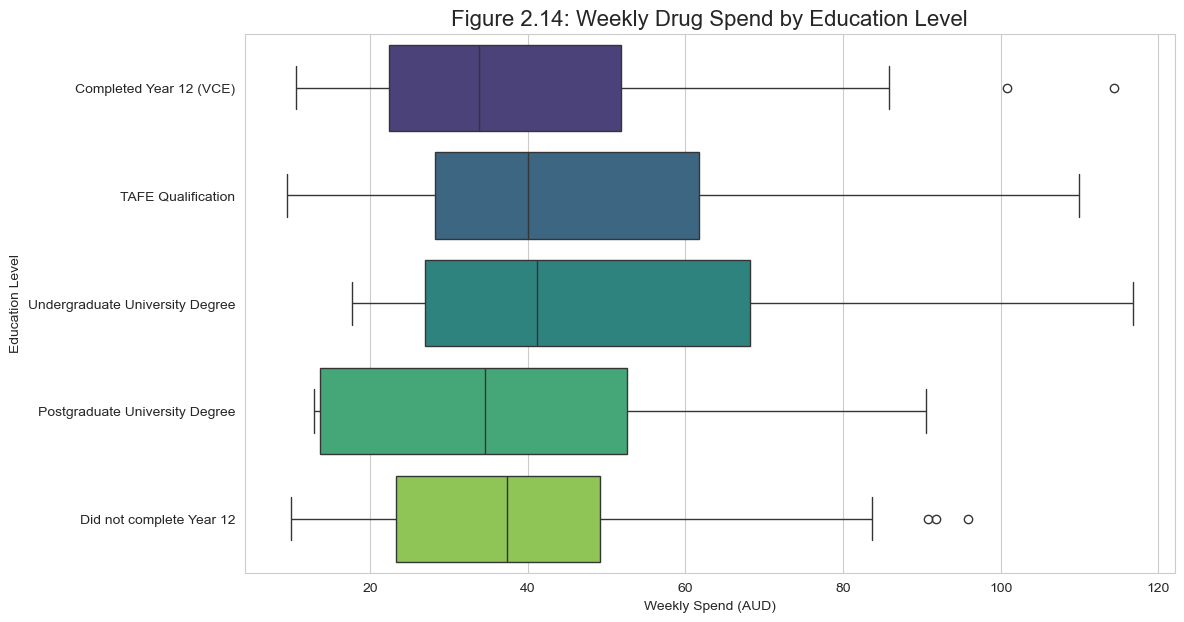

In [37]:
# Visualize with a boxplot
plt.figure(figsize=(12, 7))
sns.boxplot(x='Q16_WeeklySpend', y='Q3_Education', data=drug_df, palette='viridis')
plt.title('Figure 2.14: Weekly Drug Spend by Education Level', fontsize=16)
plt.xlabel('Weekly Spend (AUD)')
plt.ylabel('Education Level')
plt.show()

## Phase 2.1: Linear Regression - Factors Impacting Drug Spend

In [38]:
# Convert Likert scale text to numbers for proper correlation analysis
gender_mapping = {
    'Male': 1, 'Female': 2
}

education_mapping = {
    'Did not complete Year 12': 1,
    'Completed Year 12 (VCE)': 2,
    'TAFE Qualification': 3,
    'Undergraduate University Degree': 4,
    'Postgraduate University Degree': 5
}

employment_status_mapping = {
    'Student': 1,
    'Employed full-time': 2,
    'Employed part-time': 3,
    'Unemployed': 4,
    'Self-employed': 5
}

family_finance_mapping = {
    'Struggled to meet basic needs': 1,
    'Met basic needs, but with some difficulty': 2,
    'Comfortable, able to meet most needs': 3,
    'Very comfortable, rarely had to worry about money': 4
}

home_location_mapping = {
    'A large city': 1,
    'A suburb of a large city': 2,
    'A town': 3,
    'A rural area': 4
}

family_history_mapping = {
    'Yes': 1,
    'No': 2
}

motivation_mapping = {
    'Curiosity': 1,
    'To fit in with friends': 2,
    'To relieve stress or anxiety': 3,
    'To escape problems': 4,
    'To seek a \'high\' or plessure': 5,
    'To cope with boredom': 6
}

frequency_mapping = {
    'Daily': 1,
    'Several times a week': 2,
    'Once a week': 3,
    '1-3 times a month': 4,
    'Less than once a month': 5
}

setting_mapping = {
    'At home alone': 1,
    'At a friend\'s house': 2,
    'At a party or social gathering': 3,
    'At a club or bar': 4,
    'Outdoors (e.g., park, street)': 5
}

interestedinhelp_mapping = {
    'Yes, actively': 1,
    'Yes, considering': 2,
    'Not sure': 3,
    'No': 4
}

# Apply mapping to categorical columns
drug_df_reg = drug_df.copy()

drug_df_reg['Q2_Gender'] = drug_df_reg['Q2_Gender'].map(gender_mapping)
drug_df_reg['Q3_Education'] = drug_df_reg['Q3_Education'].map(education_mapping)
drug_df_reg['Q4_Employment'] = drug_df_reg['Q4_Employment'].map(employment_status_mapping)
drug_df_reg['Q5_FamilyFinance'] = drug_df_reg['Q5_FamilyFinance'].map(family_finance_mapping)
drug_df_reg['Q6_HomeLocation'] = drug_df_reg['Q6_HomeLocation'].map(home_location_mapping)
drug_df_reg['Q7_FamilyHistory'] = drug_df_reg['Q7_FamilyHistory'].map(family_history_mapping)
drug_df_reg['Q12_FirstTimeMotivation'] = drug_df_reg['Q12_FirstTimeMotivation'].map(motivation_mapping)
drug_df_reg['Q18_Frequency'] = drug_df_reg['Q18_Frequency'].map(frequency_mapping)
drug_df_reg['Q19_Setting'] = drug_df_reg['Q19_Setting'].map(setting_mapping)
drug_df_reg['Q20_InterestInHelp'] = drug_df_reg['Q20_InterestInHelp'].map(interestedinhelp_mapping)

In [39]:
y = drug_df_reg['Q16_WeeklySpend']

X_cols = [
    'Q1_Age',
    'Q2_Gender',
    # 'Q3_Education',
    # 'Q4_Employment',
    'Q5_FamilyFinance',
    'Q6_HomeLocation',
    'Q7_FamilyHistory',
    'Q8.1_Stress',
    'Q8.2_PeerPressure',
    'Q8.3_Normality',
    'Q8.4_ExploreIdentity',
    'Q8.5_HomeProblem',
    # 'Q8.6_ConfidentToSayNo',
    # 'Q12_FirstTimeMotivation',
    # 'Q18_Frequency',
    # 'Q19_Setting'
]
X = drug_df_reg[X_cols]


model = sm.OLS(y, X)
results = model.fit()

In [40]:
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:        Q16_WeeklySpend   R-squared (uncentered):                   0.886
Model:                            OLS   Adj. R-squared (uncentered):              0.880
Method:                 Least Squares   F-statistic:                              148.0
Date:                Sun, 22 Mar 2026   Prob (F-statistic):                    5.04e-84
Time:                        10:26:34   Log-Likelihood:                         -846.03
No. Observations:                 200   AIC:                                      1712.
Df Residuals:                     190   BIC:                                      1745.
Df Model:                          10                                                  
Covariance Type:            nonrobust                                                  
========================================================================================
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Q1_Age                   2.6840      0.473      5.670      0.000       1.750       3.618
Q2_Gender               -3.7317      2.446     -1.525      0.129      -8.557       1.094
Q5_FamilyFinance        -6.3272      2.149     -2.944      0.004     -10.567      -2.087
Q6_HomeLocation          1.2155      1.125      1.080      0.282      -1.005       3.435
Q7_FamilyHistory        -3.6770      2.483     -1.481      0.140      -8.574       1.221
Q8.1_Stress             -0.5572      2.255     -0.247      0.805      -5.005       3.891
Q8.2_PeerPressure      -11.4966      1.651     -6.965      0.000     -14.752      -8.241
Q8.3_Normality           0.9015      1.698      0.531      0.596      -2.448       4.251
Q8.4_ExploreIdentity    23.5928      1.671     14.120      0.000      20.297      26.889
Q8.5_HomeProblem        -6.1541      2.547     -2.416      0.017     -11.178      -1.131
==============================================================================
Omnibus:                       24.988   Durbin-Watson:                   2.102
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               35.598
Skew:                           0.749   Prob(JB):                     1.86e-08
Kurtosis:                       4.425   Cond. No.                         62.5
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## Phase 2.2: Machine Learning Classification

In [42]:
# Feature Engineering
# We'll drop 'Unsure' responses for binary classification (1=interested, 0=not interested)
df_model = drug_df_reg[drug_df_reg['Q20_InterestInHelp'] != 3].copy()

interested_map = {
    1: 1,  # Yes, actively
    2: 1,  # Yes, considering
    4: 0   # No
}

df_model['InterestInHelp'] = df_model['Q20_InterestInHelp'].map(interested_map)

y = df_model['InterestInHelp']

In [43]:
# Define the features 'X'
features = [
    'Q1_Age', 'Q15_FirstUseAge', 'Q16_WeeklySpend', # Numeric
    'Q2_Gender', 'Q4_Employment', 'Q5_FamilyFinance', 'Q7_FamilyHistory', 'Q18_Frequency', # Categorical
    'Q8.1_Stress', 'Q8.2_PeerPressure', 'Q8.3_Normality', 'Q8.5_HomeProblem' # Likert (numeric)
]
X = df_model[features]

In [44]:
# Preprocessing Pipeline

# We need to create two lists of our features: one for numerical (to be scaled) and one for categorical (to be one-hot encoded).

numeric_features = ['Q1_Age', 'Q15_FirstUseAge', 'Q16_WeeklySpend',
                    'Q8.1_Stress', 'Q8.2_PeerPressure', 'Q8.3_Normality', 'Q8.5_HomeProblem']

categorical_features = ['Q2_Gender', 'Q4_Employment', 'Q5_FamilyFinance',
                        'Q7_FamilyHistory', 'Q18_Frequency']


# Create a 'preprocessor' that applies the correct transformation to the correct column
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

In [45]:
# Create Full Pipelines for Each Model

# 1. Logistic Regression
pipe_lr = Pipeline(steps=[('preprocessor', preprocessor),
                          ('classifier', LogisticRegression(max_iter=1000, random_state=88))])

# 2. Decision Tree
pipe_dt = Pipeline(steps=[('preprocessor', preprocessor),
                          ('classifier', DecisionTreeClassifier(random_state=88))])

# 3. Random Forest
pipe_rf = Pipeline(steps=[('preprocessor', preprocessor),
                          ('classifier', RandomForestClassifier(random_state=88))])

# 4. Naive Bayes (requires a special step to make the sparse matrix dense)
def make_dense(X):
    if hasattr(X, 'toarray'):
        return X.toarray()
    return X

pipe_nb = Pipeline(steps=[('preprocessor', preprocessor),
                          ('to_dense', FunctionTransformer(make_dense)),
                          ('classifier', GaussianNB())])

# Run Cross-Validation for Each Model
models = {
    "Logistic Regression": pipe_lr,
    "Decision Tree": pipe_dt,
    "Random Forest": pipe_rf,
    "Naive Bayes": pipe_nb
}

results = []

print("\n--- Running 10-Fold Cross-Validation ---")

for name, model in models.items():
    # Set up the 10-fold cross-validation
    kfold = KFold(n_splits=10, shuffle=True, random_state=42)
    
    # Get the cross-validation scores (we'll use 'accuracy' for comparison)
    cv_scores = cross_val_score(model, X, y, cv=kfold, scoring='accuracy')
    
    # Store the results
    results.append((name, cv_scores.mean(), cv_scores.std()))
    
    print(f"{name}: Mean Accuracy = {cv_scores.mean():.3f} (Std Dev = {cv_scores.std():.3f})")

# Sort and print the results
results_df = pd.DataFrame(results, columns=['Model', 'Mean Accuracy', 'Std Deviation'])
results_df = results_df.sort_values(by='Mean Accuracy', ascending=False)

print("\n--- Table 2.7: Model Comparison (Ranked by Accuracy) ---")
print(results_df)


--- Running 10-Fold Cross-Validation ---
Logistic Regression: Mean Accuracy = 0.877 (Std Dev = 0.085)
Decision Tree: Mean Accuracy = 0.869 (Std Dev = 0.079)
Random Forest: Mean Accuracy = 0.899 (Std Dev = 0.080)
Naive Bayes: Mean Accuracy = 0.820 (Std Dev = 0.125)

--- Table 2.7: Model Comparison (Ranked by Accuracy) ---
                 Model  Mean Accuracy  Std Deviation
2        Random Forest       0.898901       0.080197
0  Logistic Regression       0.876923       0.084843
1        Decision Tree       0.869231       0.078508
3          Naive Bayes       0.819780       0.125313



--- Running 10-Fold Cross-Validation with Training/Testing Scores ---
Logistic Regression:
  Training Accuracy = 0.967 (±0.008)
  Testing Accuracy  = 0.877 (±0.085)
  Overfitting Gap   = 0.090

Decision Tree:
  Training Accuracy = 1.000 (±0.000)
  Testing Accuracy  = 0.869 (±0.079)
  Overfitting Gap   = 0.131

Random Forest:
  Training Accuracy = 1.000 (±0.000)
  Testing Accuracy  = 0.899 (±0.080)
  Overfitting Gap   = 0.101

Naive Bayes:
  Training Accuracy = 0.856 (±0.013)
  Testing Accuracy  = 0.820 (±0.125)
  Overfitting Gap   = 0.036

------------------ Table 2.7: Model Comparison (Ranked by Test Accuracy) ------------------
              Model  Mean Train Accuracy  Train Std  Mean Test Accuracy  Test Std  Overfitting Gap
      Random Forest                1.000      0.000               0.899     0.080            0.101
Logistic Regression                0.967      0.008               0.877     0.085            0.090
      Decision Tree                1.000      0.000             

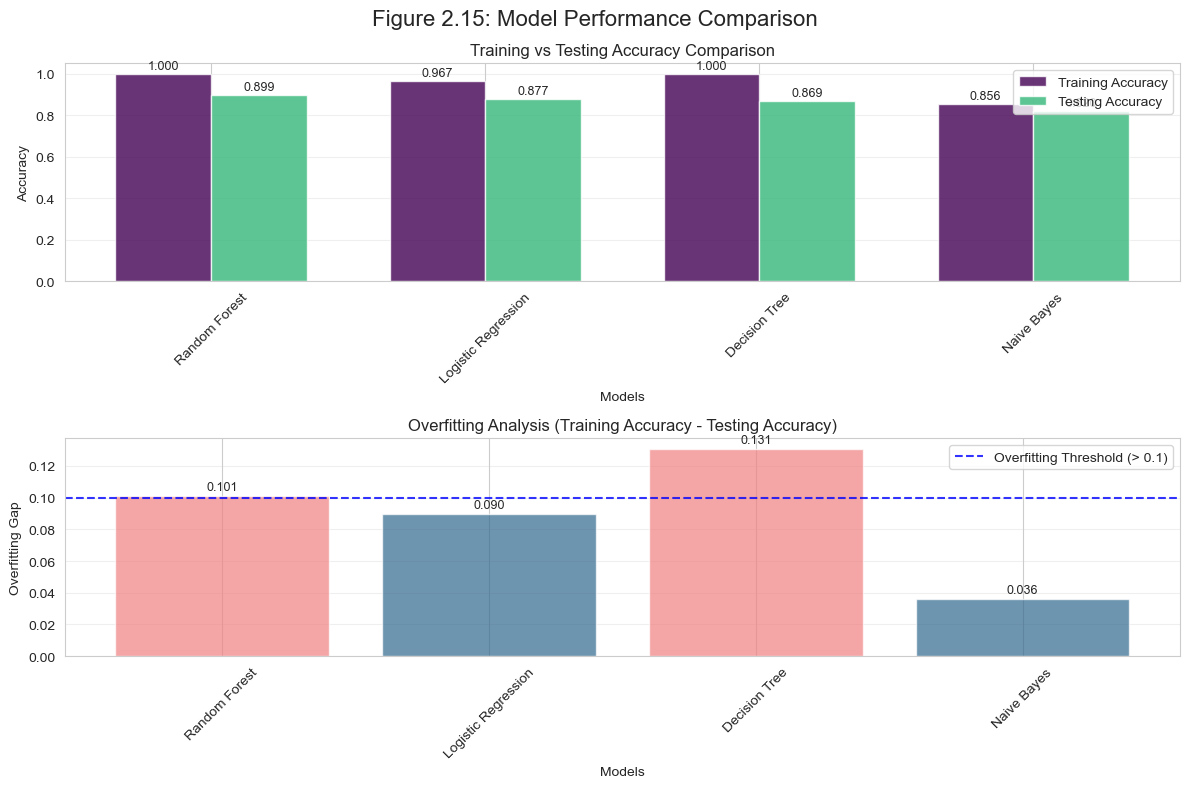

In [47]:
# Create Full Pipelines for Each Model

# 1. Logistic Regression
pipe_lr = Pipeline(steps=[('preprocessor', preprocessor),
                          ('classifier', LogisticRegression(max_iter=1000, random_state=88))])

# 2. Decision Tree
pipe_dt = Pipeline(steps=[('preprocessor', preprocessor),
                          ('classifier', DecisionTreeClassifier(random_state=88))])

# 3. Random Forest
pipe_rf = Pipeline(steps=[('preprocessor', preprocessor),
                          ('classifier', RandomForestClassifier(random_state=88))])

# 4. Naive Bayes (requires a special step to make the sparse matrix dense)
def make_dense(X):
    if hasattr(X, 'toarray'):
        return X.toarray()
    return X

pipe_nb = Pipeline(steps=[('preprocessor', preprocessor),
                          ('to_dense', FunctionTransformer(make_dense)),
                          ('classifier', GaussianNB())])

# Run Cross-Validation for Each Model with both training and testing scores
models = {
    "Logistic Regression": pipe_lr,
    "Decision Tree": pipe_dt,
    "Random Forest": pipe_rf,
    "Naive Bayes": pipe_nb
}

results = []

print("\n--- Running 10-Fold Cross-Validation with Training/Testing Scores ---")

for name, model in models.items():
    # Set up the 10-fold cross-validation
    kfold = KFold(n_splits=10, shuffle=True, random_state=42)
    
    # Get training and testing scores for each fold
    train_scores = []
    test_scores = []
    
    for train_idx, test_idx in kfold.split(X, y):
        X_train_fold, X_test_fold = X.iloc[train_idx], X.iloc[test_idx]
        y_train_fold, y_test_fold = y.iloc[train_idx], y.iloc[test_idx]
        
        # Fit the model on training data
        model.fit(X_train_fold, y_train_fold)
        
        # Score on training and testing data
        train_score = model.score(X_train_fold, y_train_fold)
        test_score = model.score(X_test_fold, y_test_fold)
        
        train_scores.append(train_score)
        test_scores.append(test_score)
    
    # Convert to numpy arrays for easier calculation
    train_scores = np.array(train_scores)
    test_scores = np.array(test_scores)
    
    # Calculate overfitting (difference between training and testing accuracy)
    overfitting = train_scores.mean() - test_scores.mean()
    
    # Store the results
    results.append((name, train_scores.mean(), train_scores.std(), 
                   test_scores.mean(), test_scores.std(), overfitting))
    
    print(f"{name}:")
    print(f"  Training Accuracy = {train_scores.mean():.3f} (±{train_scores.std():.3f})")
    print(f"  Testing Accuracy  = {test_scores.mean():.3f} (±{test_scores.std():.3f})")
    print(f"  Overfitting Gap   = {overfitting:.3f}")
    print()

# Create comprehensive results dataframe
results_df = pd.DataFrame(results, columns=['Model', 'Mean Train Accuracy', 'Train Std', 
                                          'Mean Test Accuracy', 'Test Std', 'Overfitting Gap'])
results_df = results_df.sort_values(by='Mean Test Accuracy', ascending=False)

print("------------------ Table 2.7: Model Comparison (Ranked by Test Accuracy) ------------------")
print(results_df.round(3).to_string(index=False))

# Create visualization comparing training vs testing accuracy
plt.figure(figsize=(12, 8))

# Add overall title for the entire figure
plt.suptitle('Figure 2.15: Model Performance Comparison', fontsize=16, y=0.98)

# Get viridis colors
viridis_colors = plt.cm.viridis(np.linspace(0, 1, 4))

# Prepare data for plotting
models_list = results_df['Model'].tolist()
train_acc = results_df['Mean Train Accuracy'].tolist()
test_acc = results_df['Mean Test Accuracy'].tolist()

x = np.arange(len(models_list))
width = 0.35

overfitting_threshold = 0.1

# Create bar plot
plt.subplot(2, 1, 1)
bars1 = plt.bar(x - width/2, train_acc, width, label='Training Accuracy', alpha=0.8, color=viridis_colors[0])
bars2 = plt.bar(x + width/2, test_acc, width, label='Testing Accuracy', alpha=0.8, color=viridis_colors[2])

plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.title('Training vs Testing Accuracy Comparison')
plt.xticks(x, models_list, rotation=45)
plt.legend()
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.3f}', ha='center', va='bottom', fontsize=9)

for bar in bars2:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.3f}', ha='center', va='bottom', fontsize=9)

# Create overfitting gap visualization
plt.subplot(2, 1, 2)
overfitting_gaps = results_df['Overfitting Gap'].tolist()
colors = ['lightcoral' if gap > overfitting_threshold else viridis_colors[1] for gap in overfitting_gaps]

bars3 = plt.bar(models_list, overfitting_gaps, color=colors, alpha=0.7)
plt.xlabel('Models')
plt.ylabel('Overfitting Gap')
plt.title('Overfitting Analysis (Training Accuracy - Testing Accuracy)')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.axhline(y=overfitting_threshold, color='blue', linestyle='--', alpha=0.8, label=f'Overfitting Threshold (> {overfitting_threshold})')
plt.legend()

# Add value labels on bars
for bar in bars3:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.002,
             f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

--- Final model (Random Forest) trained on all data. ---

--- Table 2.8: Top 10 Most Important Features ---
              Feature  Importance
1     Q15_FirstUseAge    0.195090
0              Q1_Age    0.144600
6    Q8.5_HomeProblem    0.128831
3         Q8.1_Stress    0.102785
2     Q16_WeeklySpend    0.066184
4   Q8.2_PeerPressure    0.050591
23    Q18_Frequency_4    0.042865
24    Q18_Frequency_5    0.040704
21    Q18_Frequency_2    0.035872
5      Q8.3_Normality    0.029706


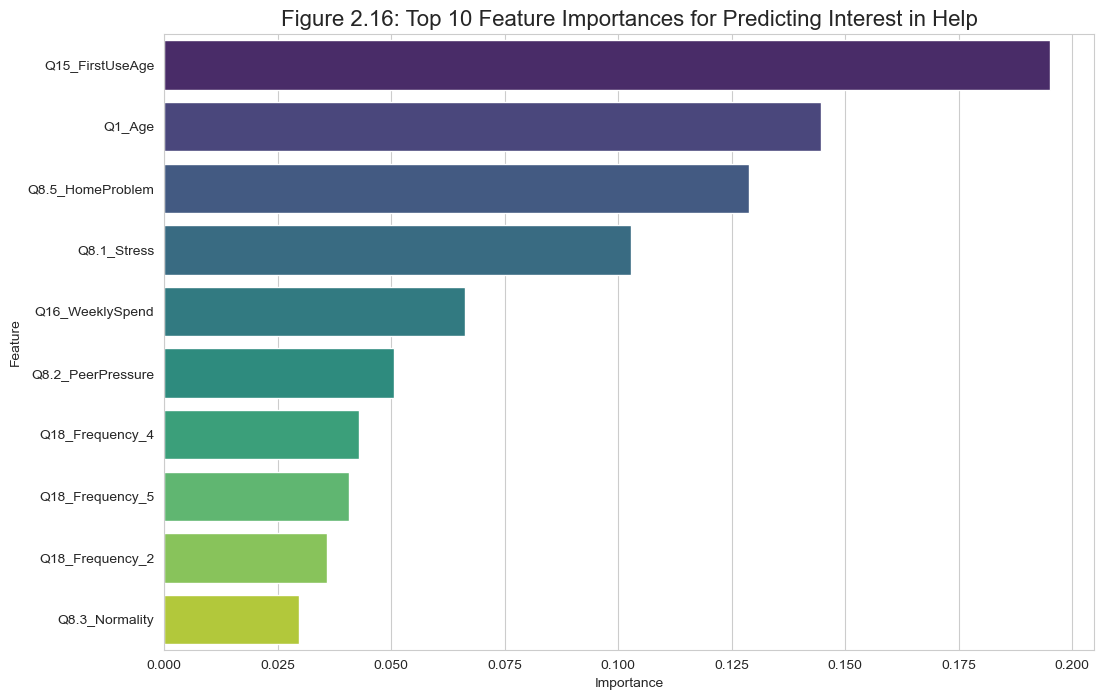

In [ ]:
# --- DRUG ANALYSIS PLAN: PHASE 2.2 (FINAL STEP) ---
#
# Goal: Train the best-performing model on the full dataset and
# extract its feature importances to understand WHAT factors are
# the most predictive.



# --- Step 1: Prepare Full Dataset (X and y) ---
# (This is the same as the previous step, just as a reminder)

# Let's assume 'drug_df' is loaded and Likert scales are numeric
# If not, run the necessary code from the previous steps first.

# Create a clean DataFrame for modeling, dropping "Unsure"
df_model = drug_df[drug_df['Q20_InterestInHelp'] != 'Unsure'].copy()

interested_map = {
    "Yes, actively seeking help": 1,
    "Yes, considering": 1,
    "No, I am not interested at this time.": 0
}
df_model['InterestInHelp'] = df_model['Q20_InterestInHelp'].map(interested_map)


df_model = drug_df_reg[drug_df_reg['Q20_InterestInHelp'] != 3].copy()

interested_map = {
    1: 1,  # Yes, actively
    2: 1,  # Yes, considering
    4: 0   # No
}

df_model['InterestInHelp'] = df_model['Q20_InterestInHelp'].map(interested_map)



y = df_model['InterestInHelp']
features = [
    'Q1_Age', 'Q15_FirstUseAge', 'Q16_WeeklySpend',
    'Q2_Gender', 'Q4_Employment', 'Q5_FamilyFinance', 'Q7_FamilyHistory', 'Q18_Frequency',
    'Q8.1_Stress', 'Q8.2_PeerPressure', 'Q8.3_Normality', 'Q8.5_HomeProblem'
]
X = df_model[features]



# --- Step 2: Define Preprocessor ---
# (Same as before)

numeric_features = ['Q1_Age', 'Q15_FirstUseAge', 'Q16_WeeklySpend',
                    'Q8.1_Stress', 'Q8.2_PeerPressure', 'Q8.3_Normality', 'Q8.5_HomeProblem']

categorical_features = ['Q2_Gender', 'Q4_Employment', 'Q5_FamilyFinance',
                        'Q7_FamilyHistory', 'Q18_Frequency']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])


# --- Step 3: Train the Final Model on ALL Data ---

# We will use the Random Forest pipeline.
# (If another model like Logistic Regression was your best, you can swap it here)

final_model_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                     ('classifier', RandomForestClassifier(random_state=42))])

# Fit the final model on 100% of the (filtered) data
final_model_pipeline.fit(X, y)

print("--- Final model (Random Forest) trained on all data. ---")


# --- Step 4: Extract and Visualize Feature Importances ---

# Get the feature importances from the classifier step
importances = final_model_pipeline.named_steps['classifier'].feature_importances_

# Get the names of the features *after* preprocessing
# This is a bit tricky but very important
ohe_feature_names = final_model_pipeline.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_features)
all_feature_names = np.concatenate([numeric_features, ohe_feature_names])

# Create a DataFrame for easy plotting
importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("\n--- Table 2.8: Top 10 Most Important Features ---")
print(importance_df.head(10))

# Plot the feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(10), palette='viridis') # Show top 10
plt.title('Figure 2.16: Top 10 Feature Importances for Predicting Interest in Help', fontsize=16)
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

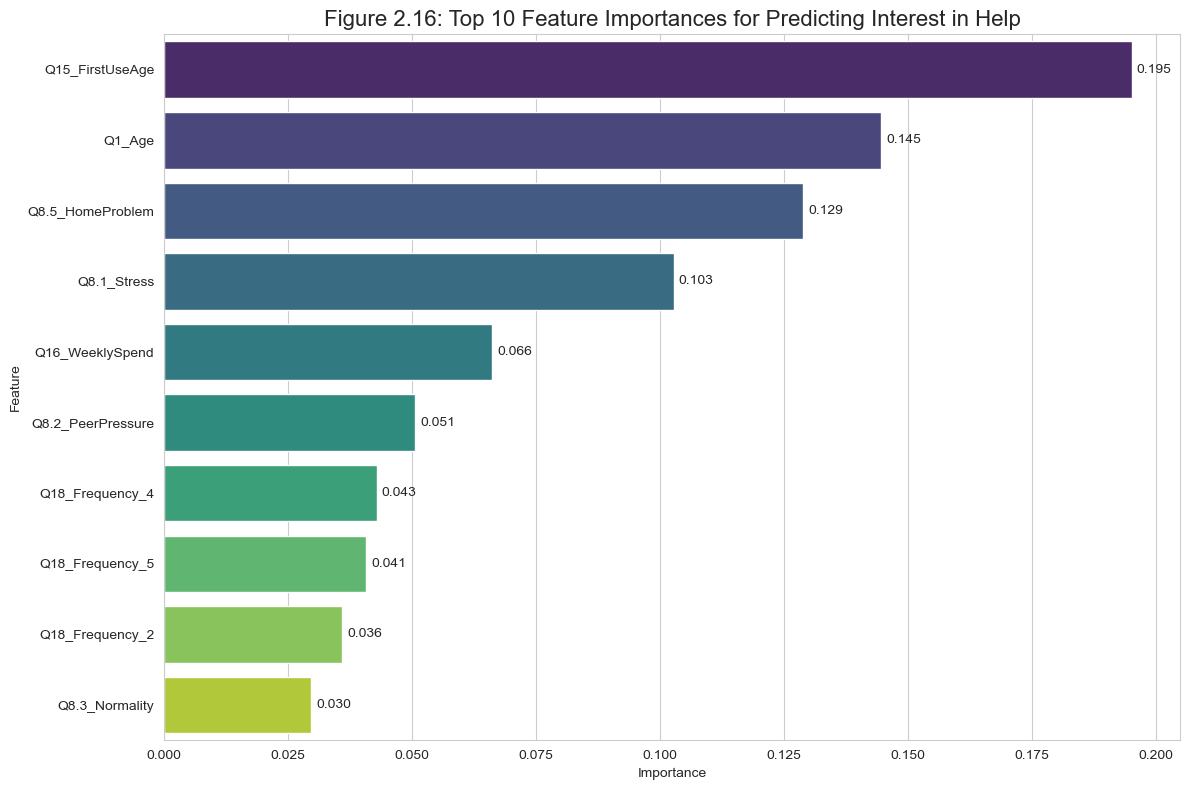

In [49]:
# Plot the feature importances with values displayed
plt.figure(figsize=(12, 8))
ax = sns.barplot(x='Importance', y='Feature', data=importance_df.head(10), palette='viridis')

# Add importance values as text on the bars
for i, v in enumerate(importance_df.head(10)['Importance']):
    ax.text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=10)

plt.title('Figure 2.16: Top 10 Feature Importances for Predicting Interest in Help', fontsize=16)
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


# Traveling Analysis

## 1.1 Data Preprocessing & Exploratory Data Analysis (EDA)

In [50]:
# Load the dataset
travel_df = pd.read_csv('stratified_travel_250_withText.csv', index_col=0)

In [51]:
travel_df.head()

,Q1_Age,Q2_Gender,Q3_MaritalStatus,Q4_Employment,Q5_Income,Q6_TripsPerYear,Q7_HolidayType,Q8_Budget,Q9_Priorities,Q10_BookingAdvance,Q11_InfoSources,Q12_BookingPreference,Q13_Accommodation,Q14_Africa,Q14_EAsia,Q14_Europe,Q14_NAmerica,Q14_Oceania,Q14_SAmerica,Q14_SEAsia,Q15_Customization,Q16_AdventureInterest,Q17_CustomServices,Q18_TechTrends,Q19_FuturePriorities
Respondent_ID,,,,,,,,,,,,,,,,,,,,,,,,,
1,20,Male,Single,Student,"A$100,000-A$149,999",6 times or more,Adventure,"5,912","Destination’s natural environment (e.g., mount...",3-6 months,Friends and family,I prefer package tours.,Hostel,No,No,No,No,No,No,Yes,Extremely important,Very interested,Flexible payment plans or advanced budgeting t...,AI and apps for hyper-personalized itinerary p...,"Relaxation, wellness, and disconnecting"
2,20,Male,In a relationship/ Partnered,Employed full-time,"A$100,000-A$149,999",1-2 time(s),Adventure,"6,247",Price,Within 1 week,Guidebooks,I prefer package tours.,Camping/ RV,No,No,No,No,No,No,No,Neutral,Somewhat interested,"Specialized all-inclusive packages (e.g., for ...",Virtual or Augmented Reality (VR/AR) to previe...,"Relaxation, wellness, and disconnecting"
3,20,Male,Single,Self-employed,"A$150,000 or more",1-2 time(s),Adventure,"3,559",Price,1-4 weeks,Friends and family,I prefer package tours.,Hotel,No,No,Yes,No,Yes,No,Yes,Neutral,Not interested at all,"Booking local activities, tours, and unique ex...",Enhanced connectivity and communication tools ...,"Budget, value, and affordability"
4,20,Male,Married,Student,"A$100,000-A$149,999",1-2 time(s),Adventure,"6,818",Safety,3-6 months,Guidebooks,I prefer to plan everything myself.,Hotel,No,No,No,No,No,No,Yes,Important,Neutral,"Booking local activities, tours, and unique ex...","Seamless in-travel tech (e.g., contactless che...","Relaxation, wellness, and disconnecting"
5,21,Female,Single,Employed full-time,"A$60,000-A$99,999",3-5 times,Cultural,"4,964","Destination’s natural environment (e.g., mount...",1-4 weeks,Guidebooks,I prefer to plan everything myself.,Camping/ RV,No,No,No,No,No,Yes,No,Neutral,Somewhat interested,"Practical and logistical support (e.g., visa a...",Virtual or Augmented Reality (VR/AR) to previe...,Authentic culture immersion and unique experie...


In [52]:
travel_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 250 entries, 1 to 250
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Q1_Age                 250 non-null    int64 
 1   Q2_Gender              250 non-null    object
 2   Q3_MaritalStatus       250 non-null    object
 3   Q4_Employment          250 non-null    object
 4   Q5_Income              250 non-null    object
 5   Q6_TripsPerYear        250 non-null    object
 6   Q7_HolidayType         250 non-null    object
 7   Q8_Budget              250 non-null    object
 8   Q9_Priorities          250 non-null    object
 9   Q10_BookingAdvance     250 non-null    object
 10  Q11_InfoSources        250 non-null    object
 11  Q12_BookingPreference  250 non-null    object
 12  Q13_Accommodation      250 non-null    object
 13  Q14_Africa             250 non-null    object
 14  Q14_EAsia              250 non-null    object
 15  Q14_Europe             250 n

In [53]:
# Data Cleaning: Q8_Budget, remove '$' and ',' then convert to numeric
travel_df['Q8_Budget'] = travel_df['Q8_Budget'].replace('[\$,]', '', regex=True).replace(',', '', regex=True)
travel_df['Q8_Budget'] = pd.to_numeric(travel_df['Q8_Budget'], errors='coerce')

In [54]:
# Data Cleaning: Map text-based Likert scales to numeric values for correlation analysis

# Mapping for Q15_Customization
customization_mapping = {
    'Not important at all': 1,
    'Slightly important': 2,
    'Neutral': 3,
    'Important': 4,
    'Extremely important': 5
}
if 'Q15_Customization' in travel_df.columns:
    travel_df['Q15_Customization'] = travel_df['Q15_Customization'].map(customization_mapping)
    
# Mapping for Q16_AdventureInterest
adventure_mapping = {
    'Not interested at all': 1,
    'Not very interested': 2,
    'Neutral': 3,
    'Somewhat interested': 4,
    'Very interested': 5
}
if 'Q16_AdventureInterest' in travel_df.columns:
    travel_df['Q16_AdventureInterest'] = travel_df['Q16_AdventureInterest'].map(adventure_mapping)

In [55]:
# 2.3: Check for missing values
print("\n--- Missing Values per Column (After Cleaning) ---")
print(travel_df.isnull().sum())

# Display info again to see the new numeric columns
print("\n--- Travel Dataframe Info (After Cleaning) ---")
travel_df.info()


--- Missing Values per Column (After Cleaning) ---
Q1_Age                   0
Q2_Gender                0
Q3_MaritalStatus         0
Q4_Employment            0
Q5_Income                0
Q6_TripsPerYear          0
Q7_HolidayType           0
Q8_Budget                0
Q9_Priorities            0
Q10_BookingAdvance       0
Q11_InfoSources          0
Q12_BookingPreference    0
Q13_Accommodation        0
Q14_Africa               0
Q14_EAsia                0
Q14_Europe               0
Q14_NAmerica             0
Q14_Oceania              0
Q14_SAmerica             0
Q14_SEAsia               0
Q15_Customization        0
Q16_AdventureInterest    0
Q17_CustomServices       0
Q18_TechTrends           0
Q19_FuturePriorities     0
dtype: int64

--- Travel Dataframe Info (After Cleaning) ---
<class 'pandas.core.frame.DataFrame'>
Index: 250 entries, 1 to 250
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Q1_Ag

### Mandatory Descriptive Summaries + Visualizations for EDA

In [56]:
# Summarise the numerical columns
numerical_cols = ['Q1_Age', 'Q8_Budget']
print("\n--- Table 1.1: Descriptive Statistics for Numerical Columns ---")
print(travel_df[numerical_cols].describe().round(2))


--- Table 1.1: Descriptive Statistics for Numerical Columns ---
       Q1_Age  Q8_Budget
count  250.00     250.00
mean    43.85    4593.08
std     13.25    1974.20
min     20.00    1148.00
25%     33.00    2995.50
50%     44.00    4544.00
75%     53.75    5926.25
max     75.00   10823.00


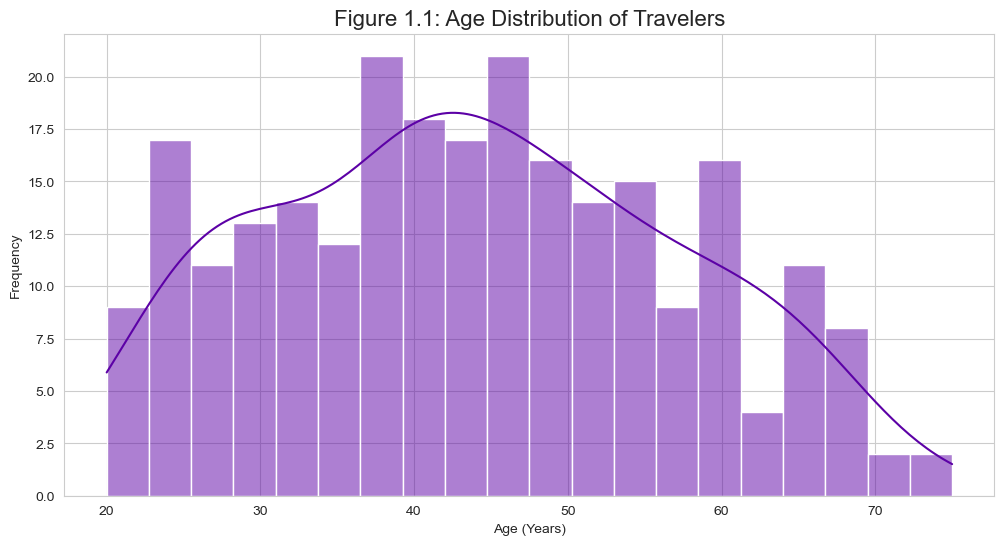

In [57]:
# Age Distribution on Travelers
plt.figure(figsize=(12, 6))
sns.histplot(travel_df['Q1_Age'], bins=20, kde=True, color=[0.362553, 0.003243, 0.649245, 1.      ])
plt.title('Figure 1.1: Age Distribution of Travelers', fontsize=16)
plt.xlabel('Age (Years)')
plt.ylabel('Frequency')
plt.show()

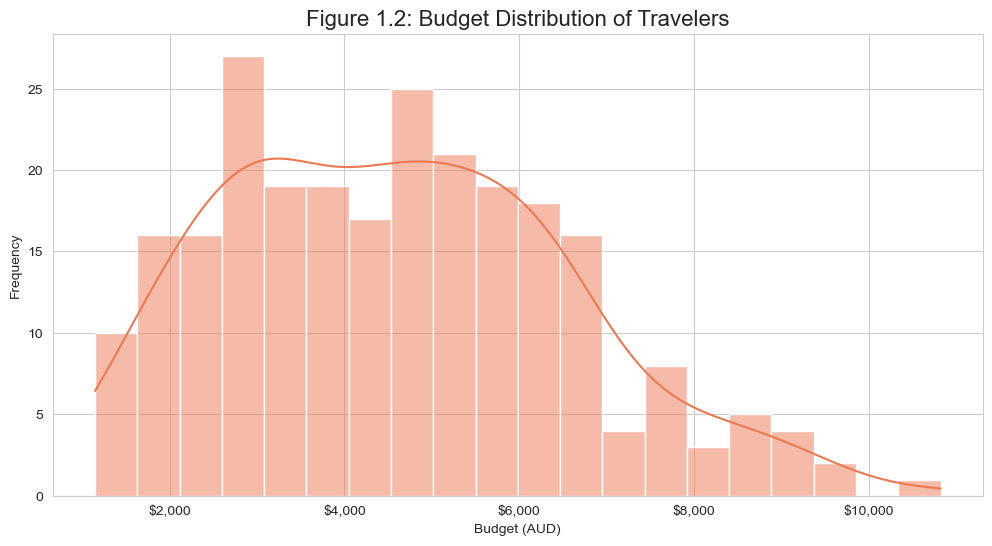

In [58]:
# Budget Distribution on Travelers
plt.figure(figsize=(12, 6))
sns.histplot(travel_df['Q8_Budget'], bins=20, kde=True, color=[0.928329, 0.472975, 0.326067, 1.      ])
plt.title('Figure 1.2: Budget Distribution of Travelers', fontsize=16)
plt.xlabel('Budget (AUD)')
plt.ylabel('Frequency')

# Add comma separators to x-axis
plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, p: f'${x:,.0f}'))

plt.show()

In [59]:
# Summarize Categorical Columns, including text-based Likert scales
categorical_cols = ['Q2_Gender', 'Q3_MaritalStatus', 'Q4_Employment', 'Q5_Income',
                    'Q6_TripsPerYear', 'Q7_HolidayType',
                    'Q9_Priorities', 'Q10_BookingAdvance',
                    'Q11_InfoSources', 'Q12_BookingPreference',
                    'Q13_Accommodation', 'Q14_Africa', 'Q14_EAsia',
                    'Q14_Europe', 'Q14_NAmerica', 'Q14_Oceania',
                    'Q14_SAmerica', 'Q14_SEAsia', 'Q15_Customization',
                    'Q16_AdventureInterest', 'Q17_CustomServices',
                    'Q18_TechTrends', 'Q19_FuturePriorities']

for col in categorical_cols:
    print(f"\n--- Value Counts for {col} ---")
    print(travel_df[col].value_counts())


--- Value Counts for Q2_Gender ---
Q2_Gender
Female    137
Male      113
Name: count, dtype: int64

--- Value Counts for Q3_MaritalStatus ---
Q3_MaritalStatus
In a relationship/ Partnered    74
Married                         66
Divorced/ Separated             48
Single                          39
Widowed                         23
Name: count, dtype: int64

--- Value Counts for Q4_Employment ---
Q4_Employment
Employed full-time    122
Unemployed             47
Student                34
Employed part-time     22
Self-employed          16
Retired                 9
Name: count, dtype: int64

--- Value Counts for Q5_Income ---
Q5_Income
A$60,000-A$99,999      64
A$100,000-A$149,999    58
A$30,000-A$59,999      58
A$150,000 or more      41
Less than A$30,000     29
Name: count, dtype: int64

--- Value Counts for Q6_TripsPerYear ---
Q6_TripsPerYear
1-2 time(s)        97
3-5 times          83
0                  57
6 times or more    13
Name: count, dtype: int64

--- Value Counts for Q7_Holi

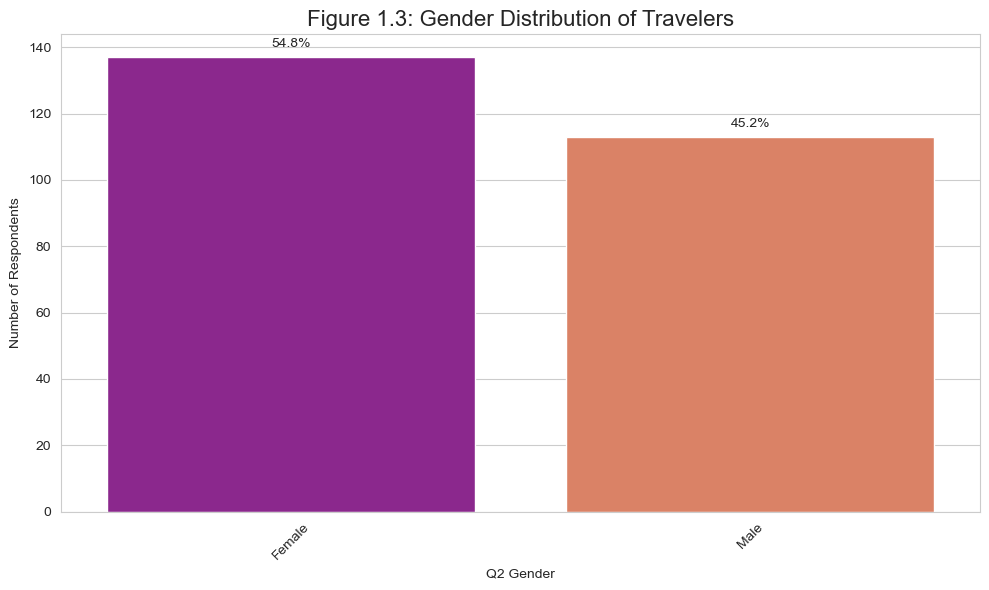


--- Q2_Gender Distribution Summary ---
Female: 137 respondents (54.8%)
Male: 113 respondents (45.2%)


In [60]:
plot_categorical_distribution(travel_df, column_name='Q2_Gender', title='Figure 1.3: Gender Distribution of Travelers', palette='plasma')

In [61]:
# 3.2: Summarise Categorical Data
print("\n--- Holiday Type Preference ---")
print(travel_df['Q7_HolidayType'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')


--- Holiday Type Preference ---
Q7_HolidayType
Cultural      46.0%
Adventure     23.2%
Relaxation    16.4%
Urban         14.4%
Name: proportion, dtype: object


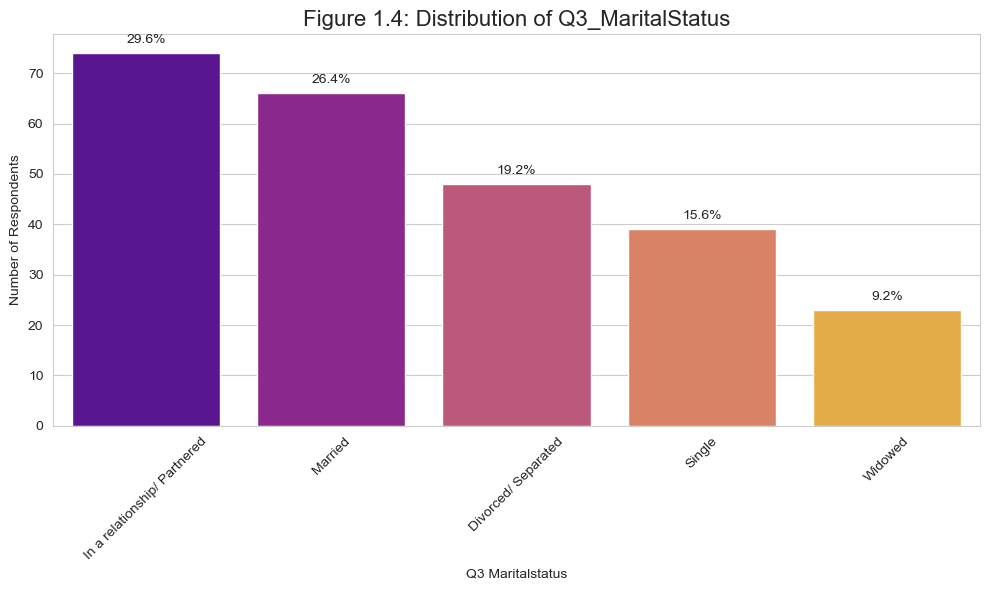


--- Q3_MaritalStatus Distribution Summary ---
In a relationship/ Partnered: 74 respondents (29.6%)
Married: 66 respondents (26.4%)
Divorced/ Separated: 48 respondents (19.2%)
Single: 39 respondents (15.6%)
Widowed: 23 respondents (9.2%)


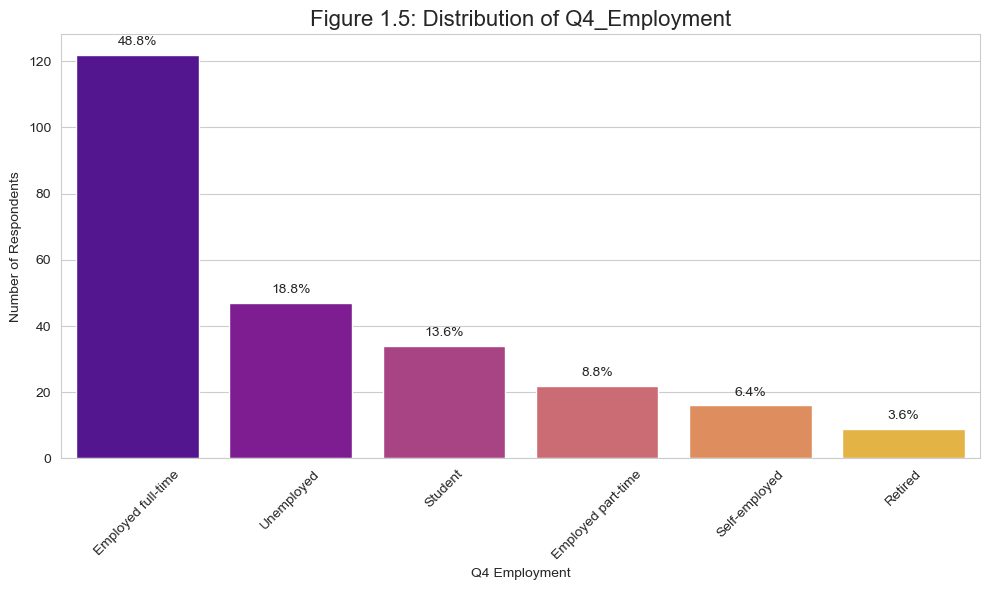


--- Q4_Employment Distribution Summary ---
Employed full-time: 122 respondents (48.8%)
Unemployed: 47 respondents (18.8%)
Student: 34 respondents (13.6%)
Employed part-time: 22 respondents (8.8%)
Self-employed: 16 respondents (6.4%)
Retired: 9 respondents (3.6%)


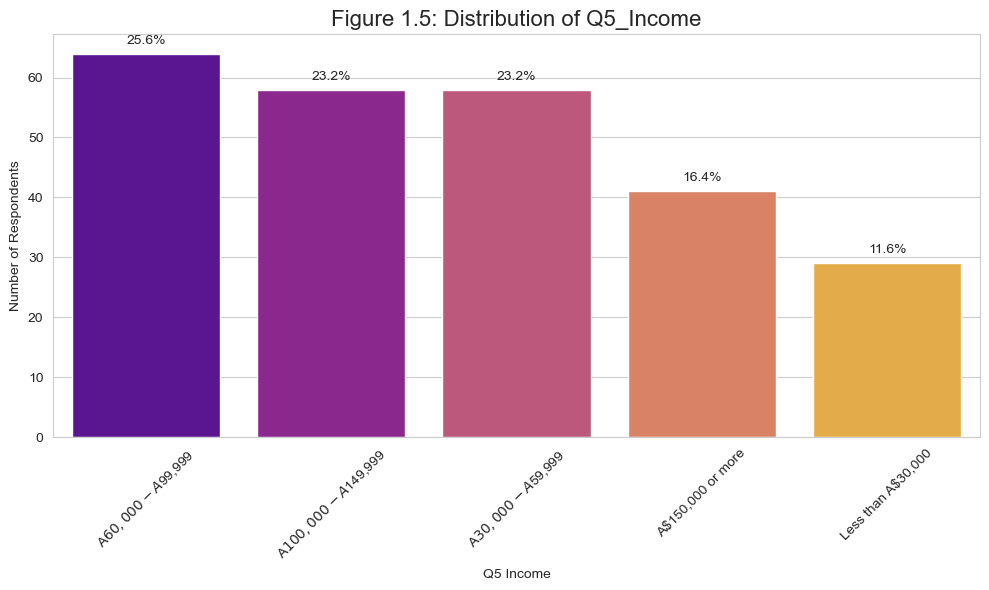


--- Q5_Income Distribution Summary ---
A$60,000-A$99,999: 64 respondents (25.6%)
A$100,000-A$149,999: 58 respondents (23.2%)
A$30,000-A$59,999: 58 respondents (23.2%)
A$150,000 or more: 41 respondents (16.4%)
Less than A$30,000: 29 respondents (11.6%)


<Figure size 640x480 with 0 Axes>

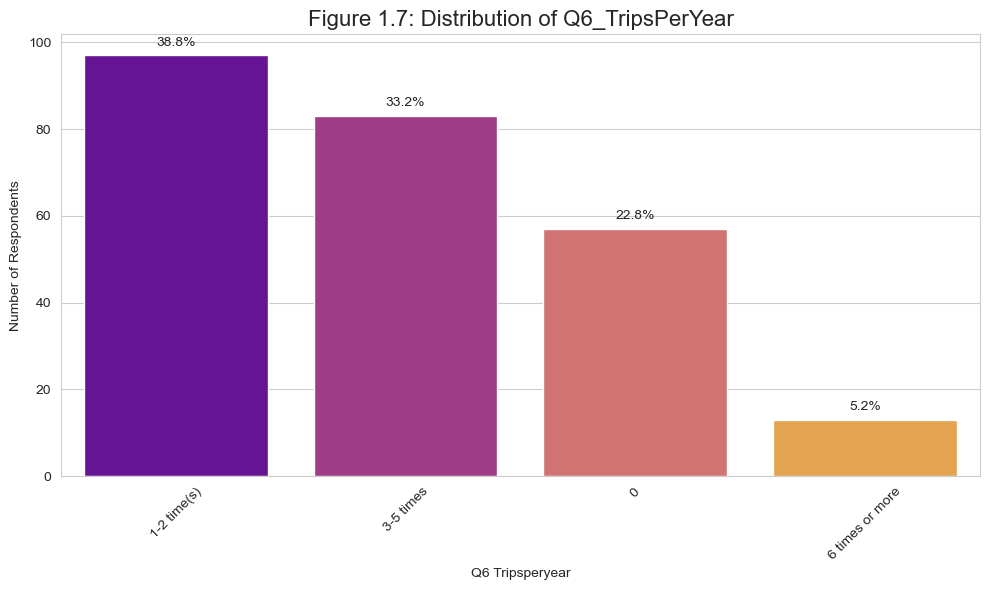


--- Q6_TripsPerYear Distribution Summary ---
1-2 time(s): 97 respondents (38.8%)
3-5 times: 83 respondents (33.2%)
0: 57 respondents (22.8%)
6 times or more: 13 respondents (5.2%)


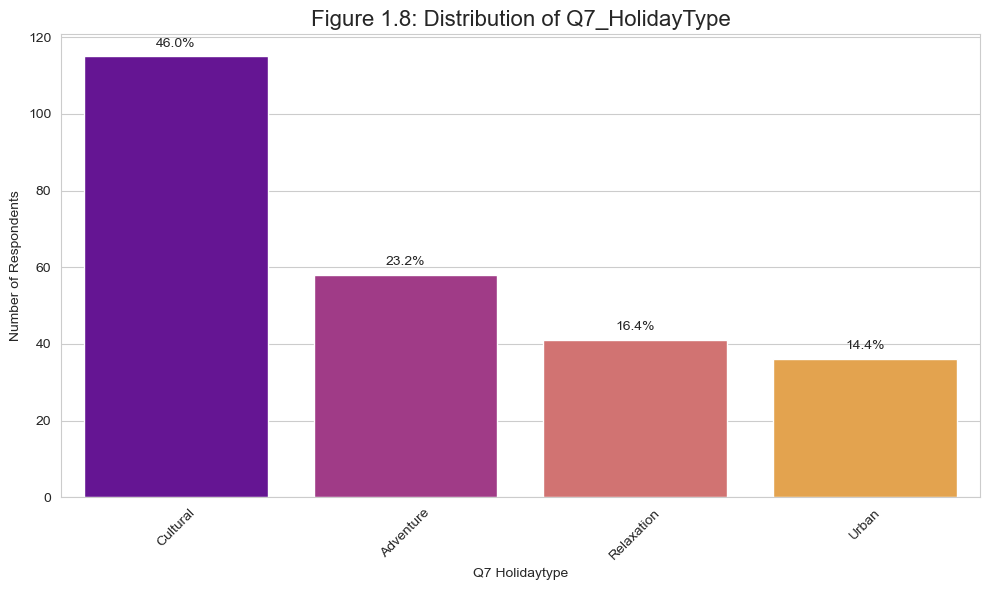


--- Q7_HolidayType Distribution Summary ---
Cultural: 115 respondents (46.0%)
Adventure: 58 respondents (23.2%)
Relaxation: 41 respondents (16.4%)
Urban: 36 respondents (14.4%)


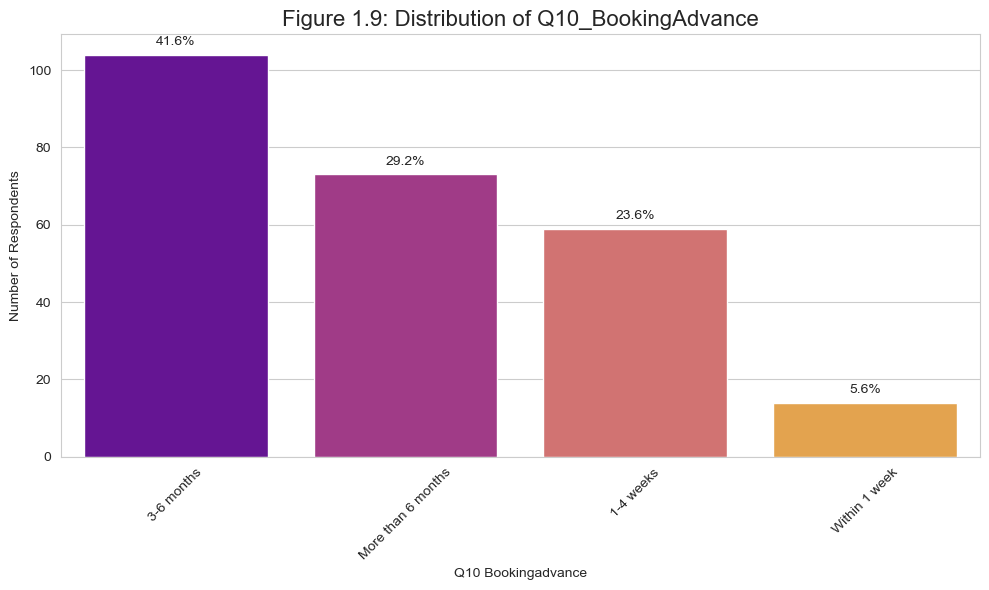


--- Q10_BookingAdvance Distribution Summary ---
3-6 months: 104 respondents (41.6%)
More than 6 months: 73 respondents (29.2%)
1-4 weeks: 59 respondents (23.6%)
Within 1 week: 14 respondents (5.6%)


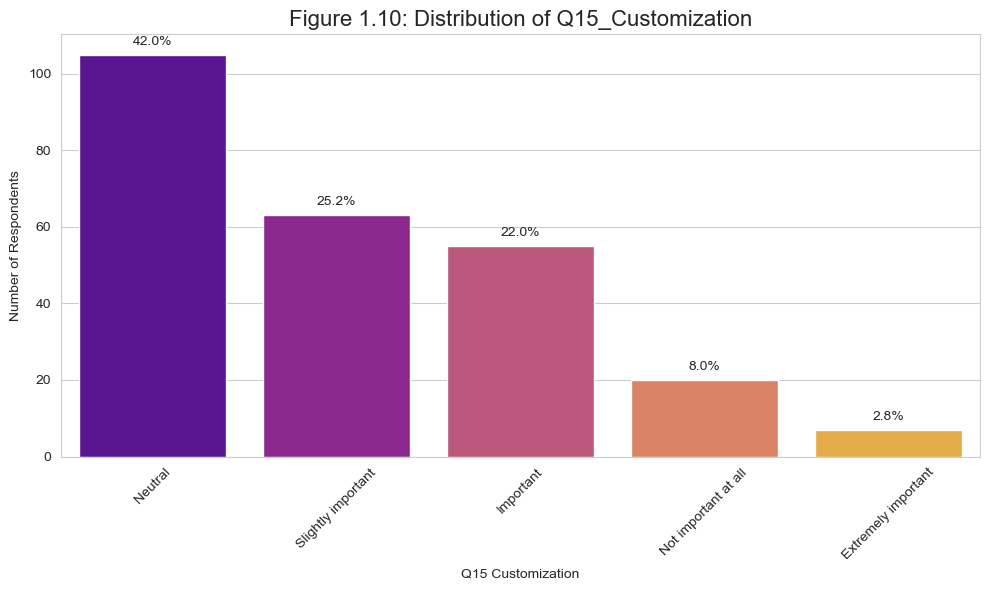


--- Q15_Customization Distribution Summary ---
Neutral: 105 respondents (42.0%)
Slightly important: 63 respondents (25.2%)
Important: 55 respondents (22.0%)
Not important at all: 20 respondents (8.0%)
Extremely important: 7 respondents (2.8%)


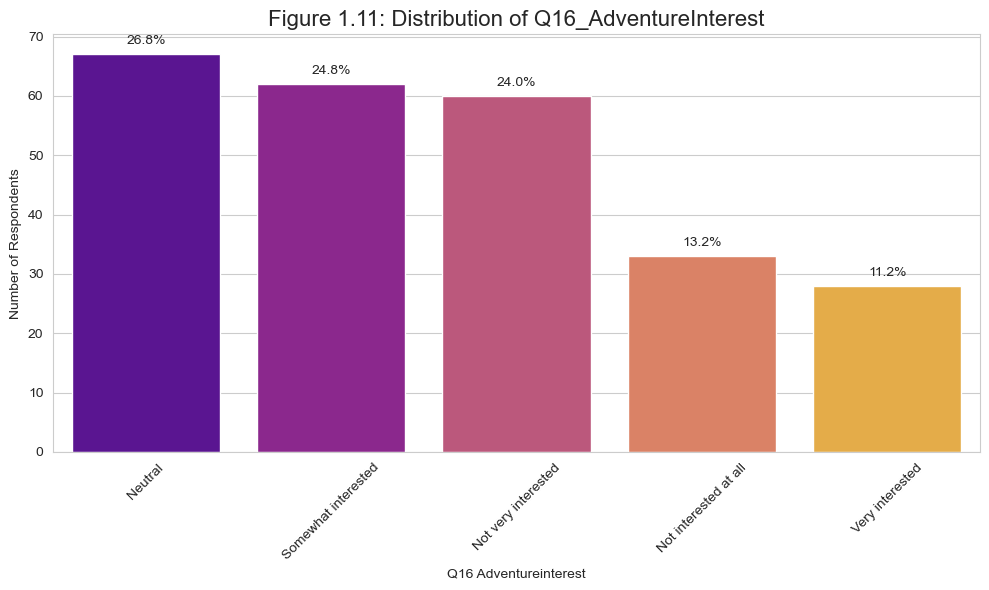


--- Q16_AdventureInterest Distribution Summary ---
Neutral: 67 respondents (26.8%)
Somewhat interested: 62 respondents (24.8%)
Not very interested: 60 respondents (24.0%)
Not interested at all: 33 respondents (13.2%)
Very interested: 28 respondents (11.2%)


In [62]:
# key categorical columns to plot
key_cat_cols = ['Q3_MaritalStatus', 'Q4_Employment', 'Q5_Income', 'Q6_TripsPerYear', 'Q7_HolidayType', 'Q10_BookingAdvance', 'Q15_Customization', 'Q16_AdventureInterest']

# Reverse mappings for plotting
customization_reverse_mapping = {
    1: 'Not important at all',
    2: 'Slightly important',
    3: 'Neutral',
    4: 'Important',
    5: 'Extremely important'
}

adventure_reverse_mapping = {
    1: 'Not interested at all',
    2: 'Not very interested',
    3: 'Neutral',
    4: 'Somewhat interested',
    5: 'Very interested'
}

for i, col in enumerate(key_cat_cols):
    # Create a copy of the data for plotting
    plot_data = travel_df.copy()
    
    # Map back to text values for Q15 and Q16 for better readability
    if col == 'Q15_Customization':
        plot_data[col] = plot_data[col].map(customization_reverse_mapping)
    elif col == 'Q16_AdventureInterest':
        plot_data[col] = plot_data[col].map(adventure_reverse_mapping)
    
    # Special handling for Q5_Income to add footnote
    if col == 'Q5_Income':
        plot_categorical_distribution(plot_data, column_name=col, title=f'Figure 1.{i+3}: Distribution of {col}', palette='plasma')
        plt.figtext(0.1, 0.02, 'Note: Q5_Income represents estimated annual household income, not individual income', 
                    fontsize=9, style='italic')
        plt.tight_layout()
        plt.show()
    else:
        plot_categorical_distribution(plot_data, column_name=col, title=f'Figure 1.{i+4}: Distribution of {col}', palette='plasma')

#### Popular Destinations

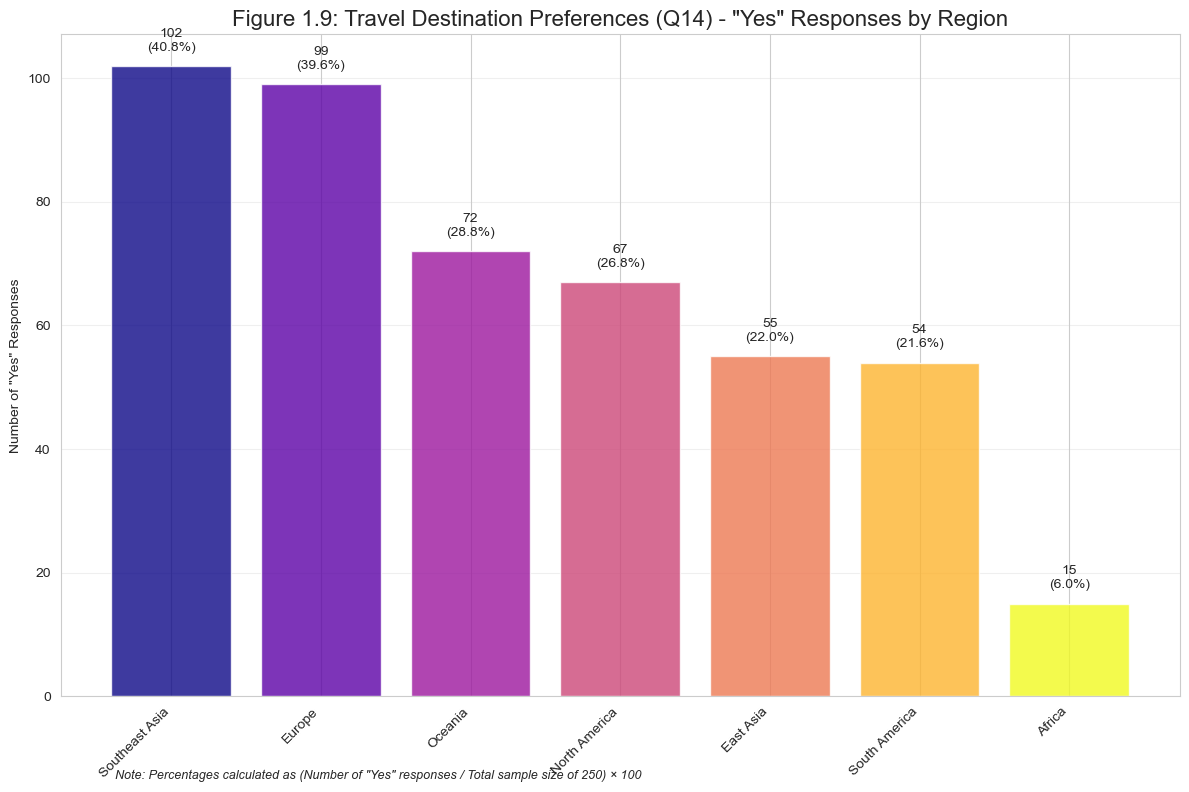

In [63]:
# Create a summary of 'Yes' responses for each region
factor_categorical_vars = ['Q14_Africa', 'Q14_EAsia', 'Q14_Europe', 'Q14_NAmerica', 'Q14_Oceania', 'Q14_SAmerica', 'Q14_SEAsia']

# Count 'Yes' responses for each region
yes_counts = []
region_names = []

factor_name_mapping = {
    'Q14_Africa': 'Africa',
    'Q14_EAsia': 'East Asia',
    'Q14_Europe': 'Europe',
    'Q14_NAmerica': 'North America',
    'Q14_Oceania': 'Oceania',
    'Q14_SAmerica': 'South America',
    'Q14_SEAsia': 'Southeast Asia'
}

for col in factor_categorical_vars:
    yes_count = (travel_df[col] == 'Yes').sum()
    yes_counts.append(yes_count)
    region_names.append(factor_name_mapping[col])

# Create DataFrame for easy sorting
region_data = pd.DataFrame({
    'Region': region_names,
    'Yes_Count': yes_counts,
    'Percentage': [(count / 250) * 100 for count in yes_counts]
})

# Sort by percentage in descending order
region_data = region_data.sort_values('Percentage', ascending=False)

# Create the plot with plasma palette
plt.figure(figsize=(12, 8))

# Generate plasma colors for the number of regions
plasma_colors = plt.cm.plasma(np.linspace(0, 1, len(region_data)))

bars = plt.bar(region_data['Region'], region_data['Yes_Count'], color=plasma_colors, alpha=0.8)

# Add count and percentage labels on each bar
for i, (bar, count, percentage) in enumerate(zip(bars, region_data['Yes_Count'], region_data['Percentage'])):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 2,
             f'{count}\n({percentage:.1f}%)', 
             ha='center', va='bottom', fontsize=10)

plt.title('Figure 1.9: Travel Destination Preferences (Q14) - "Yes" Responses by Region', fontsize=16)
plt.ylabel('Number of "Yes" Responses')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Add footnote
plt.figtext(0.1, 0.02, 'Note: Percentages calculated as (Number of "Yes" responses / Total sample size of 250) × 100', 
            fontsize=9, style='italic')

plt.tight_layout()
plt.show()


#### Correlation Matrix

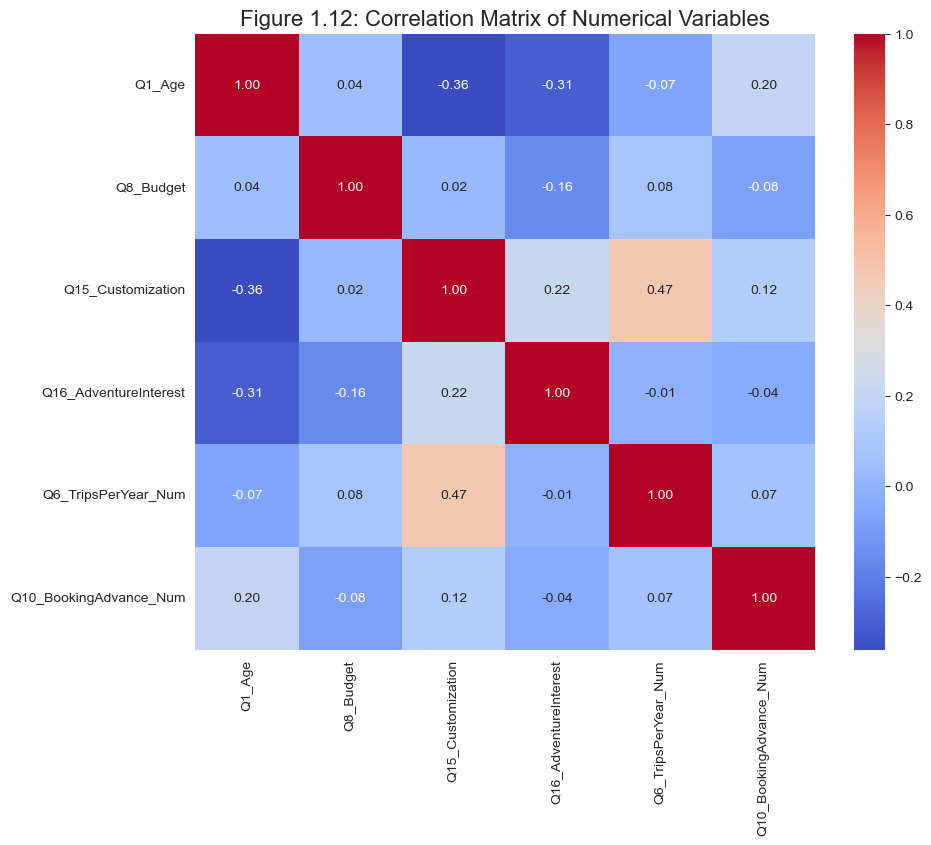

In [64]:
# Correlation Matrix for Numerical Variables
# Convert categorical variables to numeric for correlation analysis
trips_mapping = {
    0: 1,
    '1-2 time(s)': 2,
    '3-5 times': 3,
    '6 times or more': 4
}

booking_advance_mapping = {
    'Within 1 week': 1,
    '1-4 weeks': 2,
    '1-3 months': 3,
    '3-6 months': 4,
    'More than 6 months': 5
}

# Apply mappings
travel_df['Q6_TripsPerYear_Num'] = travel_df['Q6_TripsPerYear'].map(trips_mapping)
travel_df['Q10_BookingAdvance_Num'] = travel_df['Q10_BookingAdvance'].map(booking_advance_mapping)

# Correlation Matrix for Numerical Variables
corr_cols = ['Q1_Age', 'Q8_Budget', 'Q15_Customization', 'Q16_AdventureInterest', 
             'Q6_TripsPerYear_Num', 'Q10_BookingAdvance_Num']
# corr_df = travel_df[corr_cols].dropna() # Drop rows with NA in these specific cols
corr_df = travel_df[corr_cols]

plt.figure(figsize=(10, 8))
correlation_matrix = corr_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Figure 1.12: Correlation Matrix of Numerical Variables', fontsize=16)
plt.show()

## 1.2 Foundational Inferential Statistics & Group Comparisons

### 95% Confident Intervals

In [65]:
print("--- Analysis 1: 95% Confidence Intervals ---")

# 1.1: 95% CI for Mean Age
mean_age = travel_df['Q1_Age'].mean()
ci_age = stats.t.interval(0.95, df=len(travel_df)-1,
                          loc=mean_age,
                          scale=stats.sem(travel_df['Q1_Age']))

# 1.2: 95% CI for Mean Budget
mean_budget = travel_df['Q8_Budget'].mean()
ci_budget = stats.t.interval(0.95, df=len(travel_df)-1,
                            loc=mean_budget,
                            scale=stats.sem(travel_df['Q8_Budget']))

# Create a properly formatted table for confidence intervals
ci_results = pd.DataFrame({
    'Metric': [
        'Sample Size',
        'Mean Age (years)',
        '95% CI for Age - Lower Bound',
        '95% CI for Age - Upper Bound'
    ],
    'Value': [
        travel_df.shape[0],
        f"{mean_age:.2f}",
        f"{ci_age[0]:.2f}",
        f"{ci_age[1]:.2f}"
    ]
})

print("--- Table 1.2: 95% Confidence Intervals for Travel Data ---")
print("=" * 70)
print(ci_results.to_string(index=False))
print("=" * 70)

--- Analysis 1: 95% Confidence Intervals ---
--- Table 1.2: 95% Confidence Intervals for Travel Data ---
                      Metric Value
                 Sample Size   250
            Mean Age (years) 43.85
95% CI for Age - Lower Bound 42.20
95% CI for Age - Upper Bound 45.50


In [66]:
print("--- Analysis 1: 95% Confidence Intervals ---")

# 1.2: 95% CI for Mean Budget
mean_budget = travel_df['Q8_Budget'].mean()
ci_budget = stats.t.interval(0.95, df=len(travel_df)-1,
                            loc=mean_budget,
                            scale=stats.sem(travel_df['Q8_Budget']))

# Create a properly formatted table for confidence intervals
ci_results = pd.DataFrame({
    'Metric': [
        'Sample Size',
        'Mean Budget (AUD)',
        '95% CI for Budget - Lower Bound',
        '95% CI for Budget - Upper Bound'
    ],
    'Value': [
        travel_df.shape[0],
        f"${mean_budget:,.2f}",
        f"${ci_budget[0]:,.2f}",
        f"${ci_budget[1]:,.2f}"
    ]
})

print("--- Table 1.3: 95% Confidence Intervals for Travel Data ---")
print("=" * 70)
print(ci_results.to_string(index=False))
print("=" * 70)

--- Analysis 1: 95% Confidence Intervals ---
--- Table 1.3: 95% Confidence Intervals for Travel Data ---
                         Metric     Value
                    Sample Size       250
              Mean Budget (AUD) $4,593.08
95% CI for Budget - Lower Bound $4,347.17
95% CI for Budget - Upper Bound $4,839.00


### Stat-Test ANOVA (Budget vs. Age Group)

In [67]:
def perform_ttest_analysis(df, categorical_col, numerical_col, table_title=None, plot_title=None, palette="viridis"):
    """
    Perform independent t-test for a numerical variable across two groups of a categorical variable.
    
    Parameters:
    - df: DataFrame containing the data
    - categorical_col: name of the categorical column (must have exactly 2 unique values)
    - numerical_col: name of the numerical column
    - table_title: title for the results table (default: auto-generated)
    - plot_title: title for the plot (default: auto-generated)
    - palette: color palette for the plot
    
    Returns:
    - Dictionary containing test results and summary statistics
    """
    # Check if categorical variable has exactly 2 groups
    groups = df[categorical_col].unique()
    if len(groups) != 2:
        raise ValueError(f"Categorical variable must have exactly 2 groups, found {len(groups)}")
    
    # Set default titles if not provided
    if table_title is None:
        table_title = f"T-Test Results: {numerical_col} by {categorical_col}"
    if plot_title is None:
        plot_title = f"T-Test Analysis: {numerical_col} by {categorical_col}"
    
    # Split data into two groups
    group1_data = df[df[categorical_col] == groups[0]][numerical_col]
    group2_data = df[df[categorical_col] == groups[1]][numerical_col]
    
    # Perform t-test
    ttest_result = stats.ttest_ind(group1_data, group2_data, equal_var=False)
    
    # Create summary table
    summary_table = pd.DataFrame({
        'Statistic': ['T-statistic', 'P-value', 'Degrees of Freedom', 
                     f'Sample Size ({groups[0]})', f'Sample Size ({groups[1]})',
                     f'Mean {numerical_col} ({groups[0]})', f'Mean {numerical_col} ({groups[1]})',
                     f'SD {numerical_col} ({groups[0]})', f'SD {numerical_col} ({groups[1]})'],
        'Value': [f"{ttest_result.statistic:.4f}", 
                  f"{ttest_result.pvalue:.4f}",
                  f"{ttest_result.df:.1f}",
                  len(group1_data),
                  len(group2_data),
                  f"{group1_data.mean():.2f}",
                  f"{group2_data.mean():.2f}",
                  f"{group1_data.std():.2f}",
                  f"{group2_data.std():.2f}"]
    })
    
    # Print results
    print(table_title)
    print("=" * 60)
    print(summary_table.to_string(index=False))
    
    # Statistical interpretation
    alpha = 0.05
    print(f"\n{'='*60}")
    print("Statistical Interpretation:")
    print(f"α = {alpha}, p-value = {ttest_result.pvalue:.4f}")
    
    if ttest_result.pvalue < alpha:
        significance = "Significant"
        conclusion = "Reject null hypothesis"
    else:
        significance = "Not Significant"
        conclusion = "Fail to reject null hypothesis"
    
    print(f"Result: {significance} ({conclusion})")
    
    # Create boxplot
    plt.figure(figsize=(8, 6))
    sns.boxplot(x=categorical_col, y=numerical_col, data=df, palette=palette)
    plt.title(plot_title, fontsize=14)
    plt.ylabel(numerical_col)
    plt.xlabel(categorical_col)
    plt.show()
    
    return {
        'test_result': ttest_result,
        'summary_table': summary_table,
        'group1_stats': {'mean': group1_data.mean(), 'std': group1_data.std(), 'n': len(group1_data)},
        'group2_stats': {'mean': group2_data.mean(), 'std': group2_data.std(), 'n': len(group2_data)},
        'significance': significance
    }


def perform_anova_analysis(df, categorical_col, numerical_col, table_title=None, plot_title=None, palette="viridis"):
    """
    Perform one-way ANOVA for a numerical variable across multiple groups of a categorical variable.
    
    Parameters:
    - df: DataFrame containing the data
    - categorical_col: name of the categorical column
    - numerical_col: name of the numerical column
    - table_title: title for the results table (default: auto-generated)
    - plot_title: title for the plot (default: auto-generated)
    - palette: color palette for the plot
    
    Returns:
    - Dictionary containing ANOVA results and summary statistics
    """
    # Get unique groups
    groups = df[categorical_col].unique()
    
    # Check if we have more than 2 groups
    if len(groups) < 2:
        raise ValueError("Need at least 2 groups for ANOVA")
    
    # Set default titles if not provided
    if table_title is None:
        table_title = f"ANOVA Results: {numerical_col} by {categorical_col}"
    if plot_title is None:
        plot_title = f"ANOVA Analysis: {numerical_col} by {categorical_col}"
    
    # Prepare data for ANOVA
    grouped_data = [df[df[categorical_col] == group][numerical_col] for group in groups]
    
    # Perform ANOVA
    anova_result = stats.f_oneway(*grouped_data)
    
    # Calculate descriptive statistics for each group
    group_stats = []
    for group in groups:
        group_data = df[df[categorical_col] == group][numerical_col]
        group_stats.append({
            'Group': group,
            'N': len(group_data),
            'Mean': group_data.mean(),
            'SD': group_data.std(),
            'Min': group_data.min(),
            'Max': group_data.max()
        })
    
    group_stats_df = pd.DataFrame(group_stats)
    
    # Calculate ANOVA table components
    grand_mean = df[numerical_col].mean()
    n_total = len(df)
    k = len(groups)
    
    # Sum of squares
    ssb = sum([len(df[df[categorical_col] == group]) * 
               (df[df[categorical_col] == group][numerical_col].mean() - grand_mean)**2 
               for group in groups])
    
    ssw = sum([((df[df[categorical_col] == group][numerical_col] - 
                df[df[categorical_col] == group][numerical_col].mean())**2).sum() 
               for group in groups])
    
    sst = ssb + ssw
    
    # Degrees of freedom
    df_between = k - 1
    df_within = n_total - k
    df_total = n_total - 1
    
    # Mean squares
    msb = ssb / df_between
    msw = ssw / df_within
    
    # Create ANOVA table
    anova_table = pd.DataFrame({
        'Source': ['Between Groups', 'Within Groups', 'Total'],
        'SS': [f'{ssb:.2f}', f'{ssw:.2f}', f'{sst:.2f}'],
        'df': [df_between, df_within, df_total],
        'MS': [f'{msb:.2f}', f'{msw:.2f}', '-'],
        'F': [f'{anova_result.statistic:.4f}', '-', '-'],
        'p-value': [f'{anova_result.pvalue:.4f}', '-', '-']
    })
    
    # Print results
    print(table_title)
    print("=" * 70)
    
    print("\nDescriptive Statistics by Group:")
    print("-" * 70)
    for _, row in group_stats_df.iterrows():
        print(f"{row['Group']:<20} N={row['N']:>3} Mean={row['Mean']:>8.2f} SD={row['SD']:>8.2f} Range={row['Min']:>6.2f}-{row['Max']:>8.2f}")
    
    print(f"\n\nANOVA Table:")
    print("-" * 70)
    print(anova_table.to_string(index=False))
    
    # Statistical interpretation
    alpha = 0.05
    print(f"\n\nStatistical Interpretation:")
    print("-" * 70)
    
    if anova_result.pvalue < alpha:
        significance = "Significant"
        conclusion = "Reject null hypothesis"
        interpretation = f"There are significant differences in {numerical_col} between {categorical_col} groups."
    else:
        significance = "Not Significant"
        conclusion = "Fail to reject null hypothesis"
        interpretation = f"There are no significant differences in {numerical_col} between {categorical_col} groups."
    
    print(f"F({df_between}, {df_within}) = {anova_result.statistic:.4f}, p = {anova_result.pvalue:.4f}")
    print(f"α = {alpha}, Result: {significance}")
    print(f"Conclusion: {conclusion}")
    print(f"Interpretation: {interpretation}")
    
    # Create boxplot
    plt.figure(figsize=(12, 7))
    sns.boxplot(y=categorical_col, x=numerical_col, data=df, palette=palette)
    plt.title(plot_title, fontsize=14)
    plt.xlabel(numerical_col)
    plt.ylabel(categorical_col)
    plt.show()
    
    return {
        'anova_result': anova_result,
        'anova_table': anova_table,
        'group_stats': group_stats_df,
        'significance': significance,
        'f_statistic': anova_result.statistic,
        'p_value': anova_result.pvalue
    }

In [69]:
# Conduct ANOVA tests between budget and all categorical variables
categorical_vars = ['Q3_MaritalStatus', 'Q4_Employment', 'Q5_Income',
                   'Q6_TripsPerYear', 'Q7_HolidayType', 'Q9_Priorities', 
                   'Q10_BookingAdvance', 'Q11_InfoSources', 'Q12_BookingPreference',
                   'Q13_Accommodation', 'Q17_CustomServices', 'Q18_TechTrends', 
                   'Q19_FuturePriorities']

# Store results
anova_results = []

print("Conducting ANOVA tests between Q8_Budget and all categorical variables...\n")

for cat_var in categorical_vars:
    try:
        # Get unique groups and check if we have at least 2 groups
        groups = travel_df[cat_var].dropna().unique()
        
        if len(groups) >= 2:
            # Prepare data for ANOVA
            grouped_data = [travel_df[travel_df[cat_var] == group]['Q8_Budget'].dropna() 
                          for group in groups]
            
            # Remove empty groups
            grouped_data = [group for group in grouped_data if len(group) > 0]
            
            if len(grouped_data) >= 2:
                # Perform ANOVA
                anova_result = stats.f_oneway(*grouped_data)
                
                # Store results
                anova_results.append({
                    'Variable': cat_var,
                    'F_Statistic': anova_result.statistic,
                    'P_Value': anova_result.pvalue,
                    'Significant': 'Yes' if anova_result.pvalue < 0.05 else 'No',
                    'Num_Groups': len(groups)
                })
            else:
                print(f"Skipped {cat_var}: Insufficient data after removing missing values")
        else:
            print(f"Skipped {cat_var}: Less than 2 groups available")
            
    except Exception as e:
        print(f"Error with {cat_var}: {str(e)}")

# Create results DataFrame and sort by p-value
results_df = pd.DataFrame(anova_results)
results_df = results_df.sort_values('P_Value')

# Display results table
print("=" * 80)
print("Table 1.4: ANOVA Results - Travel Budget by All Categorical Variables")
print("=" * 80)
print(f"{'Variable':<25} {'F-Statistic':<12} {'P-Value':<10} {'Significant':<12} {'Groups':<8}")
print("-" * 80)

for _, row in results_df.iterrows():
    print(f"{row['Variable']:<25} {row['F_Statistic']:<12.4f} {row['P_Value']:<10.4f} "
          f"{row['Significant']:<12} {row['Num_Groups']:<8}")

print("=" * 80)

# Summary of significant results
significant_vars = results_df[results_df['Significant'] == 'Yes']
print(f"\nSummary: {len(significant_vars)} out of {len(results_df)} variables show significant differences")
if len(significant_vars) > 0:
    print("\nSignificant variables (α = 0.05):")
    for _, row in significant_vars.iterrows():
        print(f"  • {row['Variable']}: F = {row['F_Statistic']:.4f}, p = {row['P_Value']:.4f}")

Conducting ANOVA tests between Q8_Budget and all categorical variables...

Table 1.4: ANOVA Results - Travel Budget by All Categorical Variables
Variable                  F-Statistic  P-Value    Significant  Groups  
--------------------------------------------------------------------------------
Q5_Income                 14.5043      0.0000     Yes          5       
Q10_BookingAdvance        5.8054       0.0008     Yes          4       
Q6_TripsPerYear           2.7759       0.0419     Yes          4       
Q13_Accommodation         2.1844       0.0713     No           5       
Q7_HolidayType            1.6983       0.1680     No           4       
Q3_MaritalStatus          1.5712       0.1826     No           5       
Q9_Priorities             1.1991       0.3039     No           8       
Q11_InfoSources           1.1079       0.3583     No           7       
Q19_FuturePriorities      0.8520       0.4667     No           4       
Q4_Employment             0.9072       0.4770     No  

### Budget by Household Income (ANOVA test)

Table 1.5: ANOVA Results - Travel Budget by Household Income Status

Descriptive Statistics by Group:
----------------------------------------------------------------------
A$100,000-A$149,999  N= 58 Mean= 5207.12 SD= 2135.80 Range=1389.00-10823.00
A$150,000 or more    N= 41 Mean= 5893.78 SD= 1814.35 Range=2207.00- 9736.00
A$60,000-A$99,999    N= 64 Mean= 4524.25 SD= 1774.62 Range=1148.00- 9178.00
Less than A$30,000   N= 29 Mean= 3093.31 SD= 1072.51 Range=1231.00- 6638.00
A$30,000-A$59,999    N= 58 Mean= 3885.43 SD= 1687.71 Range=1282.00- 8135.00


ANOVA Table:
----------------------------------------------------------------------
        Source           SS  df          MS       F p-value
Between Groups 185811013.63   4 46452753.41 14.5043  0.0000
 Within Groups 784656591.61 245  3202679.97       -       -
         Total 970467605.24 249           -       -       -


Statistical Interpretation:
----------------------------------------------------------------------
F(4, 245) = 14.5043,

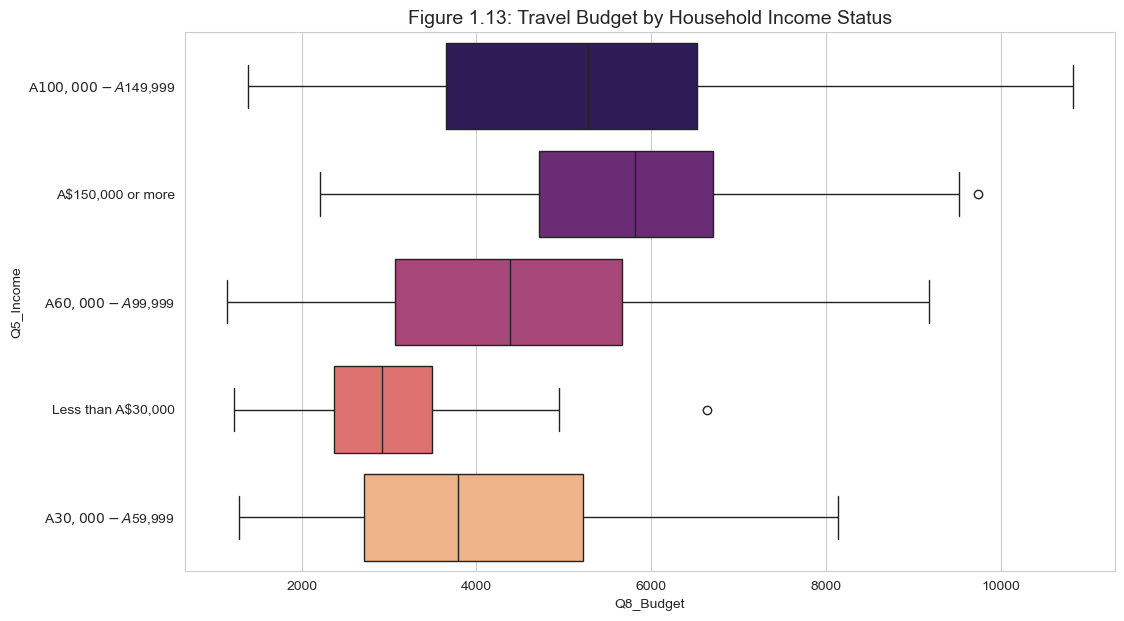

{'anova_result': F_onewayResult(statistic=14.504338211440094, pvalue=1.2062454611388027e-10),
 'anova_table':            Source            SS   df           MS        F p-value
 0  Between Groups  185811013.63    4  46452753.41  14.5043  0.0000
 1   Within Groups  784656591.61  245   3202679.97        -       -
 2           Total  970467605.24  249            -        -       -,
 'group_stats':                  Group   N         Mean           SD   Min    Max
 0  A$100,000-A$149,999  58  5207.120690  2135.795551  1389  10823
 1    A$150,000 or more  41  5893.780488  1814.349243  2207   9736
 2    A$60,000-A$99,999  64  4524.250000  1774.623546  1148   9178
 3   Less than A$30,000  29  3093.310345  1072.506047  1231   6638
 4    A$30,000-A$59,999  58  3885.431034  1687.710201  1282   8135,
 'significance': 'Significant',
 'f_statistic': 14.504338211440094,
 'p_value': 1.2062454611388027e-10}

In [70]:
# budget by household income status
perform_anova_analysis(travel_df, 
                      categorical_col='Q5_Income', 
                      numerical_col='Q8_Budget',
                      table_title="Table 1.5: ANOVA Results - Travel Budget by Household Income Status",
                      plot_title="Figure 1.13: Travel Budget by Household Income Status",
                      palette='magma')

### Budget by BookingAdvance (ANOVA test)

Table 1.6: ANOVA Results - Travel Budget by Booking Advance

Descriptive Statistics by Group:
----------------------------------------------------------------------
3-6 months           N=104 Mean= 4683.55 SD= 2102.80 Range=1304.00- 9526.00
Within 1 week        N= 14 Mean= 6525.36 SD= 1459.93 Range=3488.00- 9218.00
1-4 weeks            N= 59 Mean= 4221.51 SD= 1597.97 Range=1302.00- 8559.00
More than 6 months   N= 73 Mean= 4393.95 SD= 1954.52 Range=1148.00-10823.00


ANOVA Table:
----------------------------------------------------------------------
        Source           SS  df          MS      F p-value
Between Groups  64163563.74   3 21387854.58 5.8054  0.0008
 Within Groups 906304041.50 246  3684162.77      -       -
         Total 970467605.24 249           -      -       -


Statistical Interpretation:
----------------------------------------------------------------------
F(3, 246) = 5.8054, p = 0.0008
α = 0.05, Result: Significant
Conclusion: Reject null hypothesis
Interpretati

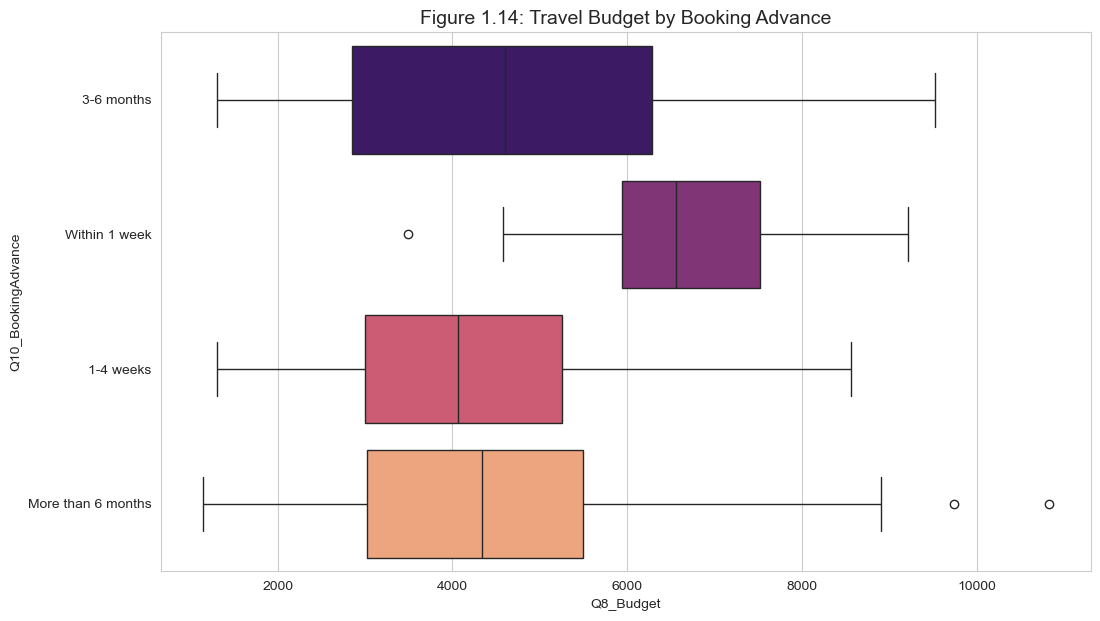

{'anova_result': F_onewayResult(statistic=5.805350065085583, pvalue=0.0007547706514767424),
 'anova_table':            Source            SS   df           MS       F p-value
 0  Between Groups   64163563.74    3  21387854.58  5.8054  0.0008
 1   Within Groups  906304041.50  246   3684162.77       -       -
 2           Total  970467605.24  249            -       -       -,
 'group_stats':                 Group    N         Mean           SD   Min    Max
 0          3-6 months  104  4683.548077  2102.797895  1304   9526
 1       Within 1 week   14  6525.357143  1459.925741  3488   9218
 2           1-4 weeks   59  4221.508475  1597.971444  1302   8559
 3  More than 6 months   73  4393.945205  1954.521630  1148  10823,
 'significance': 'Significant',
 'f_statistic': 5.805350065085583,
 'p_value': 0.0007547706514767424}

In [71]:
perform_anova_analysis(travel_df, 
                      categorical_col='Q10_BookingAdvance', 
                      numerical_col='Q8_Budget',
                      table_title="Table 1.6: ANOVA Results - Travel Budget by Booking Advance",
                      plot_title="Figure 1.14: Travel Budget by Booking Advance",
                      palette='magma')

### Budget by TripsPerYear (ANOVA test)

Table 1.7: ANOVA Results - Travel Budget by Number of Trips Per Year

Descriptive Statistics by Group:
----------------------------------------------------------------------
6 times or more      N= 13 Mean= 5311.15 SD= 2352.05 Range=1628.00- 9178.00
1-2 time(s)          N= 97 Mean= 4651.86 SD= 2146.81 Range=1282.00- 9736.00
3-5 times            N= 83 Mean= 4822.48 SD= 1854.99 Range=1148.00-10823.00
0                    N= 57 Mean= 3995.26 SD= 1624.04 Range=1231.00- 8477.00


ANOVA Table:
----------------------------------------------------------------------
        Source           SS  df          MS      F p-value
Between Groups  31777123.79   3 10592374.60 2.7759  0.0419
 Within Groups 938690481.45 246  3815814.97      -       -
         Total 970467605.24 249           -      -       -


Statistical Interpretation:
----------------------------------------------------------------------
F(3, 246) = 2.7759, p = 0.0419
α = 0.05, Result: Significant
Conclusion: Reject null hypothesis
Int

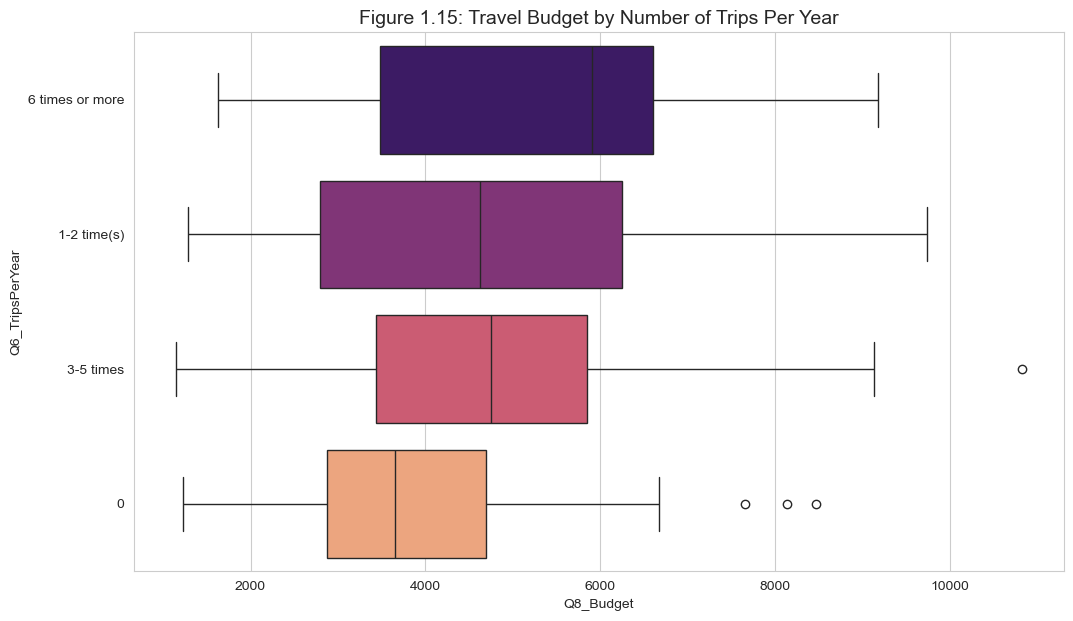

{'anova_result': F_onewayResult(statistic=2.7759141081981107, pvalue=0.04193207514657934),
 'anova_table':            Source            SS   df           MS       F p-value
 0  Between Groups   31777123.79    3  10592374.60  2.7759  0.0419
 1   Within Groups  938690481.45  246   3815814.97       -       -
 2           Total  970467605.24  249            -       -       -,
 'group_stats':              Group   N         Mean           SD   Min    Max
 0  6 times or more  13  5311.153846  2352.047153  1628   9178
 1      1-2 time(s)  97  4651.855670  2146.810629  1282   9736
 2        3-5 times  83  4822.481928  1854.985421  1148  10823
 3                0  57  3995.263158  1624.043417  1231   8477,
 'significance': 'Significant',
 'f_statistic': 2.7759141081981107,
 'p_value': 0.04193207514657934}

In [72]:
perform_anova_analysis(travel_df, 
                      categorical_col='Q6_TripsPerYear', 
                      numerical_col='Q8_Budget',
                      table_title="Table 1.7: ANOVA Results - Travel Budget by Number of Trips Per Year",
                      plot_title="Figure 1.15: Travel Budget by Number of Trips Per Year",
                      palette='magma')

#### T-Test

In [73]:
# Conduct T-tests between budget and all binary variables
binary_vars = ['Q2_Gender', 'Q14_Africa', 'Q14_EAsia', 'Q14_Europe',
                   'Q14_NAmerica', 'Q14_Oceania', 'Q14_SAmerica', 'Q14_SEAsia']

# Store results
t_results = []

print("Conducting T-tests between Q8_Budget and all binary variables...\n")

for bin_var in binary_vars:
    try:
        # Get unique groups and check if we have at least 2 groups
        groups = travel_df[bin_var].dropna().unique()

        if len(groups) >= 2:
            # Prepare data for T-tests
            grouped_data = [travel_df[travel_df[bin_var] == group]['Q8_Budget'].dropna() 
                          for group in groups]
            
            # Remove empty groups
            grouped_data = [group for group in grouped_data if len(group) > 0]
            
            if len(grouped_data) >= 2:
                # Perform T-tests
                t_test_result = stats.ttest_ind(*grouped_data, equal_var=False)

                # Store results
                t_results.append({
                    'Variable': bin_var,
                    'T_Statistic': t_test_result.statistic,
                    'P_Value': t_test_result.pvalue,
                    'Significant': 'Yes' if t_test_result.pvalue < 0.05 else 'No',
                    'Num_Groups': len(groups)
                })
            else:
                print(f"Skipped {bin_var}: Insufficient data after removing missing values")
        else:
            print(f"Skipped {bin_var}: Less than 2 groups available")

    except Exception as e:
        print(f"Error with {bin_var}: {str(e)}")

# Create results DataFrame and sort by p-value
results_df = pd.DataFrame(t_results)
results_df = results_df.sort_values('P_Value')

# Display results table
print("=" * 80)
print("Table 1.X: T-Test Results - Travel Budget by All Binary Variables")
print("=" * 80)
print(f"{'Variable':<25} {'T-Statistic':<12} {'P-Value':<10} {'Significant':<12} {'Groups':<8}")
print("-" * 80)

for _, row in results_df.iterrows():
    print(f"{row['Variable']:<25} {row['T_Statistic']:<12.4f} {row['P_Value']:<10.4f} "
          f"{row['Significant']:<12} {row['Num_Groups']:<8}")

print("=" * 80)

# Summary of significant results
significant_vars = results_df[results_df['Significant'] == 'Yes']
print(f"\nSummary: {len(significant_vars)} out of {len(results_df)} variables show significant differences")
if len(significant_vars) > 0:
    print("\nSignificant variables (α = 0.05):")
    for _, row in significant_vars.iterrows():
        print(f"  • {row['Variable']}: T = {row['T_Statistic']:.4f}, p = {row['P_Value']:.4f}")

# Create results DataFrame and sort by p-value
results_df = pd.DataFrame(t_results)
results_df = results_df.sort_values('P_Value')

# Display results table
print("=" * 80)
print("Table 1.X: T-Test Results - Travel Budget by All Binary Variables")
print("=" * 80)
print(f"{'Variable':<25} {'T-Statistic':<12} {'P-Value':<10} {'Significant':<12} {'Groups':<8}")
print("-" * 80)

for _, row in results_df.iterrows():
    print(f"{row['Variable']:<25} {row['T_Statistic']:<12.4f} {row['P_Value']:<10.4f} "
          f"{row['Significant']:<12} {row['Num_Groups']:<8}")

print("=" * 80)

# Summary of significant results
significant_vars = results_df[results_df['Significant'] == 'Yes']
print(f"\nSummary: {len(significant_vars)} out of {len(results_df)} variables show significant differences")
if len(significant_vars) > 0:
    print("\nSignificant variables (α = 0.05):")
    for _, row in significant_vars.iterrows():
        print(f"  • {row['Variable']}: T = {row['T_Statistic']:.4f}, p = {row['P_Value']:.4f}")

Conducting T-tests between Q8_Budget and all binary variables...

Table 1.X: T-Test Results - Travel Budget by All Binary Variables
Variable                  T-Statistic  P-Value    Significant  Groups  
--------------------------------------------------------------------------------
Q14_Africa                -1.6258      0.1237     No           2       
Q14_SEAsia                -1.3635      0.1740     No           2       
Q14_EAsia                 -0.8530      0.3960     No           2       
Q14_SAmerica              0.8400       0.4031     No           2       
Q14_Europe                -0.7094      0.4790     No           2       
Q14_NAmerica              0.6149       0.5397     No           2       
Q2_Gender                 -0.4914      0.6236     No           2       
Q14_Oceania               -0.3842      0.7015     No           2       

Summary: 0 out of 8 variables show significant differences
Table 1.X: T-Test Results - Travel Budget by All Binary Variables
Variable     

#### Categorical Association (Chi-Squared Test)

In [74]:
import itertools

# Chi-squared test of association for all pairs of categorical variables

# Use the categorical_cols defined earlier
chi2_results = []

print("Conducting Chi-squared tests of association for all pairs of categorical variables...\n")

# Get all unique pairs of categorical variables
categorical_pairs = list(itertools.combinations(categorical_cols, 2))

for var1, var2 in categorical_pairs:
    try:
        # Create contingency table
        contingency_table = pd.crosstab(travel_df[var1], travel_df[var2])
        
        # Check if contingency table has sufficient data (at least 2x2)
        if contingency_table.shape[0] >= 2 and contingency_table.shape[1] >= 2:
            # Perform Chi-squared test
            chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)
            
            # Check if expected frequencies are adequate (at least 5 in 80% of cells)
            adequate_expected = (expected >= 5).sum() / expected.size >= 0.8
            
            # Store results
            chi2_results.append({
                'Variable_1': var1,
                'Variable_2': var2,
                'Chi2_Statistic': chi2,
                'P_Value': p_value,
                'Degrees_of_Freedom': dof,
                'Significant': 'Yes' if p_value < 0.05 else 'No',
                'Adequate_Expected': 'Yes' if adequate_expected else 'No'
            })
        else:
            print(f"Skipped {var1} vs {var2}: Insufficient contingency table dimensions")
            
    except Exception as e:
        print(f"Error with {var1} vs {var2}: {str(e)}")

# Create results DataFrame and sort by p-value
chi2_results_df = pd.DataFrame(chi2_results)
chi2_results_df = chi2_results_df.sort_values('P_Value')

# Display results table
print("=" * 120)
print("Table 1.X: Chi-squared Test Results - Association Between All Categorical Variable Pairs")
print("=" * 120)
print(f"{'Variable 1':<25} {'Variable 2':<25} {'Chi2':<10} {'P-Value':<10} {'df':<5} {'Significant':<12} {'Valid Test':<10}")
print("-" * 120)

for _, row in chi2_results_df.iterrows():
    print(f"{row['Variable_1']:<25} {row['Variable_2']:<25} {row['Chi2_Statistic']:<10.4f} "
          f"{row['P_Value']:<10.4f} {row['Degrees_of_Freedom']:<5} {row['Significant']:<12} {row['Adequate_Expected']:<10}")

print("=" * 120)

# Summary of significant results
significant_associations = chi2_results_df[chi2_results_df['Significant'] == 'Yes']
print(f"\nSummary: {len(significant_associations)} out of {len(chi2_results_df)} variable pairs show significant associations")

if len(significant_associations) > 0:
    print(f"\nSignificant associations (α = 0.05):")
    for _, row in significant_associations.iterrows():
        print(f"  • {row['Variable_1']} × {row['Variable_2']}: χ² = {row['Chi2_Statistic']:.4f}, p = {row['P_Value']:.4f}")

# Display top 10 most significant associations
print(f"\nTop 10 Most Significant Associations:")
print("-" * 80)
top_10 = chi2_results_df.head(10)
for i, (_, row) in enumerate(top_10.iterrows(), 1):
    print(f"{i:2d}. {row['Variable_1']} × {row['Variable_2']}: p = {row['P_Value']:.4f}")

Conducting Chi-squared tests of association for all pairs of categorical variables...

Table 1.X: Chi-squared Test Results - Association Between All Categorical Variable Pairs
Variable 1                Variable 2                Chi2       P-Value    df    Significant  Valid Test
------------------------------------------------------------------------------------------------------------------------
Q6_TripsPerYear           Q15_Customization         158.8127   0.0000     12    Yes          No        
Q5_Income                 Q6_TripsPerYear           48.3775    0.0000     12    Yes          No        
Q4_Employment             Q5_Income                 43.2019    0.0019     20    Yes          No        
Q11_InfoSources           Q13_Accommodation         45.9813    0.0045     24    Yes          No        
Q5_Income                 Q15_Customization         34.0126    0.0054     16    Yes          No        
Q7_HolidayType            Q11_InfoSources           35.4951    0.0082     18   

Contingency Table:
Q15_Customization_Text  Extremely important  Important  Neutral  \
Q6_TripsPerYear                                                   
0                                         0          1       20   
1-2 time(s)                               0         14       49   
3-5 times                                 1         35       34   
6 times or more                           6          5        2   

Q15_Customization_Text  Not important at all  Slightly important  
Q6_TripsPerYear                                                   
0                                         12                  24  
1-2 time(s)                                7                  27  
3-5 times                                  1                  12  
6 times or more                            0                   0  

Chi2-statistic: 158.81, P-value: 0.0000
Result: There is a statistically significant association between trips per year and customization importance.


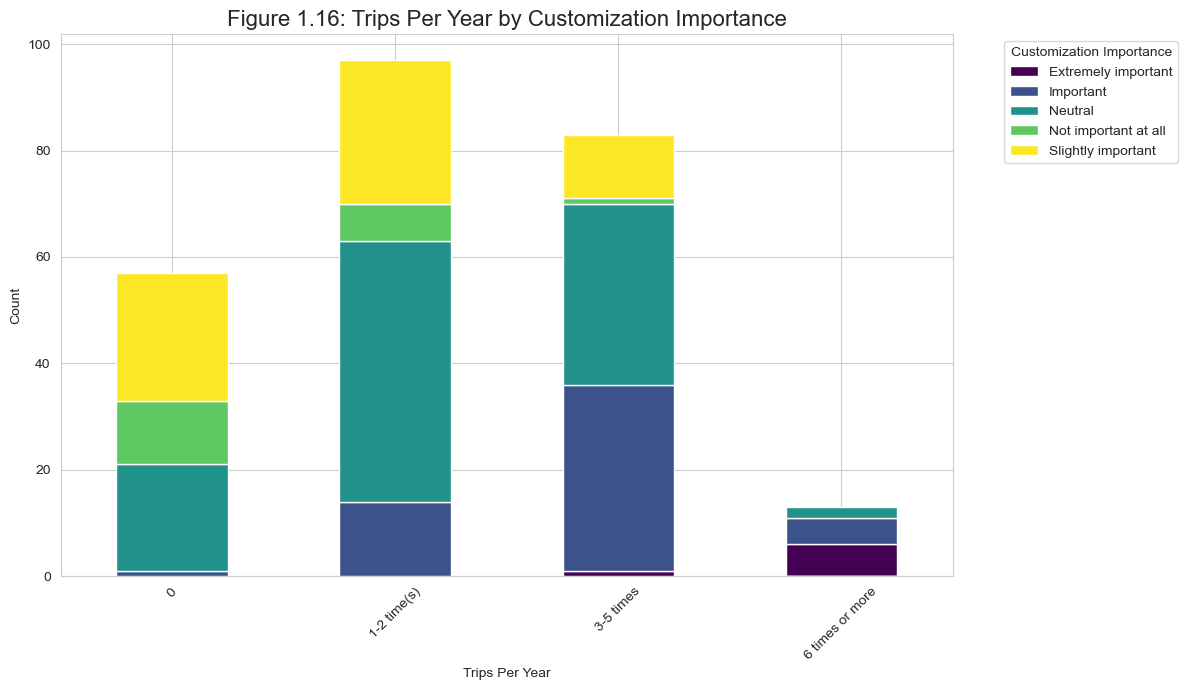

In [75]:
# 4.1: Map Q15_Customization back to text labels for better visualization
customization_reverse_mapping = {
    1: 'Not important at all',
    2: 'Slightly important',
    3: 'Neutral',
    4: 'Important',
    5: 'Extremely important'
}

# Create a copy of the data with mapped values for visualization
travel_plot_df = travel_df.copy()
travel_plot_df['Q15_Customization_Text'] = travel_plot_df['Q15_Customization'].map(customization_reverse_mapping)

# 4.1: Create a contingency table using the text labels
contingency_table = pd.crosstab(travel_plot_df['Q6_TripsPerYear'], travel_plot_df['Q15_Customization_Text'])
print("Contingency Table:")
print(contingency_table)

# 4.2: Perform the Chi-Squared test
chi2, p, dof, expected = stats.chi2_contingency(contingency_table)

print(f"\nChi2-statistic: {chi2:.2f}, P-value: {p:.4f}")
if p < 0.05:
    print("Result: There is a statistically significant association between trips per year and customization importance.")
else:
    print("Result: There is no statistically significant association between trips per year and customization importance.")

# 4.3: Visualize with a stacked bar chart
contingency_table.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='viridis')
plt.title('Figure 1.16: Trips Per Year by Customization Importance', fontsize=16)
plt.xlabel('Trips Per Year')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Customization Importance', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Contingency Table:
Q15_Customization   1   2   3   4  5
Q6_TripsPerYear                     
0                  12  24  20   1  0
1-2 time(s)         7  27  49  14  0
3-5 times           1  12  34  35  1
6 times or more     0   0   2   5  6

Chi2-statistic: 158.81, P-value: 0.0000
Result: There is a statistically significant association between holiday type and marital status.


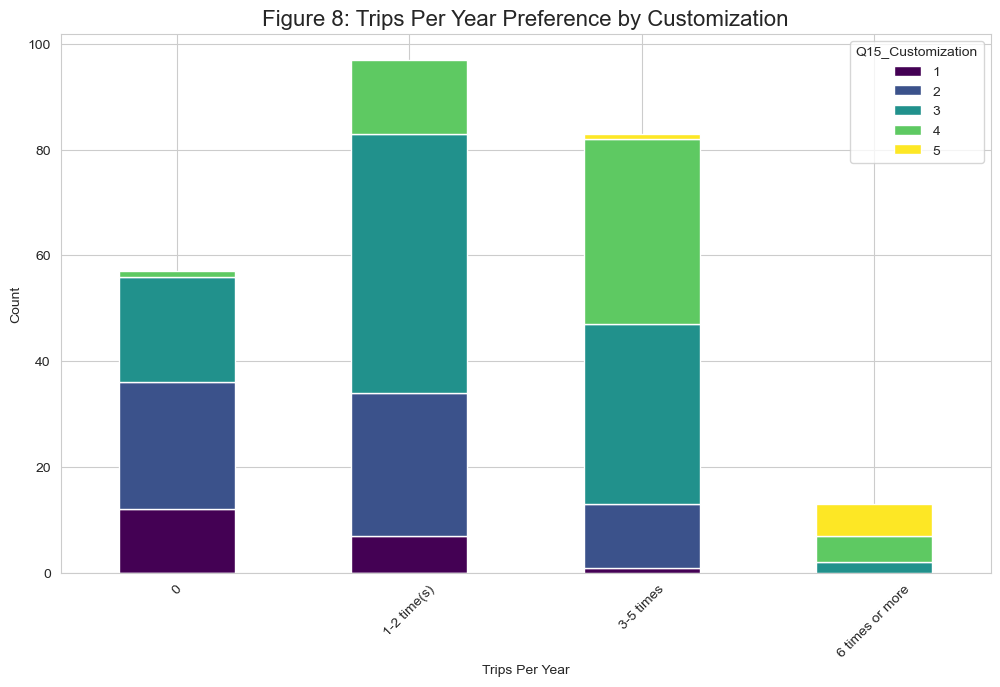

In [76]:
# 4.1: Create a contingency table
contingency_table = pd.crosstab(travel_df['Q6_TripsPerYear'], travel_df['Q15_Customization'])
print("Contingency Table:")
print(contingency_table)

# 4.2: Perform the Chi-Squared test
chi2, p, dof, expected = stats.chi2_contingency(contingency_table)

print(f"\nChi2-statistic: {chi2:.2f}, P-value: {p:.4f}")
if p < 0.05:
    print("Result: There is a statistically significant association between holiday type and marital status.")
else:
    print("Result: There is no statistically significant association between holiday type and marital status.")

# 4.3: Visualize with a stacked bar chart
contingency_table.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='viridis')
plt.title('Figure 8: Trips Per Year Preference by Customization', fontsize=16)
plt.xlabel('Trips Per Year')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

Contingency Table:
Q3_MaritalStatus  Divorced/ Separated  In a relationship/ Partnered  Married  \
Q7_HolidayType                                                                 
Adventure                          14                            15       12   
Cultural                           20                            37       35   
Relaxation                          6                            15       10   
Urban                               8                             7        9   

Q3_MaritalStatus  Single  Widowed  
Q7_HolidayType                     
Adventure             14        3  
Cultural              13       10  
Relaxation             4        6  
Urban                  8        4  

Chi2-statistic: 14.02, P-value: 0.2995
Result: There is no statistically significant association between holiday type and marital status.


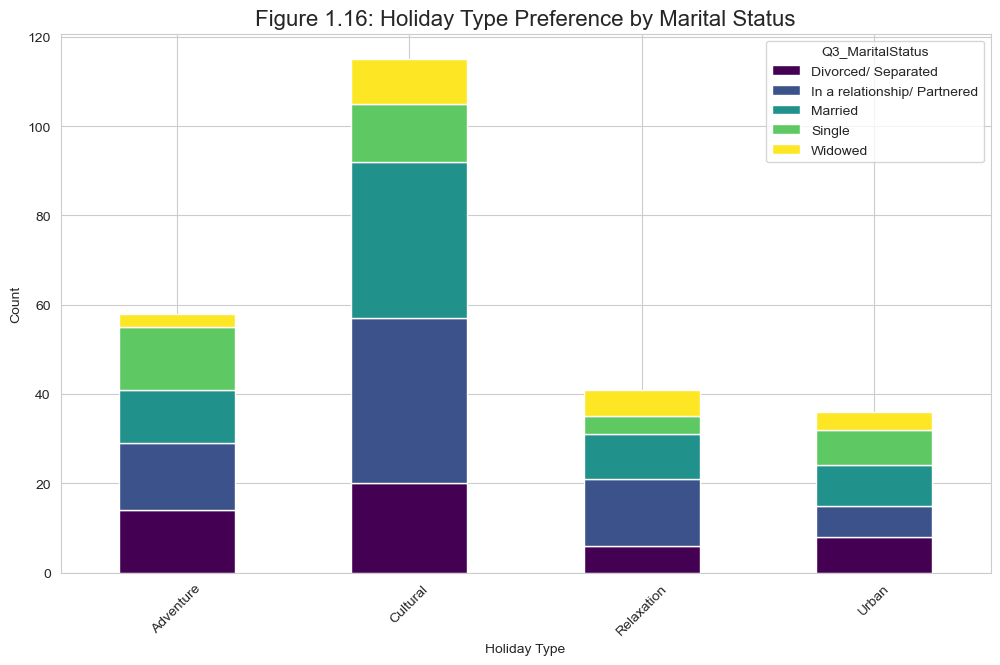

In [77]:
# 4.1: Create a contingency table
contingency_table = pd.crosstab(travel_df['Q7_HolidayType'], travel_df['Q3_MaritalStatus'])
print("Contingency Table:")
print(contingency_table)

# 4.2: Perform the Chi-Squared test
chi2, p, dof, expected = stats.chi2_contingency(contingency_table)

print(f"\nChi2-statistic: {chi2:.2f}, P-value: {p:.4f}")
if p < 0.05:
    print("Result: There is a statistically significant association between holiday type and marital status.")
else:
    print("Result: There is no statistically significant association between holiday type and marital status.")

# 4.3: Visualize with a stacked bar chart
contingency_table.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='viridis')
plt.title('Figure 1.16: Holiday Type Preference by Marital Status', fontsize=16)
plt.xlabel('Holiday Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

Contingency Table:
Q3_MaritalStatus  Divorced/ Separated  In a relationship/ Partnered  Married  \
Q7_HolidayType                                                                 
Adventure                          14                            15       12   
Cultural                           20                            37       35   
Relaxation                          6                            15       10   
Urban                               8                             7        9   

Q3_MaritalStatus  Single  Widowed  
Q7_HolidayType                     
Adventure             14        3  
Cultural              13       10  
Relaxation             4        6  
Urban                  8        4  

--- Table 1.8: Chi-squared Test Results - Holiday Type by Marital Status ---
       Test Statistic   Value
Chi-squared statistic 14.0188
              P-value  0.2995
   Degrees of freedom      12
          Sample size     250

Statistical Interpretation:
α = 0.05, p-value = 0.2995


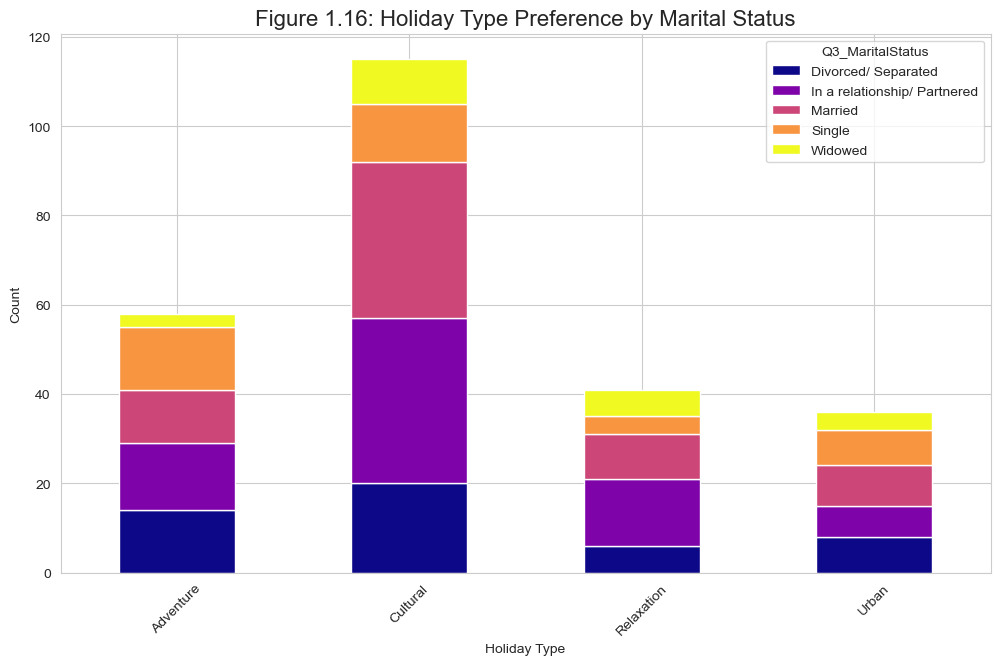

In [78]:
# 4.1: Create a contingency table
contingency_table = pd.crosstab(travel_df['Q7_HolidayType'], travel_df['Q3_MaritalStatus'])
print("Contingency Table:")
print(contingency_table)

# 4.2: Perform the Chi-Squared test
chi2, p, dof, expected = stats.chi2_contingency(contingency_table)

# Create a properly formatted results table
chi2_results_table = pd.DataFrame({
    'Test Statistic': ['Chi-squared statistic', 'P-value', 'Degrees of freedom', 'Sample size'],
    'Value': [f"{chi2:.4f}", f"{p:.4f}", f"{dof}", f"{len(travel_df)}"]
})

print(f"\n--- Table 1.8: Chi-squared Test Results - Holiday Type by Marital Status ---")
print("=" * 70)
print(chi2_results_table.to_string(index=False))
print("=" * 70)

# Statistical interpretation
alpha = 0.05
print(f"\nStatistical Interpretation:")
print(f"α = {alpha}, p-value = {p:.4f}")

if p < alpha:
    significance = "Significant"
    conclusion = "Reject null hypothesis"
    interpretation = "There is a statistically significant association between holiday type and marital status."
else:
    significance = "Not Significant"
    conclusion = "Fail to reject null hypothesis"
    interpretation = "There is no statistically significant association between holiday type and marital status."

print(f"Result: {significance} ({conclusion})")
print(f"Interpretation: {interpretation}")

# 4.3: Visualize with a stacked bar chart
contingency_table.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='plasma')
plt.title('Figure 1.16: Holiday Type Preference by Marital Status', fontsize=16)
plt.xlabel('Holiday Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

## Phase 2.1: Advanced Analysis (Unsupervised ML)

Available columns in travel_df:
['Q1_Age', 'Q2_Gender', 'Q3_MaritalStatus', 'Q4_Employment', 'Q5_Income', 'Q6_TripsPerYear', 'Q7_HolidayType', 'Q8_Budget', 'Q9_Priorities', 'Q10_BookingAdvance', 'Q11_InfoSources', 'Q12_BookingPreference', 'Q13_Accommodation', 'Q14_Africa', 'Q14_EAsia', 'Q14_Europe', 'Q14_NAmerica', 'Q14_Oceania', 'Q14_SAmerica', 'Q14_SEAsia', 'Q15_Customization', 'Q16_AdventureInterest', 'Q17_CustomServices', 'Q18_TechTrends', 'Q19_FuturePriorities', 'Q6_TripsPerYear_Num', 'Q10_BookingAdvance_Num']
Clustering dataset shape: (250, 11)
Features for clustering: ['Q6_TripsPerYear', 'Q8_Budget', 'Q9_Priorities', 'Q10_BookingAdvance', 'Q12_BookingPreference', 'Q13_Accommodation', 'Q15_Customization', 'Q16_AdventureInterest', 'Q17_CustomServices', 'Q18_TechTrends', 'Q19_FuturePriorities']


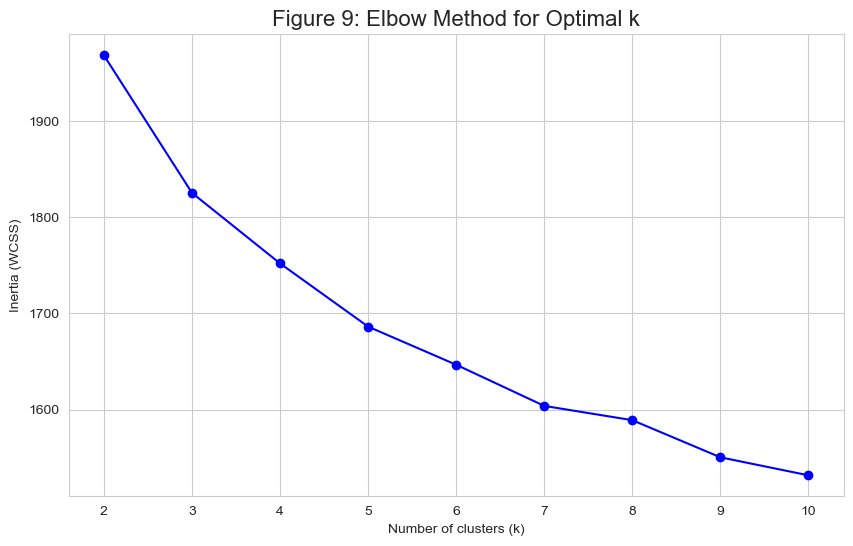

In [79]:
# --- TRAVEL ANALYSIS PLAN: PHASE 2.1 ---
#
# Goal: Use K-Means Clustering to identify distinct market segments
# based on traveler behaviors and preferences.

# --- Step 0: Import necessary libraries ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Let's assume 'travel_df' is loaded and cleaned from Phase 1.1
# If not, uncomment and run the cleaning lines from the previous step.
# travel_df = pd.read_csv('stratified_travel_250_withText.csv')
# ... (cleaning code) ...
# --- Step 1: Feature Selection for Clustering ---

# First, let's check what columns are available in the dataframe
print("Available columns in travel_df:")
print(travel_df.columns.tolist())

# We will cluster based on BEHAVIORS and PREFERENCES, not demographics.
# This gives us more actionable segments.
# Note: Q15_Customization and Q16_AdventureInterest are already numeric in the dataset
cluster_features = [
    'Q6_TripsPerYear',        # Travel frequency behavior
    'Q8_Budget',              # Spending behavior
    'Q9_Priorities',          # Travel priorities/preferences
    'Q10_BookingAdvance',     # Planning behavior
    'Q12_BookingPreference',  # Booking behavior preference
    'Q13_Accommodation',      # Accommodation preference
    'Q15_Customization',      # Already numeric (1-5 scale) - customization preference
    'Q16_AdventureInterest',  # Already numeric (1-5 scale) - adventure preference
    'Q17_CustomServices',     # Service preferences
    'Q18_TechTrends',         # Technology adoption behavior
    'Q19_FuturePriorities'    # Future travel priorities
]

# Create a new DataFrame for clustering, dropping any rows with missing values
cluster_df = travel_df[cluster_features].dropna()

print(f"Clustering dataset shape: {cluster_df.shape}")
print(f"Features for clustering: {cluster_features}")

# --- Step 2: Create a Preprocessing Pipeline ---

# We need to scale numeric features and one-hot encode categorical features.

numeric_features_cluster = ['Q8_Budget', 'Q15_Customization', 'Q16_AdventureInterest']
categorical_features_cluster = ['Q6_TripsPerYear', 'Q9_Priorities', 'Q10_BookingAdvance', 'Q12_BookingPreference',
                               'Q13_Accommodation', 'Q17_CustomServices', 'Q18_TechTrends', 'Q19_FuturePriorities']

# Create the preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features_cluster),
        ('cat', OneHotEncoder(), categorical_features_cluster)
    ],
    remainder='passthrough'
)

# --- Step 3: Find the Optimal Number of Clusters (Elbow Method) ---

# We'll create a pipeline that preprocesses, then clusters
pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                           ('clusterer', KMeans(n_init=10, random_state=42))])

# Calculate inertia (WCSS) for a range of k values
inertia = []
K_range = range(2, 11) # Test from 2 to 10 clusters

for k in K_range:
    pipeline.set_params(clusterer__n_clusters=k)
    pipeline.fit(cluster_df)
    inertia.append(pipeline.named_steps['clusterer'].inertia_)

# Plot the Elbow Method
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertia, 'bo-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia (WCSS)')
plt.title('Figure 9: Elbow Method for Optimal k', fontsize=16)
plt.savefig('travel_fig9_elbow_method.png')
plt.show()

In [80]:
# --- Step 4: Run the Final K-Means Model ---

# Based on the elbow plot, choose the optimal k.
# (Let's assume the elbow is at k=4 for this example)
OPTIMAL_K = 5

pipeline.set_params(clusterer__n_clusters=OPTIMAL_K)
pipeline.fit(cluster_df)

# Get the cluster labels for each respondent
cluster_labels = pipeline.named_steps['clusterer'].labels_

# Add the cluster labels back to our original (cleaned) DataFrame
# We use .loc to ensure we only label the rows we clustered
travel_df.loc[cluster_df.index, 'Cluster'] = cluster_labels

print(f"\n--- Data successfully clustered into {OPTIMAL_K} segments. ---")


# --- Step 5: Profile the Clusters (The most important part) ---

print("\n--- Cluster Profiles ---")

# Profile 1: Average values for numerical features
numeric_profile = travel_df.groupby('Cluster')[numeric_features_cluster].mean()
print(numeric_profile)
print("\n")

# Profile 2: Mode (most common) for categorical features
for col in categorical_features_cluster:
    print(f"--- {col} by Cluster ---")
    categorical_profile = travel_df.groupby('Cluster')[col].agg(pd.Series.mode)
    print(categorical_profile)
    print("\n")

# Example: Combine with demographics to see who they are
print("--- Cluster Demographics (Age) ---")
print(travel_df.groupby('Cluster')['Q1_Age'].mean())


--- Data successfully clustered into 5 segments. ---

--- Cluster Profiles ---
           Q8_Budget  Q15_Customization  Q16_AdventureInterest
Cluster                                                       
0.0      3510.386364           4.000000               3.977273
1.0      4975.837209           3.441860               1.930233
2.0      3928.155172           2.689655               4.068966
3.0      3625.883333           1.833333               2.133333
4.0      7432.600000           2.800000               2.666667


--- Q6_TripsPerYear by Cluster ---
Cluster
0.0      3-5 times
1.0      3-5 times
2.0    1-2 time(s)
3.0              0
4.0    1-2 time(s)
Name: Q6_TripsPerYear, dtype: object


--- Q9_Priorities by Cluster ---
Cluster
0.0                               Price
1.0                              Safety
2.0    [Activities/ Attractions, Price]
3.0                               Price
4.0                               Price
Name: Q9_Priorities, dtype: object


--- Q10_BookingAdvance

## Phase 2.2: Supervised ML (Predicting Holiday Type)

In [84]:
# New Target Definition (based on the Q7_HolidayType column)
# Make sure this code replaces your old target definition logic

if 'Q7_HolidayType' in travel_df.columns:
    travel_df['Target_AdventurePreference'] = travel_df['Q7_HolidayType'].apply(lambda x: 1 if x == 'Adventure' else 0)

    # Check the new target balance (it will be imbalanced)
    print("New Target Balance (based on Q7_HolidayType):")
    print(travel_df['Target_AdventurePreference'].value_counts())
else:
    print("Error: 'Q7_HolidayType' column not found.")

New Target Balance (based on Q7_HolidayType):
Target_AdventurePreference
0    192
1     58
Name: count, dtype: int64


In [85]:

# 1a. Define the target variable 'y'
# We will predict the 'Q7_HolidayType'
y = travel_df['Target_AdventurePreference'].dropna() # Drop rows where holiday type is missing

# 1b. Define the features 'X'
# We select features that would logically predict holiday type.
# We align X with y by dropping the same rows.
features = [
    'Q1_Age',
    'Q8_Budget',
    'Q2_Gender',
    'Q3_MaritalStatus',
    'Q4_Employment',
    'Q5_Income',
    'Q15_Customization', # Our numeric Likert scale (1-5)
    'Q16_AdventureInterest' # Our numeric Likert scale (1-5)
]
X = travel_df.loc[y.index, features].dropna() # Drop rows where any feature is missing

# Align y again after dropping rows from X
y = y.loc[X.index]

print(f"--- Building models with {X.shape[0]} valid responses ---")


# --- Step 2: Preprocessing Pipeline ---

# Define our numeric and categorical features
numeric_features = ['Q1_Age', 'Q8_Budget', 'Q15_Customization', 'Q16_AdventureInterest']
categorical_features = ['Q2_Gender', 'Q3_MaritalStatus', 'Q4_Employment', 'Q5_Income']

# Create the preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

--- Building models with 250 valid responses ---



--- Running 10-Fold Cross-Validation with Training/Testing Scores ---
Logistic Regression:
  Training Accuracy = 0.668 (±0.023)
  Testing Accuracy  = 0.564 (±0.095)
  Overfitting Gap   = 0.104

Decision Tree:
  Training Accuracy = 1.000 (±0.000)
  Testing Accuracy  = 0.636 (±0.117)
  Overfitting Gap   = 0.364

Random Forest:
  Training Accuracy = 0.795 (±0.015)
  Testing Accuracy  = 0.684 (±0.058)
  Overfitting Gap   = 0.111

Naive Bayes:
  Training Accuracy = 0.286 (±0.025)
  Testing Accuracy  = 0.268 (±0.044)
  Overfitting Gap   = 0.018

------------------ Table 1.9: Model Comparison (Ranked by Test Accuracy) ------------------
              Model  Mean Train Accuracy  Train Std  Mean Test Accuracy  Test Std  Overfitting Gap
      Random Forest                0.795      0.015               0.684     0.058            0.111
      Decision Tree                1.000      0.000               0.636     0.117            0.364
Logistic Regression                0.668      0.023             

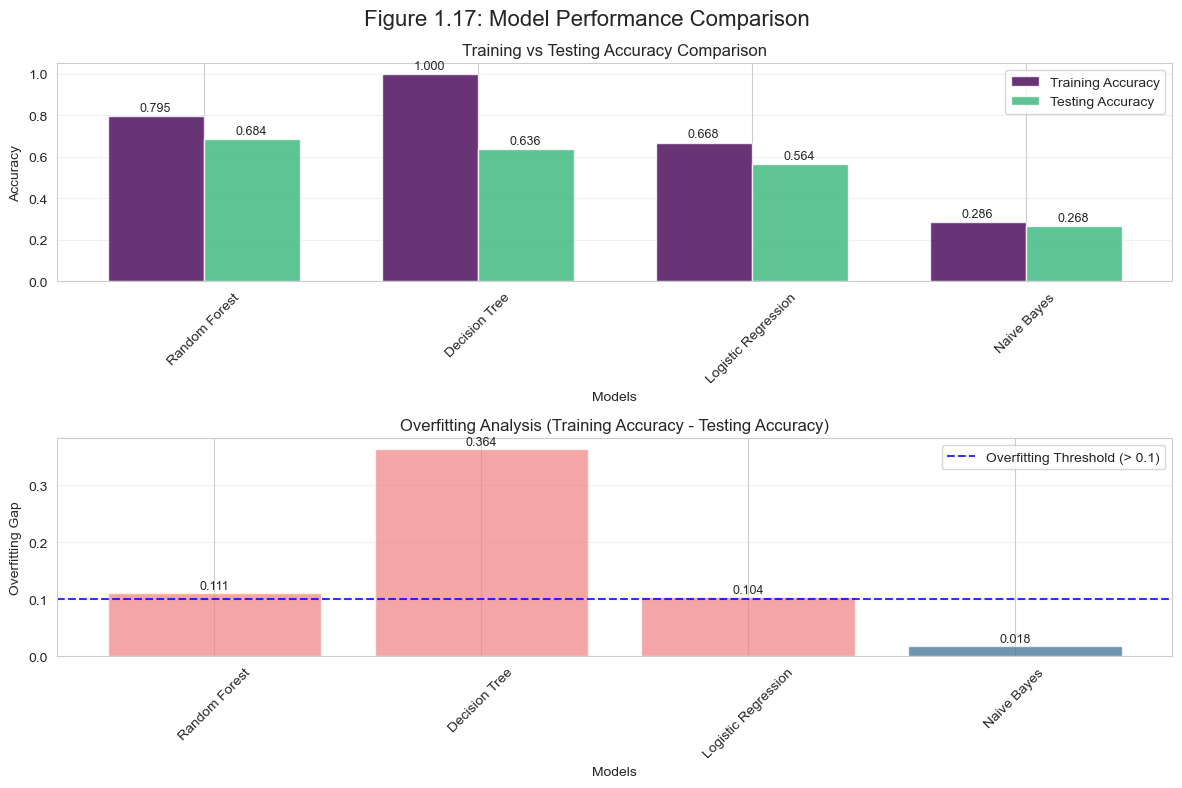

In [86]:
from sklearn.model_selection import StratifiedKFold

# Create Full Pipelines for Each Model

# 1. Logistic Regression with balanced class weights
pipe_lr = Pipeline(steps=[('preprocessor', preprocessor),
                          ('classifier', LogisticRegression(multi_class='multinomial', solver='lbfgs', 
                                                           max_iter=1000, random_state=42, class_weight='balanced'))])

# 2. Decision Tree with balanced class weights
pipe_dt = Pipeline(steps=[('preprocessor', preprocessor),
                          ('classifier', DecisionTreeClassifier(random_state=42, class_weight='balanced'))])

# 3. Random Forest with balanced class weights
pipe_rf = Pipeline(steps=[('preprocessor', preprocessor),
                          ('classifier', RandomForestClassifier(max_depth=3, min_samples_leaf=5,
                                                               random_state=42, class_weight='balanced'))])

# 4. Naive Bayes (requires a special step to make the sparse matrix dense)
def make_dense(X):
    if hasattr(X, 'toarray'):
        return X.toarray()
    return X

pipe_nb = Pipeline(steps=[('preprocessor', preprocessor),
                          ('to_dense', FunctionTransformer(make_dense)),
                          ('classifier', GaussianNB())])

# Run Cross-Validation for Each Model with both training and testing scores
models = {
    "Logistic Regression": pipe_lr,
    "Decision Tree": pipe_dt,
    "Random Forest": pipe_rf,
    "Naive Bayes": pipe_nb
}

results = []

print("\n--- Running 10-Fold Cross-Validation with Training/Testing Scores ---")

for name, model in models.items():
    # Set up the 10-fold stratified cross-validation to maintain class distribution
    skfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    
    # Get training and testing scores for each fold
    train_scores = []
    test_scores = []
    
    for train_idx, test_idx in skfold.split(X, y):
        X_train_fold, X_test_fold = X.iloc[train_idx], X.iloc[test_idx]
        y_train_fold, y_test_fold = y.iloc[train_idx], y.iloc[test_idx]
        
        # Fit the model on training data
        model.fit(X_train_fold, y_train_fold)
        
        # Score on training and testing data
        train_score = model.score(X_train_fold, y_train_fold)
        test_score = model.score(X_test_fold, y_test_fold)
        
        train_scores.append(train_score)
        test_scores.append(test_score)
    
    # Convert to numpy arrays for easier calculation
    train_scores = np.array(train_scores)
    test_scores = np.array(test_scores)
    
    # Calculate overfitting (difference between training and testing accuracy)
    overfitting = train_scores.mean() - test_scores.mean()
    
    # Store the results
    results.append((name, train_scores.mean(), train_scores.std(), 
                   test_scores.mean(), test_scores.std(), overfitting))
    
    print(f"{name}:")
    print(f"  Training Accuracy = {train_scores.mean():.3f} (±{train_scores.std():.3f})")
    print(f"  Testing Accuracy  = {test_scores.mean():.3f} (±{test_scores.std():.3f})")
    print(f"  Overfitting Gap   = {overfitting:.3f}")
    print()

# Create comprehensive results dataframe
results_df = pd.DataFrame(results, columns=['Model', 'Mean Train Accuracy', 'Train Std', 
                                          'Mean Test Accuracy', 'Test Std', 'Overfitting Gap'])
results_df = results_df.sort_values(by='Mean Test Accuracy', ascending=False)

print("------------------ Table 1.9: Model Comparison (Ranked by Test Accuracy) ------------------")
print(results_df.round(3).to_string(index=False))

# Create visualization comparing training vs testing accuracy
plt.figure(figsize=(12, 8))

# Add overall title for the entire figure
plt.suptitle('Figure 1.17: Model Performance Comparison', fontsize=16, y=0.98)

# Get viridis colors
viridis_colors = plt.cm.viridis(np.linspace(0, 1, 4))

# Prepare data for plotting
models_list = results_df['Model'].tolist()
train_acc = results_df['Mean Train Accuracy'].tolist()
test_acc = results_df['Mean Test Accuracy'].tolist()

x = np.arange(len(models_list))
width = 0.35

overfitting_threshold = 0.1

# Create bar plot
plt.subplot(2, 1, 1)
bars1 = plt.bar(x - width/2, train_acc, width, label='Training Accuracy', alpha=0.8, color=viridis_colors[0])
bars2 = plt.bar(x + width/2, test_acc, width, label='Testing Accuracy', alpha=0.8, color=viridis_colors[2])

plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.title('Training vs Testing Accuracy Comparison')
plt.xticks(x, models_list, rotation=45)
plt.legend()
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.3f}', ha='center', va='bottom', fontsize=9)

for bar in bars2:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.3f}', ha='center', va='bottom', fontsize=9)

# Create overfitting gap visualization
plt.subplot(2, 1, 2)
overfitting_gaps = results_df['Overfitting Gap'].tolist()
colors = ['lightcoral' if gap > overfitting_threshold else viridis_colors[1] for gap in overfitting_gaps]

bars3 = plt.bar(models_list, overfitting_gaps, color=colors, alpha=0.7)
plt.xlabel('Models')
plt.ylabel('Overfitting Gap')
plt.title('Overfitting Analysis (Training Accuracy - Testing Accuracy)')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.axhline(y=overfitting_threshold, color='blue', linestyle='--', alpha=0.8, label=f'Overfitting Threshold (> {overfitting_threshold})')
plt.legend()

# Add value labels on bars
for bar in bars3:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.002,
             f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

Training final model using best performer: Random Forest
--- Final model (Random Forest) trained on all travel data. ---

--- Table: Top 10 Most Important Features for Adventure Travel Prediction (Random Forest) ---
                                          Feature  Importance
0                                          Q1_Age    0.228796
1                                       Q8_Budget    0.200118
2                               Q15_Customization    0.070813
3                           Q16_AdventureInterest    0.067835
9                         Q3_MaritalStatus_Single    0.046546
16                       Q4_Employment_Unemployed    0.039940
13                          Q4_Employment_Retired    0.034459
8                        Q3_MaritalStatus_Married    0.033185
10                       Q3_MaritalStatus_Widowed    0.031065
7   Q3_MaritalStatus_In a relationship/ Partnered    0.028086


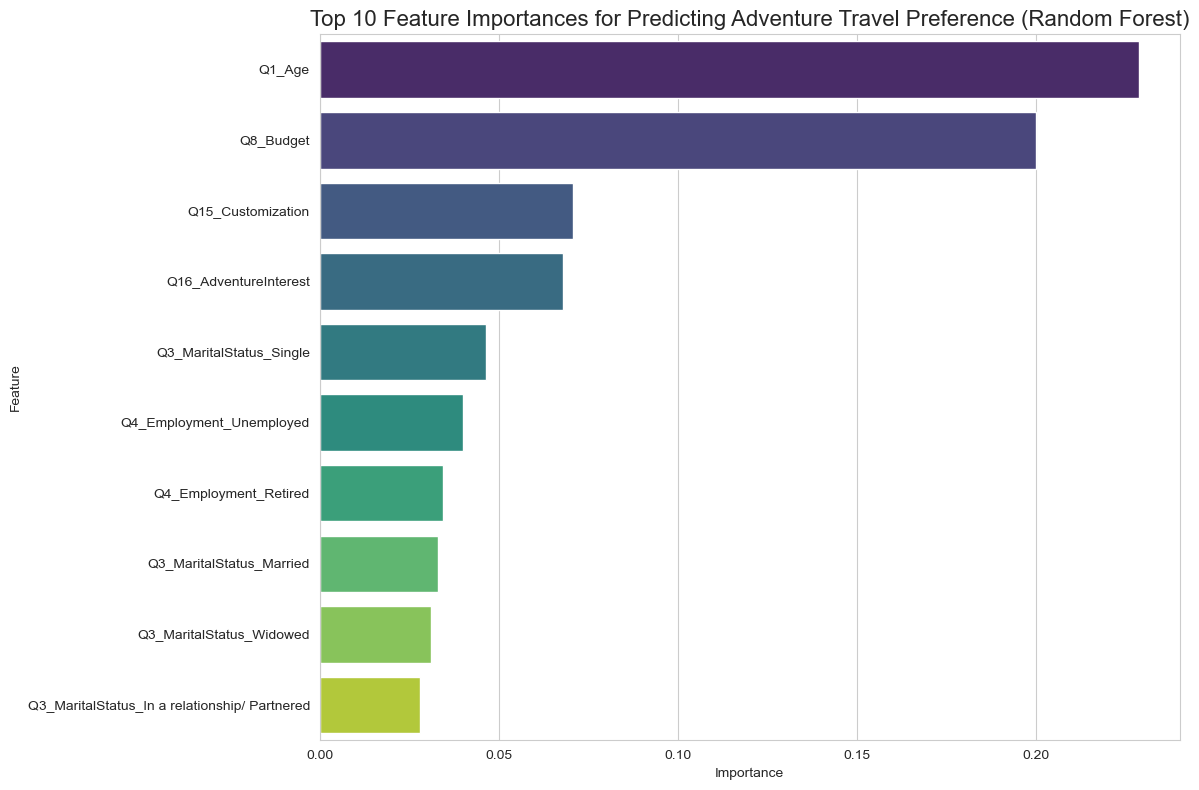

In [87]:
# --- TRAVEL ANALYSIS PLAN: PHASE 2.2 (FINAL STEP) ---
#
# Goal: Train the best-performing model on the full dataset and
# extract its feature importances to understand WHAT factors are
# the most predictive.

# Use the best performing model from previous cross-validation results
best_model_name = results_df.iloc[0]['Model']
print(f"Training final model using best performer: {best_model_name}")

# Get the best model pipeline from our previous models dictionary
best_model = models[best_model_name]

# Use the same X and y from the previous cross-validation
# Fit the best model on 100% of the data
best_model.fit(X, y)

print(f"--- Final model ({best_model_name}) trained on all travel data. ---")

# --- Extract and Visualize Feature Importances ---
# Check if the model has feature_importances_ attribute (tree-based models)
if hasattr(best_model.named_steps['classifier'], 'feature_importances_'):
    importances = best_model.named_steps['classifier'].feature_importances_
    
    # Get the names of the features after preprocessing
    ohe_feature_names = best_model.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_features)
    all_feature_names = np.concatenate([numeric_features, ohe_feature_names])
    
    # Create a DataFrame for easy plotting
    importance_df = pd.DataFrame({
        'Feature': all_feature_names,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False)
    
    print(f"\n--- Table: Top 10 Most Important Features for Adventure Travel Prediction ({best_model_name}) ---")
    print(importance_df.head(10))
    
    # Plot the feature importances
    plt.figure(figsize=(12, 8))
    sns.barplot(x='Importance', y='Feature', data=importance_df.head(10), palette='viridis')
    plt.title(f'Top 10 Feature Importances for Predicting Adventure Travel Preference ({best_model_name})', fontsize=16)
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()
    
else:
    print(f"Note: {best_model_name} does not have feature importance attributes.")
    print("Feature importance is only available for tree-based models (Decision Tree, Random Forest).")


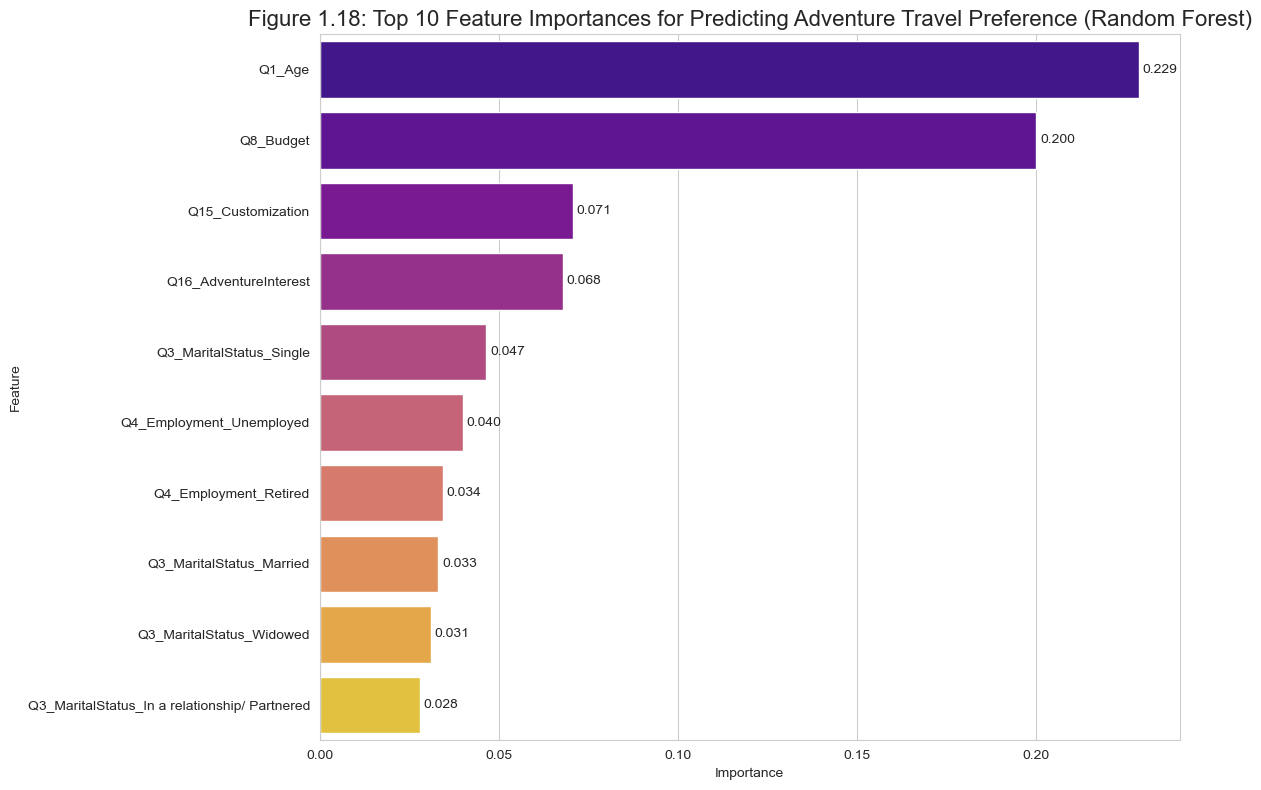

In [88]:
# Plot the feature importances with values displayed
plt.figure(figsize=(12, 8))
ax = sns.barplot(x='Importance', y='Feature', data=importance_df.head(10), palette='plasma')

# Add importance values as text on the bars
for i, v in enumerate(importance_df.head(10)['Importance']):
    ax.text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=10)

plt.title(f'Figure 1.18: Top 10 Feature Importances for Predicting Adventure Travel Preference ({best_model_name})', fontsize=16)
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()